In [24]:
import pandas as pd
from pathlib import Path
import numpy as np
import json
from sklearn.preprocessing import OneHotEncoder,PowerTransformer
ROOT = Path.cwd().parent
motor='DATA_MODEL_Dev/Motor_data_models.csv'
subject='DATA_MODEL_Dev/Subject_data_models.csv'
cognitive='DATA_MODEL_Dev/Cognitive_data_models.csv'
sleep='DATA_MODEL_Dev/Sleep_data_models.csv'
data_split='DATA_RAW_MODELS/Data_split.json'

# DATA SPLIT

In [25]:
with open(ROOT/data_split, "r", encoding="utf-8") as archivo:
    data_subjects = json.load(archivo)

subjects_train=data_subjects['Train_80']
subjects_test=data_subjects['Test_20']

## Normal Data

### X_train and y_train

In [ ]:
X_train_subject=pd.read_csv(ROOT/subject)
X_train_subject=X_train_subject[X_train_subject['subject_visit'].isin(subjects_train)]
X_train_subject.drop(columns=['MDS-UPDRS Part II Total Score','MDS-UPDRS Part IV Total Score',
                                'MDS-UPDRS Part III Total Score','MDS-UPDRS Part I (Patient Questionnaire) Total Score',
                                'MDS-UPDRS Total Score'],inplace=True)


,RBD at Enrollment,Parkin Mutation at Enrollment,LRRK2 Mutation at Enrollment,SNCA Mutation at Enrollment,GBA Mutation at Enrollment,Birth Date,Sex of participant at birth,Identify self as White,Education_Years,AGE_AT_VISIT,BMI,Ortostatic_Hypotension,UPDRS_III_ProgressionType,subject_visit
1,0,0,0,0,0,1953,1,1,19.0,68.4,22.985398,0,-1,100007_V04_V06
2,0,0,0,0,0,1955,0,1,18.0,67.0,31.130098,0,0,100012_V04_V06
4,0,0,0,0,0,1959,1,1,16.0,63.2,26.481633,0,-1,101018_V04_V06
5,0,0,0,0,0,1947,0,0,20.0,74.9,22.038567,0,-1,101025_V04_V06
8,0,0,0,0,0,1966,1,1,13.0,56.2,25.381469,0,-1,101174_V04_V06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904,0,0,1,0,0,1970,1,1,19.0,52.7,25.535446,0,-1,73935_V10_V12
906,0,0,0,0,1,1962,1,1,17.0,60.6,31.656357,0,-1,75480_V10_V12
907,0,0,1,0,0,1961,1,1,24.0,61.6,21.028571,1,0,75484_V10_V12
908,0,0,1,0,0,1955,1,1,21.0,68.3,27.304688,0,-1,75505_V10_V12


In [3]:
X_train_motor=pd.read_csv(ROOT/motor)
X_train_motor=X_train_motor[X_train_motor['subject_visit'].isin(subjects_train)]

X_train_cognitive=pd.read_csv(ROOT/cognitive)
X_train_cognitive=X_train_cognitive[X_train_cognitive['subject_visit'].isin(subjects_train)]
X_train_cognitive.drop(columns=['UPDRS_III_ProgressionType','MDS-UPDRS Total Score','MDS-UPDRS Part II Total Score',
                                'MDS-UPDRS Part I (Patient Questionnaire) Total Score','VISUOSPATIAL_EXECUTIVE','NAMING','ATTENTION',
                                'LANGUAGE','ABSTRACTION','DELAYED_RECALL','ORIENTATION'], inplace=True)

X_train_sleep=pd.read_csv(ROOT/sleep)
X_train_sleep=X_train_sleep[X_train_sleep['subject_visit'].isin(subjects_train)]
X_train_sleep.drop(columns=['UPDRS_III_ProgressionType','MDS-UPDRS Part II Total Score','MDS-UPDRS Part IV Total Score',
                            'MDS-UPDRS Part III Total Score','MDS-UPDRS Part I (Patient Questionnaire) Total Score',
                            'Sitting and reading','Watching TV','Sitting, inactive in a public place','As a passenger in a car for an hour',
                            'Lying down to rest in the afternoon','Sitting and talking to someone','Sitting quietly after lunch',
                            'In a car, while stopped in traffic','Vivid Dreams','Aggressive or Action-packed dreams','nocturnal behaviour',
                            'move arms/legs during sleep','hurt bed partner','speaking in sleep','sudden limb movements','complex movements',
                            'things fell down','my movements awake me','remember dreams','sleep is disturbed','Stroke','Head trauma',
                            'Parkinsonism','Restless Leg Syndrome (RLS)', 'Narcolepsy','Depression','Epilepsy','Inflammatory disease of the brain'], inplace=True)

X_train=pd.merge(X_train_motor, X_train_cognitive, on='subject_visit', how='inner')
X_train=pd.merge(X_train, X_train_sleep, on='subject_visit', how='inner')
X_train.drop(columns=['subject_visit'], inplace=True)

y_train=X_train_motor['UPDRS_III_ProgressionType'].map({0:2,1:1,-1:3})
X_train.drop(columns=['UPDRS_III_ProgressionType'], inplace=True)

print(X_train.shape,y_train.shape)


(728, 39) (728,)


### X_test and y_test

In [4]:
X_test_motor=pd.read_csv(ROOT/motor)
X_test_motor=X_test_motor[X_test_motor['subject_visit'].isin(subjects_test)]

X_test_cognitive=pd.read_csv(ROOT/cognitive)
X_test_cognitive=X_test_cognitive[X_test_cognitive['subject_visit'].isin(subjects_test)]
X_test_cognitive.drop(columns=['UPDRS_III_ProgressionType','MDS-UPDRS Total Score','MDS-UPDRS Part II Total Score',
                                'MDS-UPDRS Part I (Patient Questionnaire) Total Score','VISUOSPATIAL_EXECUTIVE','NAMING','ATTENTION',
                                'LANGUAGE','ABSTRACTION','DELAYED_RECALL','ORIENTATION'], inplace=True)

X_test_sleep=pd.read_csv(ROOT/sleep)
X_test_sleep=X_test_sleep[X_test_sleep['subject_visit'].isin(subjects_test)]
X_test_sleep.drop(columns=['UPDRS_III_ProgressionType','MDS-UPDRS Part II Total Score','MDS-UPDRS Part IV Total Score',
                            'MDS-UPDRS Part III Total Score','MDS-UPDRS Part I (Patient Questionnaire) Total Score',
                            'Sitting and reading','Watching TV','Sitting, inactive in a public place','As a passenger in a car for an hour',
                            'Lying down to rest in the afternoon','Sitting and talking to someone','Sitting quietly after lunch',
                            'In a car, while stopped in traffic','Vivid Dreams','Aggressive or Action-packed dreams','nocturnal behaviour',
                            'move arms/legs during sleep','hurt bed partner','speaking in sleep','sudden limb movements','complex movements',
                            'things fell down','my movements awake me','remember dreams','sleep is disturbed','Stroke','Head trauma',
                            'Parkinsonism','Restless Leg Syndrome (RLS)', 'Narcolepsy','Depression','Epilepsy','Inflammatory disease of the brain'], inplace=True)

X_test=pd.merge(X_test_motor, X_test_cognitive, on='subject_visit', how='inner')
X_test=pd.merge(X_test, X_test_sleep, on='subject_visit', how='inner')
X_test.drop(columns=['subject_visit'], inplace=True)

y_test=X_test_motor['UPDRS_III_ProgressionType'].map({0:2,1:3,-1:1})
X_test.drop(columns=['UPDRS_III_ProgressionType'], inplace=True)

print(X_test.shape,y_test.shape)

(183, 39) (183,)


## Data Agrupations Stability-Improvement VS Worsening

In [5]:
y_train_2_IS_W= y_train.copy()
y_train_2_IS_W=y_train_2_IS_W.replace({1:0,2:0,3:1})

y_test_2_IS_W= y_test.copy()
y_test_2_IS_W=y_test_2_IS_W.replace({1:0,2:0,3:1})

## Data Agrupations Stability VS Improvement-Worsening

In [6]:
y_train_2_S_IW= y_train.copy()
y_train_2_S_IW=y_train_2_S_IW.replace({1:0,2:1,3:1})

y_test_2_S_IW= y_test.copy()
y_test_2_S_IW=y_test_2_S_IW.replace({1:0,2:1,3:1})

In [7]:
X_train

,SCHWAB & ENGLAND ADL,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,Does participant have DBS,MDS-UPDRS Part III Total Score,3.21 HOEHN AND YAHR STAGE,MDS-UPDRS Part IV Total Score,DBS_Transition_Visit,DBS_Post_Transition,MDS-UPDRS Total Score,...,MoCA Total Score,Letter-Number Sequencing Scaled Score,Symbol Digit Modalities Test Total Correct,Benton Judgement of Line Orientation Scaled Score,Epworth Sleepiness Scale Score,rbd_status,dream_behavior_score,neuro_score,rbd_summary_score,eps_class
0,90,6,5.0,0,35,2,0.0,0,0.0,46.0,...,29,18,48.0,13.26,6.0,1,6,1,7,0
1,85,9,10.0,0,53,3,0.0,0,0.0,72.0,...,28,8,42.0,15.46,6.0,0,1,1,2,0
2,80,11,16.0,0,18,2,7.0,0,0.0,52.0,...,29,12,62.0,11.06,11.0,1,7,1,8,0
3,90,8,8.0,0,34,2,0.0,0,0.0,50.0,...,26,12,51.0,12.16,11.0,1,5,0,5,0
4,85,4,9.0,0,16,2,0.0,0,0.0,29.0,...,25,13,42.0,15.00,3.0,1,7,0,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,90,6,8.0,0,14,2,4.0,0,0.0,32.0,...,30,18,47.0,10.60,5.0,0,1,1,2,0
724,95,0,1.0,0,11,1,0.0,0,0.0,12.0,...,26,10,45.0,9.55,1.0,0,0,1,1,0
725,85,13,12.0,0,21,2,6.0,0,0.0,52.0,...,27,10,39.0,11.93,10.0,1,7,1,8,0
726,95,3,5.0,0,19,2,0.0,0,0.0,27.0,...,30,11,37.0,11.06,3.0,1,9,1,10,0


## Feature Engineering

In [8]:
X_train_fe=X_train.copy()

X_train_fe['motor_burden']=X_train_fe['MDS-UPDRS Part III Total Score']+X_train_fe['MDS-UPDRS Part IV Total Score']
X_train_fe['QoL_burden']=X_train_fe['MDS-UPDRS Part I (Patient Questionnaire) Total Score']+X_train_fe['MDS-UPDRS Part II Total Score']
X_train_fe['motor_ratio']=X_train_fe['motor_burden']/(X_train_fe['QoL_burden']+1)


X_train_fe['motor_cog_ratio_qol']=X_train_fe['MDS-UPDRS Part I (Patient Questionnaire) Total Score']/(X_train_fe['MDS-UPDRS Part II Total Score']+1)

X_train_fe['UPDRS1_weight']=X_train_fe['MDS-UPDRS Part I (Patient Questionnaire) Total Score']/(X_train_fe['MDS-UPDRS Total Score']+1)
X_train_fe['UPDRS2_weight']=X_train_fe['MDS-UPDRS Part II Total Score']/(X_train_fe['MDS-UPDRS Total Score']+1)
X_train_fe['UPDRS3_weight']=X_train_fe['MDS-UPDRS Part III Total Score']/(X_train_fe['MDS-UPDRS Total Score']+1)

X_train_fe['Class3_H&Y']=X_train_fe['UPDRS_III_Class']/(X_train_fe['3.21 HOEHN AND YAHR STAGE']+0.01)
X_train_fe['Functional_impairment']= X_train_fe['SCHWAB & ENGLAND ADL'].apply(lambda x: 100 - x)

X_train_fe.head()


,SCHWAB & ENGLAND ADL,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,Does participant have DBS,MDS-UPDRS Part III Total Score,3.21 HOEHN AND YAHR STAGE,MDS-UPDRS Part IV Total Score,DBS_Transition_Visit,DBS_Post_Transition,MDS-UPDRS Total Score,...,eps_class,motor_burden,QoL_burden,motor_ratio,motor_cog_ratio_qol,UPDRS1_weight,UPDRS2_weight,UPDRS3_weight,Class3_H&Y,Functional_impairment
0,90,6,5.0,0,35,2,0.0,0,0.0,46.0,...,0,35.0,11.0,2.916667,1.000000,0.127660,0.106383,0.744681,0.497512,10
1,85,9,10.0,0,53,3,0.0,0,0.0,72.0,...,0,53.0,19.0,2.650000,0.818182,0.123288,0.136986,0.726027,0.332226,15
2,80,11,16.0,0,18,2,7.0,0,0.0,52.0,...,0,25.0,27.0,0.892857,0.647059,0.207547,0.301887,0.339623,0.000000,20
3,90,8,8.0,0,34,2,0.0,0,0.0,50.0,...,0,34.0,16.0,2.000000,0.888889,0.156863,0.156863,0.666667,0.497512,10
4,85,4,9.0,0,16,2,0.0,0,0.0,29.0,...,0,16.0,13.0,1.142857,0.400000,0.133333,0.300000,0.533333,0.000000,15


In [9]:
X_test_fe=X_test.copy()



X_test_fe['motor_burden']=X_test_fe['MDS-UPDRS Part III Total Score']+X_test_fe['MDS-UPDRS Part IV Total Score']
X_test_fe['QoL_burden']=X_test_fe['MDS-UPDRS Part I (Patient Questionnaire) Total Score']+X_test_fe['MDS-UPDRS Part II Total Score']
X_test_fe['motor_ratio']=X_test_fe['motor_burden']/(X_test_fe['QoL_burden']+1)


X_test_fe['motor_cog_ratio_qol']=X_test_fe['MDS-UPDRS Part I (Patient Questionnaire) Total Score']/(X_test_fe['MDS-UPDRS Part II Total Score']+1)

X_test_fe['UPDRS1_weight']=X_test_fe['MDS-UPDRS Part I (Patient Questionnaire) Total Score']/(X_test_fe['MDS-UPDRS Total Score']+1)
X_test_fe['UPDRS2_weight']=X_test_fe['MDS-UPDRS Part II Total Score']/(X_test_fe['MDS-UPDRS Total Score']+1)
X_test_fe['UPDRS3_weight']=X_test_fe['MDS-UPDRS Part III Total Score']/(X_test_fe['MDS-UPDRS Total Score']+1)

X_test_fe['Class3_H&Y']=X_test_fe['UPDRS_III_Class']/(X_test_fe['3.21 HOEHN AND YAHR STAGE']+0.01)
X_test_fe['Functional_impairment']= X_test_fe['SCHWAB & ENGLAND ADL'].apply(lambda x: 100 - x)

X_test_fe.head()


,SCHWAB & ENGLAND ADL,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,Does participant have DBS,MDS-UPDRS Part III Total Score,3.21 HOEHN AND YAHR STAGE,MDS-UPDRS Part IV Total Score,DBS_Transition_Visit,DBS_Post_Transition,MDS-UPDRS Total Score,...,eps_class,motor_burden,QoL_burden,motor_ratio,motor_cog_ratio_qol,UPDRS1_weight,UPDRS2_weight,UPDRS3_weight,Class3_H&Y,Functional_impairment
0,90,5,5.0,0,18,2,5.0,0,0.0,33.0,...,0,23.0,10.0,2.090909,0.833333,0.147059,0.147059,0.529412,0.0,10
1,90,4,1.0,0,15,2,4.0,0,0.0,24.0,...,0,19.0,5.0,3.166667,2.000000,0.160000,0.040000,0.600000,0.0,10
2,80,2,7.0,0,13,2,1.0,0,0.0,23.0,...,0,14.0,9.0,1.400000,0.250000,0.083333,0.291667,0.541667,0.0,20
3,90,2,3.0,0,15,2,0.0,0,0.0,20.0,...,0,15.0,5.0,2.500000,0.500000,0.095238,0.142857,0.714286,0.0,10
4,80,2,4.0,0,9,2,0.0,0,0.0,15.0,...,1,9.0,6.0,1.285714,0.400000,0.125000,0.250000,0.562500,0.0,20


## DATA Types

In [10]:
categroical_col=['Does participant have DBS','DBS_Transition_Visit','3.21 HOEHN AND YAHR STAGE','UPDRS_I_Class','UPDRS_II_Class','UPDRS_III_Class',
'Motor Exam assessment','Coordination assessment','Sensory Exam assessment','Reflexes assessment','CN II-XII assessment',
'Has Depression','rbd_status', 'neuro_score', 'eps_class']
numerical_col=[col for col in X_train.columns.tolist() if col not in categroical_col]
numerical_col_fe=[ncol for ncol in X_train_fe.columns.tolist() if ncol not in categroical_col]


# Clases Definidas?

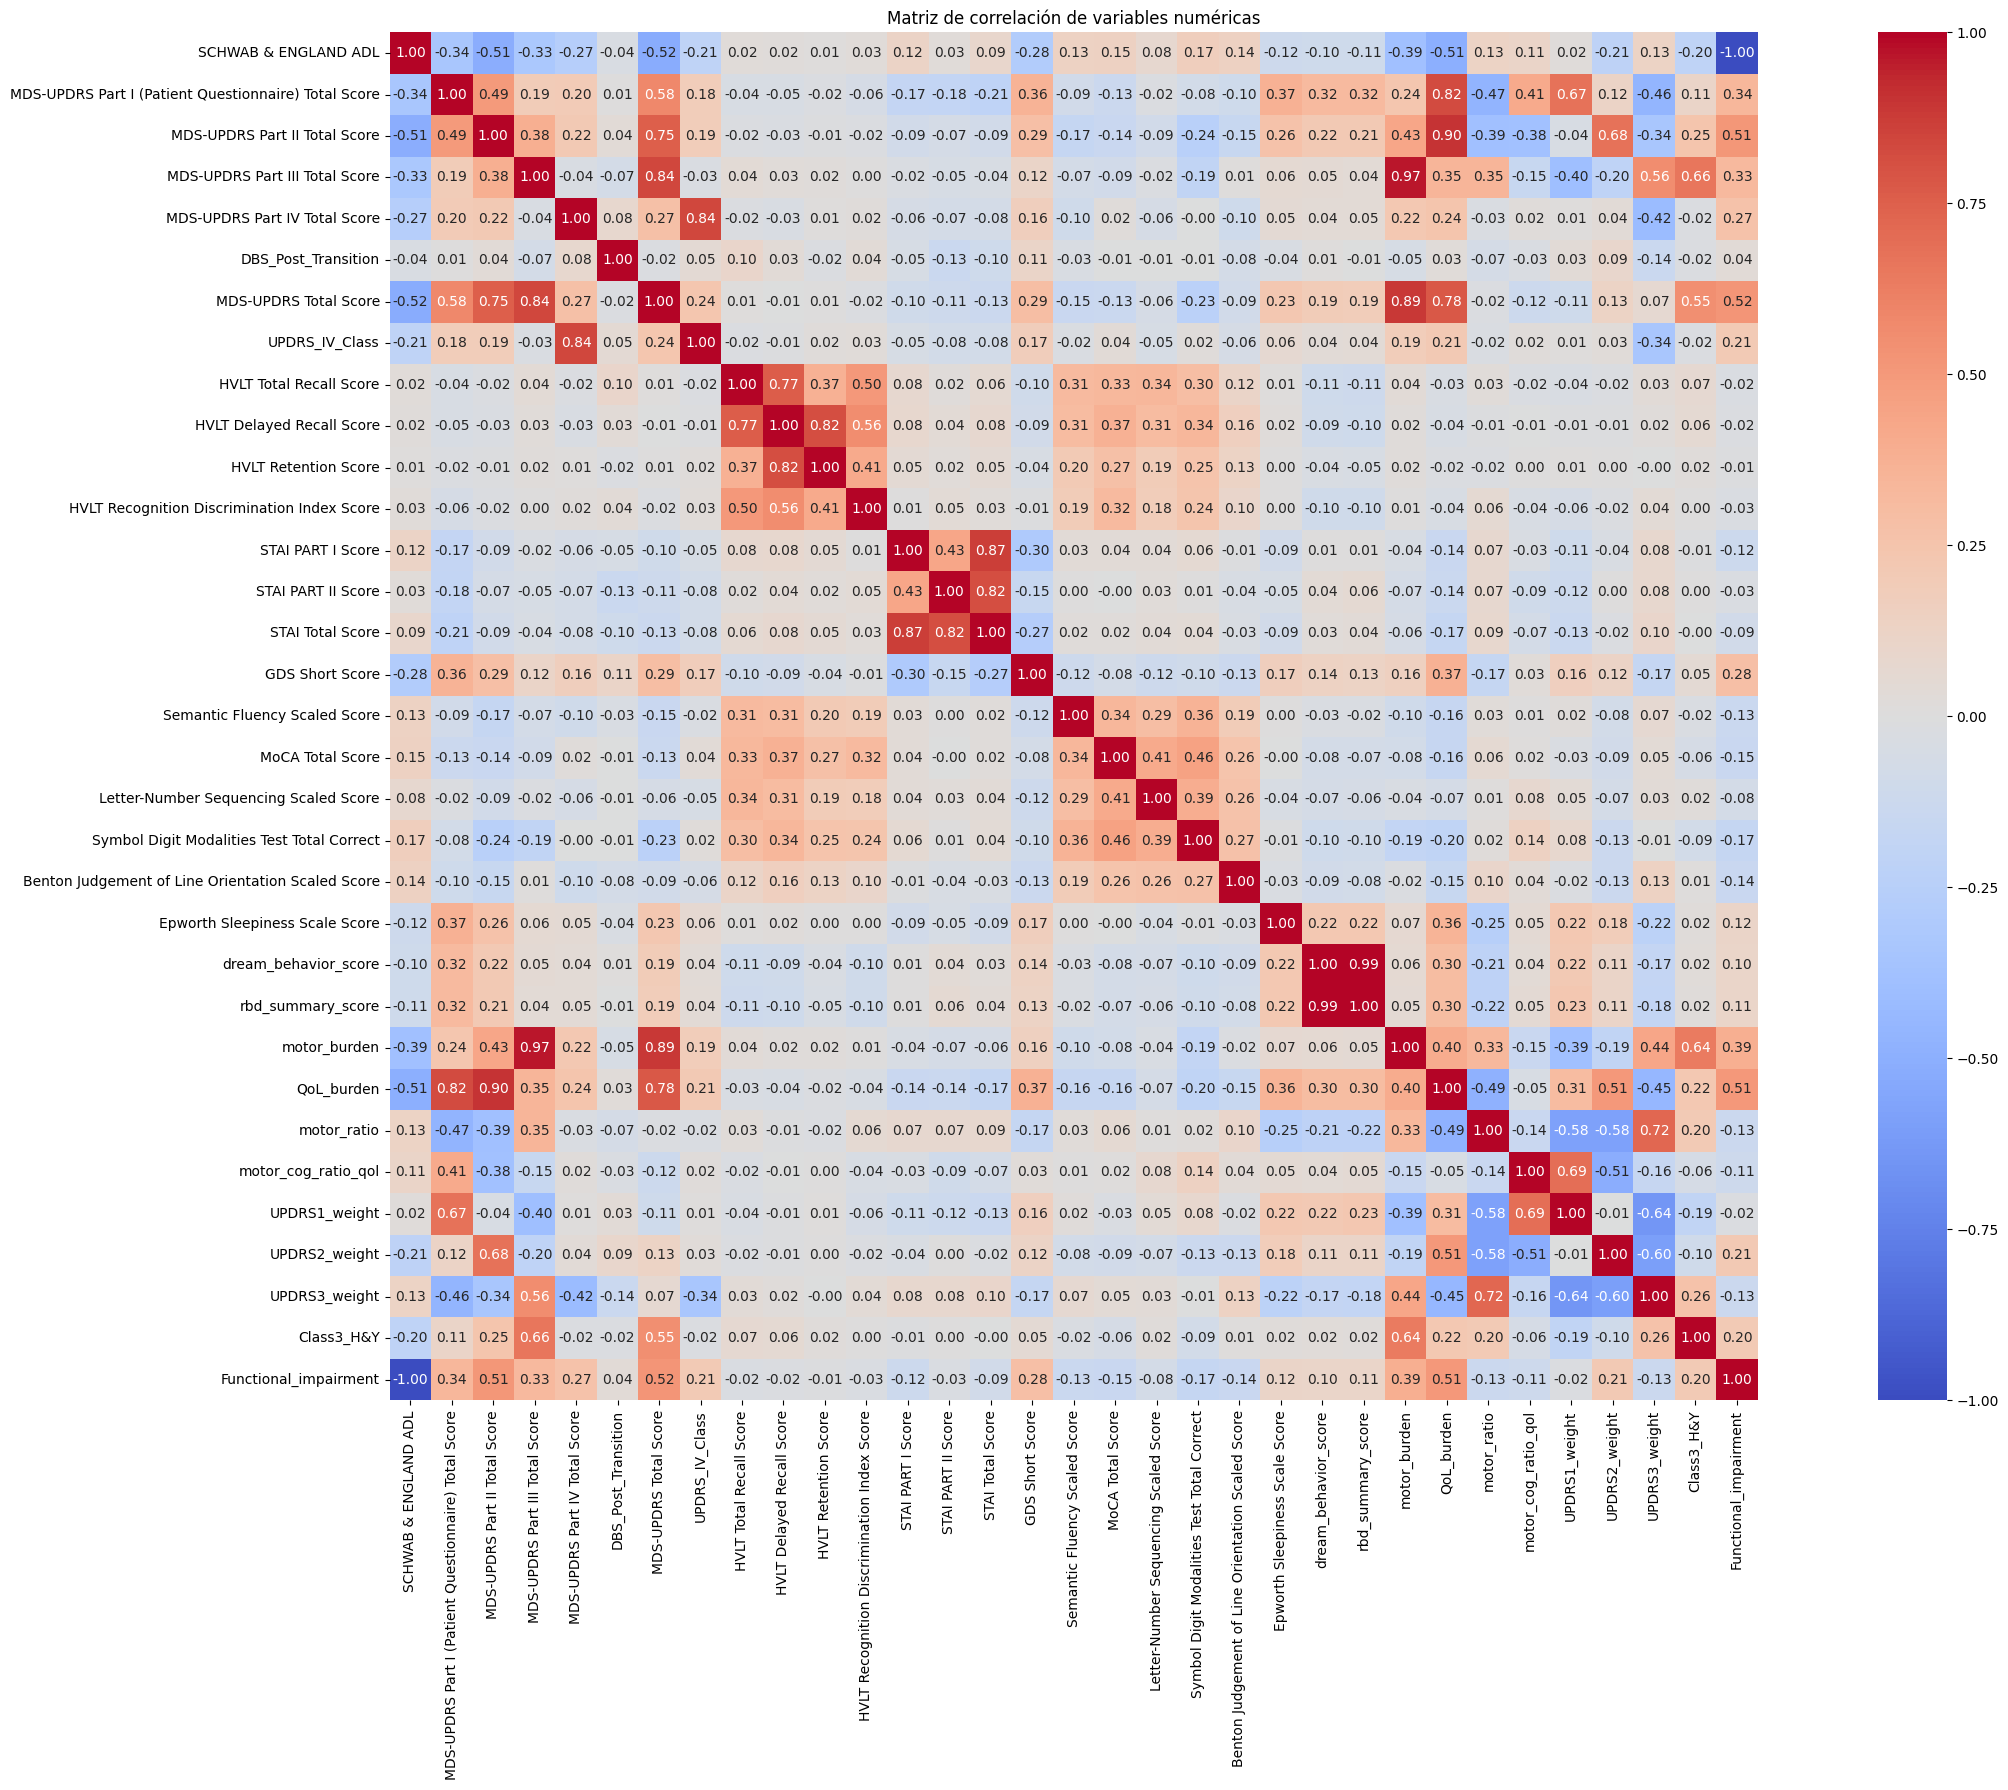

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular correlación
corr_matrix = X_train_fe[numerical_col_fe].corr()

# Crear el gráfico
plt.figure(figsize=(26, 18))
sns.heatmap(
    corr_matrix,
    annot=True,        # muestra los valores
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()


## PCA

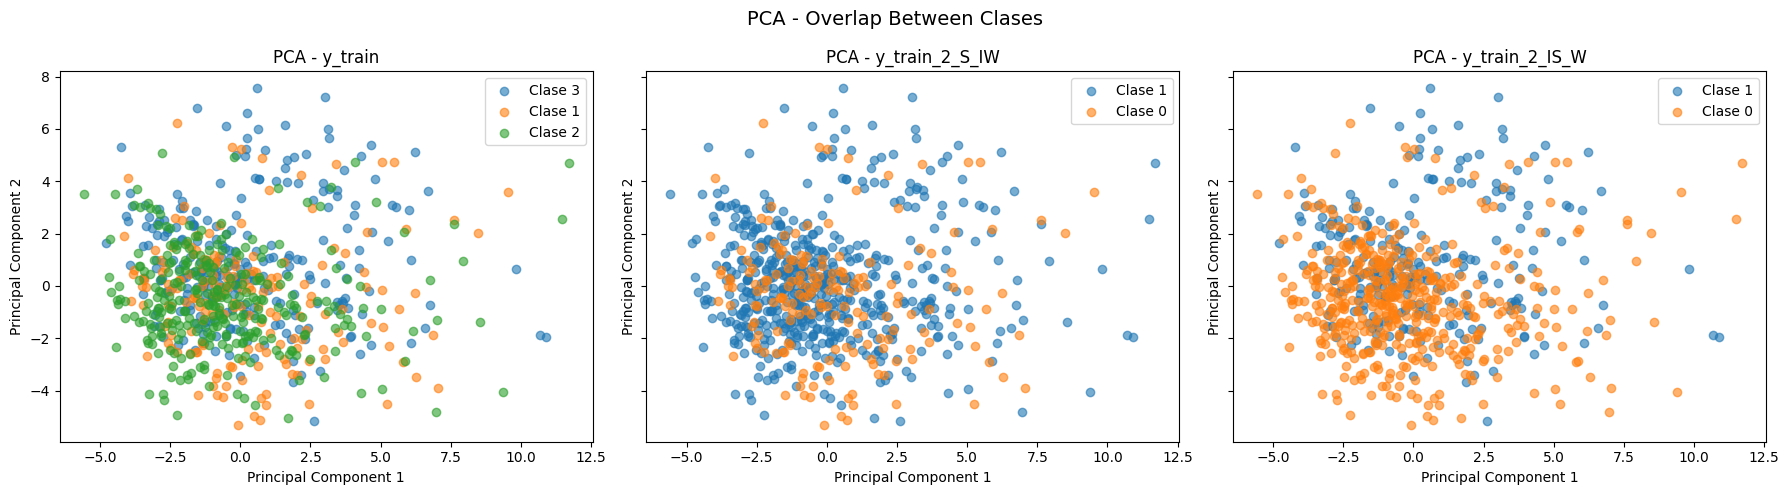

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Escalado
X_scaled = StandardScaler().fit_transform(X_train_fe)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Crear subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# --- Subplot 1 ---
for c in y_train.unique():
    axes[0].scatter(
        X_pca[y_train == c, 0],
        X_pca[y_train == c, 1],
        label=f"Clase {c}",
        alpha=0.6
    )
axes[0].set_title("PCA - y_train")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend()

# --- Subplot 2 ---
for c in y_train_2_S_IW.unique():
    axes[1].scatter(
        X_pca[y_train_2_S_IW == c, 0],
        X_pca[y_train_2_S_IW == c, 1],
        label=f"Clase {c}",
        alpha=0.6
    )
axes[1].set_title("PCA - y_train_2_S_IW")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].legend()

# --- Subplot 3 ---
for c in y_train_2_IS_W.unique():
    axes[2].scatter(
        X_pca[y_train_2_IS_W == c, 0],
        X_pca[y_train_2_IS_W == c, 1],
        label=f"Clase {c}",
        alpha=0.6
    )
axes[2].set_title("PCA - y_train_2_IS_W")
axes[2].set_xlabel("Principal Component 1")
axes[2].set_ylabel("Principal Component 2")
axes[2].legend()

plt.suptitle("PCA - Overlap Between Clases", fontsize=14)
plt.tight_layout()
plt.show()


/home/fsc/Desktop/PD_Project_UofL/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-30 14:23:13.203606: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 14:23:13.424006: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-30 14:23:14.230694: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see sli

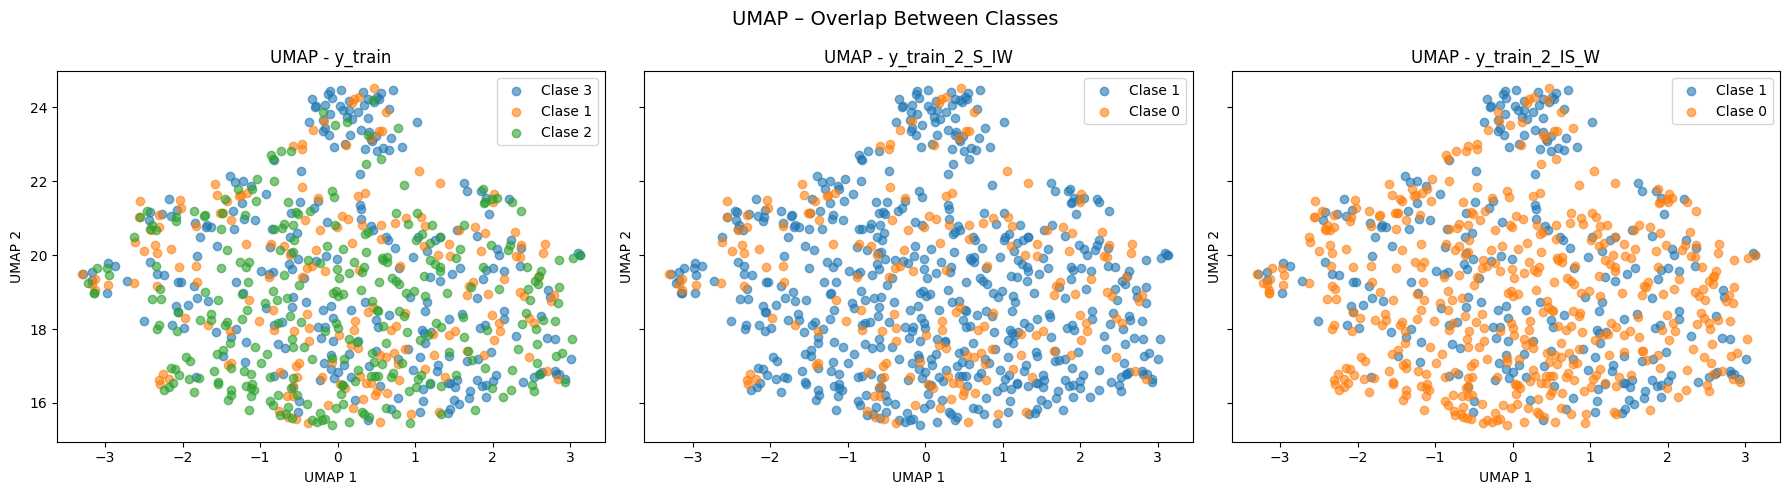

In [13]:
import numpy as np
from umap import UMAP

# Escalado (MISMO escalado que para PCA)
X_scaled = StandardScaler().fit_transform(X_train_fe)

# UMAP
umap = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.3,
    metric="euclidean",
    random_state=42
)
X_umap = umap.fit_transform(X_scaled)

# Crear subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# --- Subplot 1: 3 clases ---
for c in y_train.unique():
    axes[0].scatter(
        X_umap[y_train == c, 0],
        X_umap[y_train == c, 1],
        label=f"Clase {c}",
        alpha=0.6
    )
axes[0].set_title("UMAP - y_train")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].legend()

# --- Subplot 2: S vs IW ---
for c in y_train_2_S_IW.unique():
    axes[1].scatter(
        X_umap[y_train_2_S_IW == c, 0],
        X_umap[y_train_2_S_IW == c, 1],
        label=f"Clase {c}",
        alpha=0.6
    )
axes[1].set_title("UMAP - y_train_2_S_IW")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].legend()

# --- Subplot 3: IS vs W ---
for c in y_train_2_IS_W.unique():
    axes[2].scatter(
        X_umap[y_train_2_IS_W == c, 0],
        X_umap[y_train_2_IS_W == c, 1],
        label=f"Clase {c}",
        alpha=0.6
    )
axes[2].set_title("UMAP - y_train_2_IS_W")
axes[2].set_xlabel("UMAP 1")
axes[2].set_ylabel("UMAP 2")
axes[2].legend()

plt.suptitle("UMAP – Overlap Between Classes", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi_3 = mutual_info_classif(X_train_fe, y_train,random_state=42)
mi_3_series = pd.Series(mi_3, index=X_train_fe.columns)

mi_2_IS_W=mutual_info_classif(X_train_fe, y_train_2_IS_W,random_state=42)
mi_2_IS_W_series = pd.Series(mi_2_IS_W, index=X_train_fe.columns)

mi_2_S_IW=mutual_info_classif(X_train_fe, y_train_2_S_IW,random_state=42)
mi_2_S_IW_series = pd.Series(mi_2_S_IW, index=X_train_fe.columns)

# Top 10 columnas por información mutua
print("Top 10 features by mutual information - 3 classes:")
print(mi_3_series.sort_values(ascending=False).head(10))
print("\nTop 10 features by mutual information - 2 classes IS_W:")
print(mi_2_IS_W_series.sort_values(ascending=False).head(10))
print("\nTop 10 features by mutual information - 2 classes S_IW:")
print(mi_2_S_IW_series.sort_values(ascending=False).head(10))

# The mutual information for 2 classes (S_IW) has a low signal compared to the 3-class problem and the 2-class (IS_W) problem.

Top 10 features by mutual information - 3 classes:
MDS-UPDRS Part III Total Score    0.110880
UPDRS1_weight                     0.076148
HVLT Total Recall Score           0.059781
motor_ratio                       0.052276
MDS-UPDRS Part II Total Score     0.048143
motor_burden                      0.043957
Class3_H&Y                        0.042759
UPDRS_II_Class                    0.026140
QoL_burden                        0.026096
STAI PART II Score                0.023036
dtype: float64

Top 10 features by mutual information - 2 classes IS_W:
MDS-UPDRS Part III Total Score    0.094087
UPDRS1_weight                     0.072308
motor_ratio                       0.063391
motor_burden                      0.062816
Class3_H&Y                        0.037551
UPDRS_II_Class                    0.033552
MDS-UPDRS Total Score             0.033415
CN II-XII assessment              0.031190
UPDRS3_weight                     0.027360
HVLT Total Recall Score           0.022255
dtype: float64

T

## UMAP

# Model Default Analysis

In [17]:

# -------------------------------
# SKLEARN
# -------------------------------
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.metrics import make_scorer, recall_score, confusion_matrix,f1_score,precision_score,balanced_accuracy_score
from sklearn.base import clone
from sklearn.compose import ColumnTransformer


from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier 
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    GradientBoostingClassifier
)

from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
# -------------------------------
# BOOSTING EXTERNO
# -------------------------------
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


def specificity_weighted(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    n_classes = cm.shape[0]

    total_samples = np.sum(cm)
    specificities = []
    supports = []

    for k in range(n_classes):
        TP = cm[k, k]
        FN = np.sum(cm[k, :]) - TP
        FP = np.sum(cm[:, k]) - TP
        TN = total_samples - (TP + FN + FP)

        spec_k = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificities.append(spec_k)
        supports.append(np.sum(cm[k, :]))

    return np.average(specificities, weights=supports)


def g_mean(y_true, y_pred):
    sens = recall_score(y_true, y_pred, average="macro")
    spec = specificity_weighted(y_true, y_pred)
    return np.sqrt(sens * spec)




def cv_results_to_row(results, modelo_name, parameters):

    row = {
        "Model": modelo_name,
        "Parameters": parameters
    }

    for k in results:
        if k.startswith("train_") or k.startswith("test_"):
            prefix, metric = k.split("_", 1)

            mean = results[k].mean()
            

            col_name = f"{prefix}_{metric}"
            row[col_name] = f"{mean:.4f}"

    return pd.DataFrame([row])


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "acc": "accuracy",
    "bal_acc": make_scorer(balanced_accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro"),
    "f1_weighted": make_scorer(f1_score, average="weighted"),
    "prec_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "rec_macro": make_scorer(recall_score, average="macro", zero_division=0),
    "specificity_weighted": make_scorer(specificity_weighted),
    "g_mean": make_scorer(g_mean),
    
}


## Dummy Model Most Frequent Classifier 

In [23]:
# 1) Dummy model (baseline)
Dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)
# 2) Pipeline
pipe_dummy = Pipeline([
    ("clf", Dummy_model)
])

# 3) Cross-validation
results_dummy = cross_validate(
    pipe_dummy,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=True
)

# 4) Convertir resultados a fila
df_dummy1 = cv_results_to_row(
    results_dummy,
    modelo_name="DummyClassifier",
    parameters=" 3 Classes/ Most Frequent",
   
)

# 5) Para 2 Classes IS vs W
results_dummy_2_IS_W = cross_validate(
    pipe_dummy,
    X_train,
    y_train_2_IS_W,
    cv=skf,
    scoring=scoring,
    return_train_score=True
)

df_dummy2 = cv_results_to_row(
    results_dummy_2_IS_W,
    modelo_name="DummyClassifier",
    parameters="IS vs W / 2 Classes/ Most Frequent / Unbalanced"
)

# 6) Para 2 Classes S vs IW
results_dummy_2_S_IW = cross_validate(
    pipe_dummy,
    X_train,
    y_train_2_S_IW,
    cv=skf,
    scoring=scoring,
    return_train_score=True
)

df_dummy3 = cv_results_to_row(
    results_dummy_2_S_IW,
    modelo_name="DummyClassifier",
    parameters="S vs IW / 2 Classes/ Most Frequent / Unbalanced"
)
# 7) Balanced IS vs W with SMOTE
pipe_dummy_balanced = Pipeline([
    ('SMOTE', SMOTE(random_state=42)),
    ("clf", Dummy_model)])

results_dummy_2_IS_W_balanced = cross_validate(
    pipe_dummy_balanced,
    X_train,
    y_train_2_IS_W,
    cv=skf,
    scoring=scoring,
    return_train_score=True
)
df_dummy4 = cv_results_to_row(
    results_dummy_2_IS_W_balanced,
    modelo_name="DummyClassifier",
    parameters="IS vs W / 2 Classes/ Most Frequent / SMOTE"
)

# 8) Balanced S vs IW SMOTE
results_dummy_2_S_IW_balanced = cross_validate(
    pipe_dummy_balanced,
    X_train,
    y_train_2_S_IW,
    cv=skf,
    scoring=scoring,
    return_train_score=True
)

df_dummy5 = cv_results_to_row(
    results_dummy_2_S_IW_balanced,
    modelo_name="DummyClassifier",
    parameters="S vs IW / 2 Classes/ Most Frequent / SMOTE"
)

# 9) Balanced IS VS W with RandomOverSampler
pipe_dummy_ros = Pipeline([
    ('ROS', RandomOverSampler(random_state=42)),
    ("clf", Dummy_model)])

results_dummy_2_IS_W_balanced_ros = cross_validate(
    pipe_dummy_ros,
    X_train,
    y_train_2_IS_W,
    cv=skf,
    scoring=scoring,
    return_train_score=True
)

df_dummy6 = cv_results_to_row(
    results_dummy_2_IS_W_balanced_ros,
    modelo_name="DummyClassifier",
    parameters="IS vs W / 2 Classes/ Most Frequent / RandomOverSampler"
)

#10) Balanced S vs IW with RandomOverSampler
results_dummy_2_S_IW_balanced_ros = cross_validate(
    pipe_dummy_ros,
    X_train,
    y_train_2_S_IW,
    cv=skf,
    scoring=scoring,
    return_train_score=True
)

df_dummy7 = cv_results_to_row(
    results_dummy_2_S_IW_balanced_ros,
    modelo_name="DummyClassifier",
    parameters="S vs IW / 2 Classes/ Most Frequent / RandomOverSampler"
)



# Combinar todos los resultados en un solo DataFrame
df_all_dummies = pd.concat([df_dummy1, df_dummy2, df_dummy3,df_dummy4,df_dummy5,df_dummy6,df_dummy7], ignore_index=True)
df_all_dummies



,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,DummyClassifier,3 Classes/ Most Frequent,0.3956,0.3956,0.3333,0.3333,0.1890,0.1890,0.2243,0.2243,0.1319,0.1319,0.3333,0.3333,0.6044,0.6044,0.4489,0.4488
1,DummyClassifier,IS vs W / 2 Classes/ Most Frequent / Unbalanced,0.6429,0.6429,0.5000,0.5000,0.3913,0.3913,0.5031,0.5031,0.3214,0.3214,0.5000,0.5000,0.3571,0.3571,0.4226,0.4226
2,DummyClassifier,S vs IW / 2 Classes/ Most Frequent / Unbalanced,0.7527,0.7527,0.5000,0.5000,0.4295,0.4295,0.6466,0.6466,0.3764,0.3764,0.5000,0.5000,0.2473,0.2473,0.3516,0.3516
3,DummyClassifier,IS vs W / 2 Classes/ Most Frequent / SMOTE,0.6429,0.6429,0.5000,0.5000,0.3913,0.3913,0.5031,0.5031,0.3214,0.3214,0.5000,0.5000,0.3571,0.3571,0.4226,0.4226
4,DummyClassifier,S vs IW / 2 Classes/ Most Frequent / SMOTE,0.2473,0.2473,0.5000,0.5000,0.1982,0.1982,0.0980,0.0980,0.1236,0.1236,0.5000,0.5000,0.7527,0.7527,0.6135,0.6135
5,DummyClassifier,IS vs W / 2 Classes/ Most Frequent / RandomOve...,0.6429,0.6429,0.5000,0.5000,0.3913,0.3913,0.5031,0.5031,0.3214,0.3214,0.5000,0.5000,0.3571,0.3571,0.4226,0.4226
6,DummyClassifier,S vs IW / 2 Classes/ Most Frequent / RandomOve...,0.2473,0.2473,0.5000,0.5000,0.1982,0.1982,0.0980,0.0980,0.1236,0.1236,0.5000,0.5000,0.7527,0.7527,0.6135,0.6135


## 1. Baselines lineales

### 1.1 Logistic Regression

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif

class_training = {
    # 3 clases (SIN Feature Selection)
    '3 Classes / Normal / No Scaler / Unbalanced': [X_train, y_train, 'passthrough', 'passthrough', 'passthrough'],
    '3 Classes / Normal / StandardScaler / Unbalanced': [X_train, y_train, StandardScaler(), 'passthrough', 'passthrough'],
    '3 Classes / Normal / MinMaxScaler / Unbalanced': [X_train, y_train, MinMaxScaler(), 'passthrough', 'passthrough'],

    '3 Classes / Feature Engineering / No Scaler / Unbalanced': [X_train_fe, y_train, 'passthrough', 'passthrough', 'passthrough'],
    '3 Classes / Feature Engineering / StandardScaler / Unbalanced': [X_train_fe, y_train, StandardScaler(), 'passthrough', 'passthrough'],
    '3 Classes / Feature Engineering / MinMaxScaler / Unbalanced': [X_train_fe, y_train, MinMaxScaler(), 'passthrough', 'passthrough'],

    # 2 clases IS vs W (SIN Feature Selection)
    '2 Classes IS vs W / Normal / No Scaler / Unbalanced': [X_train, y_train_2_IS_W, 'passthrough', 'passthrough', 'passthrough'],
    '2 Classes IS vs W / Normal / No Scaler / SMOTE': [X_train, y_train_2_IS_W, 'passthrough', SMOTE(random_state=42), 'passthrough'],
    '2 Classes IS vs W / Normal / No Scaler / RandomOverSampler': [X_train, y_train_2_IS_W, 'passthrough', RandomOverSampler(random_state=42), 'passthrough'],

    '2 Classes IS vs W / Normal / StandardScaler / Unbalanced': [X_train, y_train_2_IS_W, StandardScaler(), 'passthrough', 'passthrough'],
    '2 Classes IS vs W / Normal / StandardScaler / SMOTE': [X_train, y_train_2_IS_W, StandardScaler(), SMOTE(random_state=42), 'passthrough'],
    '2 Classes IS vs W / Normal / StandardScaler / RandomOverSampler': [X_train, y_train_2_IS_W, StandardScaler(), RandomOverSampler(random_state=42), 'passthrough'],

    '2 Classes IS vs W / Normal / MinMaxScaler / Unbalanced': [X_train, y_train_2_IS_W, MinMaxScaler(), 'passthrough', 'passthrough'],
    '2 Classes IS vs W / Normal / MinMaxScaler / SMOTE': [X_train, y_train_2_IS_W, MinMaxScaler(), SMOTE(random_state=42), 'passthrough'],
    '2 Classes IS vs W / Normal / MinMaxScaler / RandomOverSampler': [X_train, y_train_2_IS_W, MinMaxScaler(), RandomOverSampler(random_state=42), 'passthrough'],

    '2 Classes IS vs W / Feature Engineering / No Scaler / Unbalanced': [X_train_fe, y_train_2_IS_W, 'passthrough', 'passthrough', 'passthrough'],
    '2 Classes IS vs W / Feature Engineering / No Scaler / SMOTE': [X_train_fe, y_train_2_IS_W, 'passthrough', SMOTE(random_state=42), 'passthrough'],
    '2 Classes IS vs W / Feature Engineering / No Scaler / RandomOverSampler': [X_train_fe, y_train_2_IS_W, 'passthrough', RandomOverSampler(random_state=42), 'passthrough'],

    '2 Classes IS vs W / Feature Engineering / StandardScaler / Unbalanced': [X_train_fe, y_train_2_IS_W, StandardScaler(), 'passthrough', 'passthrough'],
    '2 Classes IS vs W / Feature Engineering / StandardScaler / SMOTE': [X_train_fe, y_train_2_IS_W, StandardScaler(), SMOTE(random_state=42), 'passthrough'],
    '2 Classes IS vs W / Feature Engineering / StandardScaler / RandomOverSampler': [X_train_fe, y_train_2_IS_W, StandardScaler(), RandomOverSampler(random_state=42), 'passthrough'],

    '2 Classes IS vs W / Feature Engineering / MinMaxScaler / Unbalanced': [X_train_fe, y_train_2_IS_W, MinMaxScaler(), 'passthrough', 'passthrough'],
    '2 Classes IS vs W / Feature Engineering / MinMaxScaler / SMOTE': [X_train_fe, y_train_2_IS_W, MinMaxScaler(), SMOTE(random_state=42), 'passthrough'],
    '2 Classes IS vs W / Feature Engineering / MinMaxScaler / RandomOverSampler': [X_train_fe, y_train_2_IS_W, MinMaxScaler(), RandomOverSampler(random_state=42), 'passthrough'],

    # 2 clases S vs IW (SIN Feature Selection)
    '2 Classes S vs IW / Normal / No Scaler / Unbalanced': [X_train, y_train_2_S_IW, 'passthrough', 'passthrough', 'passthrough'],
    '2 Classes S vs IW / Normal / No Scaler / SMOTE': [X_train, y_train_2_S_IW, 'passthrough', SMOTE(random_state=42), 'passthrough'],
    '2 Classes S vs IW / Normal / No Scaler / RandomOverSampler': [X_train, y_train_2_S_IW, 'passthrough', RandomOverSampler(random_state=42), 'passthrough'],

    '2 Classes S vs IW / Normal / StandardScaler / Unbalanced': [X_train, y_train_2_S_IW, StandardScaler(), 'passthrough', 'passthrough'],
    '2 Classes S vs IW / Normal / StandardScaler / SMOTE': [X_train, y_train_2_S_IW, StandardScaler(), SMOTE(random_state=42), 'passthrough'],
    '2 Classes S vs IW / Normal / StandardScaler / RandomOverSampler': [X_train, y_train_2_S_IW, StandardScaler(), RandomOverSampler(random_state=42), 'passthrough'],

    '2 Classes S vs IW / Normal / MinMaxScaler / Unbalanced': [X_train, y_train_2_S_IW, MinMaxScaler(), 'passthrough', 'passthrough'],
    '2 Classes S vs IW / Normal / MinMaxScaler / SMOTE': [X_train, y_train_2_S_IW, MinMaxScaler(), SMOTE(random_state=42), 'passthrough'],
    '2 Classes S vs IW / Normal / MinMaxScaler / RandomOverSampler': [X_train, y_train_2_S_IW, MinMaxScaler(), RandomOverSampler(random_state=42), 'passthrough'],

    '2 Classes S vs IW / Feature Engineering / No Scaler / Unbalanced': [X_train_fe, y_train_2_S_IW, 'passthrough', 'passthrough', 'passthrough'],
    '2 Classes S vs IW / Feature Engineering / No Scaler / SMOTE': [X_train_fe, y_train_2_S_IW, 'passthrough', SMOTE(random_state=42), 'passthrough'],
    '2 Classes S vs IW / Feature Engineering / No Scaler / RandomOverSampler': [X_train_fe, y_train_2_S_IW, 'passthrough', RandomOverSampler(random_state=42), 'passthrough'],

    '2 Classes S vs IW / Feature Engineering / StandardScaler / Unbalanced': [X_train_fe, y_train_2_S_IW, StandardScaler(), 'passthrough', 'passthrough'],
    '2 Classes S vs IW / Feature Engineering / StandardScaler / SMOTE': [X_train_fe, y_train_2_S_IW, StandardScaler(), SMOTE(random_state=42), 'passthrough'],
    '2 Classes S vs IW / Feature Engineering / StandardScaler / RandomOverSampler': [X_train_fe, y_train_2_S_IW, StandardScaler(), RandomOverSampler(random_state=42), 'passthrough'],

    '2 Classes S vs IW / Feature Engineering / MinMaxScaler / Unbalanced': [X_train_fe, y_train_2_S_IW, MinMaxScaler(), 'passthrough', 'passthrough'],
    '2 Classes S vs IW / Feature Engineering / MinMaxScaler / SMOTE': [X_train_fe, y_train_2_S_IW, MinMaxScaler(), SMOTE(random_state=42), 'passthrough'],
    '2 Classes S vs IW / Feature Engineering / MinMaxScaler / RandomOverSampler': [X_train_fe, y_train_2_S_IW, MinMaxScaler(), RandomOverSampler(random_state=42), 'passthrough'],


    # =========================
    # CON Feature Selection
    # (SelectKBest(f_classif, k=10))
    # =========================

    # 3 clases (CON Feature Selection)
    '3 Classes / Normal / No Scaler / Unbalanced / Feature Selection': [X_train, y_train, 'passthrough', 'passthrough', SelectKBest(f_classif, k=10)],
    '3 Classes / Normal / StandardScaler / Unbalanced / Feature Selection': [X_train, y_train, StandardScaler(), 'passthrough', SelectKBest(f_classif, k=10)],
    '3 Classes / Normal / MinMaxScaler / Unbalanced / Feature Selection': [X_train, y_train, MinMaxScaler(), 'passthrough', SelectKBest(f_classif, k=10)],

    '3 Classes / Feature Engineering / No Scaler / Unbalanced / Feature Selection': [X_train_fe, y_train, 'passthrough', 'passthrough', SelectKBest(f_classif, k=10)],
    '3 Classes / Feature Engineering / StandardScaler / Unbalanced / Feature Selection': [X_train_fe, y_train, StandardScaler(), 'passthrough', SelectKBest(f_classif, k=10)],
    '3 Classes / Feature Engineering / MinMaxScaler / Unbalanced / Feature Selection': [X_train_fe, y_train, MinMaxScaler(), 'passthrough', SelectKBest(f_classif, k=10)],

    # 2 clases IS vs W (CON Feature Selection)
    '2 Classes IS vs W / Normal / No Scaler / Unbalanced / Feature Selection': [X_train, y_train_2_IS_W, 'passthrough', 'passthrough', SelectKBest(f_classif, k=10)],
    '2 Classes IS vs W / Normal / No Scaler / SMOTE / Feature Selection': [X_train, y_train_2_IS_W, 'passthrough', SMOTE(random_state=42), SelectKBest(f_classif, k=10)],
    '2 Classes IS vs W / Normal / No Scaler / RandomOverSampler / Feature Selection': [X_train, y_train_2_IS_W, 'passthrough', RandomOverSampler(random_state=42), SelectKBest(f_classif, k=10)],

    '2 Classes IS vs W / Normal / StandardScaler / Unbalanced / Feature Selection': [X_train, y_train_2_IS_W, StandardScaler(), 'passthrough', SelectKBest(f_classif, k=10)],
    '2 Classes IS vs W / Normal / StandardScaler / SMOTE / Feature Selection': [X_train, y_train_2_IS_W, StandardScaler(), SMOTE(random_state=42), SelectKBest(f_classif, k=10)],
    '2 Classes IS vs W / Normal / StandardScaler / RandomOverSampler / Feature Selection': [X_train, y_train_2_IS_W, StandardScaler(), RandomOverSampler(random_state=42), SelectKBest(f_classif, k=10)],

    '2 Classes IS vs W / Normal / MinMaxScaler / Unbalanced / Feature Selection': [X_train, y_train_2_IS_W, MinMaxScaler(), 'passthrough', SelectKBest(f_classif, k=10)],
    '2 Classes IS vs W / Normal / MinMaxScaler / SMOTE / Feature Selection': [X_train, y_train_2_IS_W, MinMaxScaler(), SMOTE(random_state=42), SelectKBest(f_classif, k=10)],
    '2 Classes IS vs W / Normal / MinMaxScaler / RandomOverSampler / Feature Selection': [X_train, y_train_2_IS_W, MinMaxScaler(), RandomOverSampler(random_state=42), SelectKBest(f_classif, k=10)],

    '2 Classes IS vs W / Feature Engineering / No Scaler / Unbalanced / Feature Selection': [X_train_fe, y_train_2_IS_W, 'passthrough', 'passthrough', SelectKBest(f_classif, k=10)],
    '2 Classes IS vs W / Feature Engineering / No Scaler / SMOTE / Feature Selection': [X_train_fe, y_train_2_IS_W, 'passthrough', SMOTE(random_state=42), SelectKBest(f_classif, k=10)],
    '2 Classes IS vs W / Feature Engineering / No Scaler / RandomOverSampler / Feature Selection': [X_train_fe, y_train_2_IS_W, 'passthrough', RandomOverSampler(random_state=42), SelectKBest(f_classif, k=10)],

    '2 Classes IS vs W / Feature Engineering / StandardScaler / Unbalanced / Feature Selection': [X_train_fe, y_train_2_IS_W, StandardScaler(), 'passthrough', SelectKBest(f_classif, k=10)],
    '2 Classes IS vs W / Feature Engineering / StandardScaler / SMOTE / Feature Selection': [X_train_fe, y_train_2_IS_W, StandardScaler(), SMOTE(random_state=42), SelectKBest(f_classif, k=10)],
    '2 Classes IS vs W / Feature Engineering / StandardScaler / RandomOverSampler / Feature Selection': [X_train_fe, y_train_2_IS_W, StandardScaler(), RandomOverSampler(random_state=42), SelectKBest(f_classif, k=10)],

    '2 Classes IS vs W / Feature Engineering / MinMaxScaler / Unbalanced / Feature Selection': [X_train_fe, y_train_2_IS_W, MinMaxScaler(), 'passthrough', SelectKBest(f_classif, k=10)],
    '2 Classes IS vs W / Feature Engineering / MinMaxScaler / SMOTE / Feature Selection': [X_train_fe, y_train_2_IS_W, MinMaxScaler(), SMOTE(random_state=42), SelectKBest(f_classif, k=10)],
    '2 Classes IS vs W / Feature Engineering / MinMaxScaler / RandomOverSampler / Feature Selection': [X_train_fe, y_train_2_IS_W, MinMaxScaler(), RandomOverSampler(random_state=42), SelectKBest(f_classif, k=10)],

    # 2 clases S vs IW (CON Feature Selection)
    '2 Classes S vs IW / Normal / No Scaler / Unbalanced / Feature Selection': [X_train, y_train_2_S_IW, 'passthrough', 'passthrough', SelectKBest(f_classif, k=10)],
    '2 Classes S vs IW / Normal / No Scaler / SMOTE / Feature Selection': [X_train, y_train_2_S_IW, 'passthrough', SMOTE(random_state=42), SelectKBest(f_classif, k=10)],
    '2 Classes S vs IW / Normal / No Scaler / RandomOverSampler / Feature Selection': [X_train, y_train_2_S_IW, 'passthrough', RandomOverSampler(random_state=42), SelectKBest(f_classif, k=10)],

    '2 Classes S vs IW / Normal / StandardScaler / Unbalanced / Feature Selection': [X_train, y_train_2_S_IW, StandardScaler(), 'passthrough', SelectKBest(f_classif, k=10)],
    '2 Classes S vs IW / Normal / StandardScaler / SMOTE / Feature Selection': [X_train, y_train_2_S_IW, StandardScaler(), SMOTE(random_state=42), SelectKBest(f_classif, k=10)],
    '2 Classes S vs IW / Normal / StandardScaler / RandomOverSampler / Feature Selection': [X_train, y_train_2_S_IW, StandardScaler(), RandomOverSampler(random_state=42), SelectKBest(f_classif, k=10)],

    '2 Classes S vs IW / Normal / MinMaxScaler / Unbalanced / Feature Selection': [X_train, y_train_2_S_IW, MinMaxScaler(), 'passthrough', SelectKBest(f_classif, k=10)],
    '2 Classes S vs IW / Normal / MinMaxScaler / SMOTE / Feature Selection': [X_train, y_train_2_S_IW, MinMaxScaler(), SMOTE(random_state=42), SelectKBest(f_classif, k=10)],
    '2 Classes S vs IW / Normal / MinMaxScaler / RandomOverSampler / Feature Selection': [X_train, y_train_2_S_IW, MinMaxScaler(), RandomOverSampler(random_state=42), SelectKBest(f_classif, k=10)],

    '2 Classes S vs IW / Feature Engineering / No Scaler / Unbalanced / Feature Selection': [X_train_fe, y_train_2_S_IW, 'passthrough', 'passthrough', SelectKBest(f_classif, k=10)],
    '2 Classes S vs IW / Feature Engineering / No Scaler / SMOTE / Feature Selection': [X_train_fe, y_train_2_S_IW, 'passthrough', SMOTE(random_state=42), SelectKBest(f_classif, k=10)],
    '2 Classes S vs IW / Feature Engineering / No Scaler / RandomOverSampler / Feature Selection': [X_train_fe, y_train_2_S_IW, 'passthrough', RandomOverSampler(random_state=42), SelectKBest(f_classif, k=10)],

    '2 Classes S vs IW / Feature Engineering / StandardScaler / Unbalanced / Feature Selection': [X_train_fe, y_train_2_S_IW, StandardScaler(), 'passthrough', SelectKBest(f_classif, k=10)],
    '2 Classes S vs IW / Feature Engineering / StandardScaler / SMOTE / Feature Selection': [X_train_fe, y_train_2_S_IW, StandardScaler(), SMOTE(random_state=42), SelectKBest(f_classif, k=10)],
    '2 Classes S vs IW / Feature Engineering / StandardScaler / RandomOverSampler / Feature Selection': [X_train_fe, y_train_2_S_IW, StandardScaler(), RandomOverSampler(random_state=42), SelectKBest(f_classif, k=10)],

    '2 Classes S vs IW / Feature Engineering / MinMaxScaler / Unbalanced / Feature Selection': [X_train_fe, y_train_2_S_IW, MinMaxScaler(), 'passthrough', SelectKBest(f_classif, k=10)],
    '2 Classes S vs IW / Feature Engineering / MinMaxScaler / SMOTE / Feature Selection': [X_train_fe, y_train_2_S_IW, MinMaxScaler(), SMOTE(random_state=42), SelectKBest(f_classif, k=10)],
    '2 Classes S vs IW / Feature Engineering / MinMaxScaler / RandomOverSampler / Feature Selection': [X_train_fe, y_train_2_S_IW, MinMaxScaler(), RandomOverSampler(random_state=42), SelectKBest(f_classif, k=10)],
}



def model_default_evaluation(dict_class, model):

    df_results_all = pd.DataFrame()
    len_dict = len(dict_class)
    for key in dict_class:
        print(f"Evaluating {type(model).__name__} - {key} ({list(dict_class).index(key)+1}/{len_dict})")
        X_tr = dict_class[key][0]
        y_tr = dict_class[key][1]
        scaler = dict_class[key][2]
        sampler = dict_class[key][3]
        selector =dict_class[key][4]

        num_pipe = Pipeline([
            ("select", selector),
            ("scale", scaler)
        ])

        cat_pipe = Pipeline([
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])

        preprocess = ColumnTransformer([
            ("num", num_pipe, numerical_col),
            ("cat", cat_pipe, categroical_col)
])


        pipe = Pipeline(steps=[
            ("prep", preprocess),
            ('sampler', sampler),
            ('clf', clone(model)),
        ])

        results = cross_validate(
            pipe,
            X_tr,
            y_tr,
            cv=skf,               
            scoring=scoring,      
            return_train_score=True
        )

        df_results = cv_results_to_row(   
            results,
            modelo_name=type(model).__name__,
            parameters=key
        )

        df_results_all = pd.concat([df_results_all, df_results], ignore_index=True)

    return df_results_all





In [ ]:

log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_result = model_default_evaluation(class_training, log_reg_model)
log_reg_result.head()

### 1.2 Ridge Classifier

In [25]:
ridge_model = RidgeClassifier(random_state=42)
ridge_result = model_default_evaluation(class_training, ridge_model)
ridge_result.head()


Evaluating RidgeClassifier - 3 Classes / Normal / No Scaler / Unbalanced (1/84)
Evaluating RidgeClassifier - 3 Classes / Normal / StandardScaler / Unbalanced (2/84)
Evaluating RidgeClassifier - 3 Classes / Normal / MinMaxScaler / Unbalanced (3/84)
Evaluating RidgeClassifier - 3 Classes / Feature Engineering / No Scaler / Unbalanced (4/84)
Evaluating RidgeClassifier - 3 Classes / Feature Engineering / StandardScaler / Unbalanced (5/84)
Evaluating RidgeClassifier - 3 Classes / Feature Engineering / MinMaxScaler / Unbalanced (6/84)
Evaluating RidgeClassifier - 2 Classes IS vs W / Normal / No Scaler / Unbalanced (7/84)
Evaluating RidgeClassifier - 2 Classes IS vs W / Normal / No Scaler / SMOTE (8/84)
Evaluating RidgeClassifier - 2 Classes IS vs W / Normal / No Scaler / RandomOverSampler (9/84)
Evaluating RidgeClassifier - 2 Classes IS vs W / Normal / StandardScaler / Unbalanced (10/84)
Evaluating RidgeClassifier - 2 Classes IS vs W / Normal / StandardScaler / SMOTE (11/84)
Evaluating Ridge

,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,RidgeClassifier,3 Classes / Normal / No Scaler / Unbalanced,0.4464,0.5326,0.4071,0.4980,0.3872,0.4934,0.4186,0.5153,0.3981,0.5286,0.4071,0.4980,0.6834,0.7292,0.5272,0.6025
1,RidgeClassifier,3 Classes / Normal / StandardScaler / Unbalanced,0.4450,0.5333,0.4058,0.4984,0.3861,0.4938,0.4173,0.5157,0.3972,0.5305,0.4058,0.4984,0.6822,0.7292,0.5259,0.6028
2,RidgeClassifier,3 Classes / Normal / MinMaxScaler / Unbalanced,0.4505,0.5323,0.4108,0.4949,0.3908,0.4881,0.4220,0.5117,0.4064,0.5321,0.4108,0.4949,0.6841,0.7263,0.5300,0.5995
3,RidgeClassifier,3 Classes / Feature Engineering / No Scaler / ...,0.4464,0.5326,0.4071,0.4980,0.3872,0.4934,0.4186,0.5153,0.3981,0.5286,0.4071,0.4980,0.6834,0.7292,0.5272,0.6025
4,RidgeClassifier,3 Classes / Feature Engineering / StandardScal...,0.4450,0.5333,0.4058,0.4984,0.3861,0.4938,0.4173,0.5157,0.3972,0.5305,0.4058,0.4984,0.6822,0.7292,0.5259,0.6028


### 1.3 Linear SVM

In [26]:
svm_linear_model = SVC(kernel='linear', random_state=42)
svm_linear_result = model_default_evaluation(class_training, svm_linear_model)
svm_linear_result.head()

Evaluating SVC - 3 Classes / Normal / No Scaler / Unbalanced (1/84)
Evaluating SVC - 3 Classes / Normal / StandardScaler / Unbalanced (2/84)
Evaluating SVC - 3 Classes / Normal / MinMaxScaler / Unbalanced (3/84)
Evaluating SVC - 3 Classes / Feature Engineering / No Scaler / Unbalanced (4/84)
Evaluating SVC - 3 Classes / Feature Engineering / StandardScaler / Unbalanced (5/84)
Evaluating SVC - 3 Classes / Feature Engineering / MinMaxScaler / Unbalanced (6/84)
Evaluating SVC - 2 Classes IS vs W / Normal / No Scaler / Unbalanced (7/84)
Evaluating SVC - 2 Classes IS vs W / Normal / No Scaler / SMOTE (8/84)
Evaluating SVC - 2 Classes IS vs W / Normal / No Scaler / RandomOverSampler (9/84)
Evaluating SVC - 2 Classes IS vs W / Normal / StandardScaler / Unbalanced (10/84)
Evaluating SVC - 2 Classes IS vs W / Normal / StandardScaler / SMOTE (11/84)
Evaluating SVC - 2 Classes IS vs W / Normal / StandardScaler / RandomOverSampler (12/84)
Evaluating SVC - 2 Classes IS vs W / Normal / MinMaxScaler 

,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,SVC,3 Classes / Normal / No Scaler / Unbalanced,0.4299,0.5364,0.3946,0.5046,0.3769,0.4996,0.4060,0.5203,0.3909,0.5318,0.3946,0.5046,0.6796,0.7339,0.5175,0.6085
1,SVC,3 Classes / Normal / StandardScaler / Unbalanced,0.4285,0.5364,0.3926,0.5033,0.3752,0.4973,0.4050,0.5189,0.3877,0.5306,0.3926,0.5033,0.6799,0.7329,0.5164,0.6073
2,SVC,3 Classes / Normal / MinMaxScaler / Unbalanced,0.4340,0.5285,0.3902,0.4821,0.3626,0.4618,0.3971,0.4934,0.3672,0.5264,0.3902,0.4821,0.6700,0.7176,0.5111,0.5881
3,SVC,3 Classes / Feature Engineering / No Scaler / ...,0.4299,0.5364,0.3946,0.5046,0.3769,0.4996,0.4060,0.5203,0.3909,0.5318,0.3946,0.5046,0.6796,0.7339,0.5175,0.6085
4,SVC,3 Classes / Feature Engineering / StandardScal...,0.4285,0.5364,0.3926,0.5033,0.3752,0.4973,0.4050,0.5189,0.3877,0.5306,0.3926,0.5033,0.6799,0.7329,0.5164,0.6073


## 2. Probabilístico

### 2.1 Gaussian Naive Bayes

In [27]:
GNB_model = GaussianNB()
GNB_result = model_default_evaluation(class_training, GNB_model)
GNB_result.head()

Evaluating GaussianNB - 3 Classes / Normal / No Scaler / Unbalanced (1/84)
Evaluating GaussianNB - 3 Classes / Normal / StandardScaler / Unbalanced (2/84)
Evaluating GaussianNB - 3 Classes / Normal / MinMaxScaler / Unbalanced (3/84)
Evaluating GaussianNB - 3 Classes / Feature Engineering / No Scaler / Unbalanced (4/84)
Evaluating GaussianNB - 3 Classes / Feature Engineering / StandardScaler / Unbalanced (5/84)
Evaluating GaussianNB - 3 Classes / Feature Engineering / MinMaxScaler / Unbalanced (6/84)
Evaluating GaussianNB - 2 Classes IS vs W / Normal / No Scaler / Unbalanced (7/84)
Evaluating GaussianNB - 2 Classes IS vs W / Normal / No Scaler / SMOTE (8/84)
Evaluating GaussianNB - 2 Classes IS vs W / Normal / No Scaler / RandomOverSampler (9/84)
Evaluating GaussianNB - 2 Classes IS vs W / Normal / StandardScaler / Unbalanced (10/84)
Evaluating GaussianNB - 2 Classes IS vs W / Normal / StandardScaler / SMOTE (11/84)
Evaluating GaussianNB - 2 Classes IS vs W / Normal / StandardScaler / R

,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,GaussianNB,3 Classes / Normal / No Scaler / Unbalanced,0.3900,0.4588,0.3631,0.4335,0.3211,0.4005,0.3393,0.4183,0.3690,0.4911,0.3631,0.4335,0.6611,0.6990,0.4896,0.5505
1,GaussianNB,3 Classes / Normal / StandardScaler / Unbalanced,0.3818,0.4334,0.3574,0.4112,0.2922,0.3523,0.3076,0.3664,0.3517,0.5012,0.3574,0.4112,0.6604,0.6887,0.4854,0.5321
2,GaussianNB,3 Classes / Normal / MinMaxScaler / Unbalanced,0.3790,0.4310,0.3544,0.4091,0.2868,0.3465,0.3026,0.3597,0.3443,0.5137,0.3544,0.4091,0.6591,0.6873,0.4829,0.5302
3,GaussianNB,3 Classes / Feature Engineering / No Scaler / ...,0.3900,0.4588,0.3631,0.4335,0.3211,0.4005,0.3393,0.4183,0.3690,0.4911,0.3631,0.4335,0.6611,0.6990,0.4896,0.5505
4,GaussianNB,3 Classes / Feature Engineering / StandardScal...,0.3818,0.4334,0.3574,0.4112,0.2922,0.3523,0.3076,0.3664,0.3517,0.5012,0.3574,0.4112,0.6604,0.6887,0.4854,0.5321


## 3. Árboles

### 3.1 Decision Tree Classifier

In [28]:
tree_model = DecisionTreeClassifier(random_state=42,max_depth=5)
tree_result = model_default_evaluation(class_training, tree_model)
tree_result.head()

Evaluating DecisionTreeClassifier - 3 Classes / Normal / No Scaler / Unbalanced (1/84)
Evaluating DecisionTreeClassifier - 3 Classes / Normal / StandardScaler / Unbalanced (2/84)
Evaluating DecisionTreeClassifier - 3 Classes / Normal / MinMaxScaler / Unbalanced (3/84)
Evaluating DecisionTreeClassifier - 3 Classes / Feature Engineering / No Scaler / Unbalanced (4/84)
Evaluating DecisionTreeClassifier - 3 Classes / Feature Engineering / StandardScaler / Unbalanced (5/84)
Evaluating DecisionTreeClassifier - 3 Classes / Feature Engineering / MinMaxScaler / Unbalanced (6/84)
Evaluating DecisionTreeClassifier - 2 Classes IS vs W / Normal / No Scaler / Unbalanced (7/84)
Evaluating DecisionTreeClassifier - 2 Classes IS vs W / Normal / No Scaler / SMOTE (8/84)
Evaluating DecisionTreeClassifier - 2 Classes IS vs W / Normal / No Scaler / RandomOverSampler (9/84)
Evaluating DecisionTreeClassifier - 2 Classes IS vs W / Normal / StandardScaler / Unbalanced (10/84)
Evaluating DecisionTreeClassifier -

,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,DecisionTreeClassifier,3 Classes / Normal / No Scaler / Unbalanced,0.4204,0.6319,0.3896,0.6022,0.3776,0.6035,0.4008,0.6192,0.3924,0.6574,0.3896,0.6022,0.6768,0.7866,0.5130,0.6882
1,DecisionTreeClassifier,3 Classes / Normal / StandardScaler / Unbalanced,0.4204,0.6319,0.3896,0.6022,0.3776,0.6035,0.4008,0.6192,0.3924,0.6574,0.3896,0.6022,0.6768,0.7866,0.5130,0.6882
2,DecisionTreeClassifier,3 Classes / Normal / MinMaxScaler / Unbalanced,0.4204,0.6319,0.3896,0.6022,0.3776,0.6035,0.4008,0.6192,0.3924,0.6574,0.3896,0.6022,0.6768,0.7866,0.5130,0.6882
3,DecisionTreeClassifier,3 Classes / Feature Engineering / No Scaler / ...,0.4204,0.6319,0.3896,0.6022,0.3776,0.6035,0.4008,0.6192,0.3924,0.6574,0.3896,0.6022,0.6768,0.7866,0.5130,0.6882
4,DecisionTreeClassifier,3 Classes / Feature Engineering / StandardScal...,0.4204,0.6319,0.3896,0.6022,0.3776,0.6035,0.4008,0.6192,0.3924,0.6574,0.3896,0.6022,0.6768,0.7866,0.5130,0.6882


## 4. Ensambles basados en árboles

### 4.1 Random Forest Classifier

In [29]:
random_forest_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5)
random_forest_result = model_default_evaluation(class_training, random_forest_model)
random_forest_result.head()

Evaluating RandomForestClassifier - 3 Classes / Normal / No Scaler / Unbalanced (1/84)
Evaluating RandomForestClassifier - 3 Classes / Normal / StandardScaler / Unbalanced (2/84)
Evaluating RandomForestClassifier - 3 Classes / Normal / MinMaxScaler / Unbalanced (3/84)
Evaluating RandomForestClassifier - 3 Classes / Feature Engineering / No Scaler / Unbalanced (4/84)
Evaluating RandomForestClassifier - 3 Classes / Feature Engineering / StandardScaler / Unbalanced (5/84)
Evaluating RandomForestClassifier - 3 Classes / Feature Engineering / MinMaxScaler / Unbalanced (6/84)
Evaluating RandomForestClassifier - 2 Classes IS vs W / Normal / No Scaler / Unbalanced (7/84)
Evaluating RandomForestClassifier - 2 Classes IS vs W / Normal / No Scaler / SMOTE (8/84)
Evaluating RandomForestClassifier - 2 Classes IS vs W / Normal / No Scaler / RandomOverSampler (9/84)
Evaluating RandomForestClassifier - 2 Classes IS vs W / Normal / StandardScaler / Unbalanced (10/84)
Evaluating RandomForestClassifier -

,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,RandomForestClassifier,3 Classes / Normal / No Scaler / Unbalanced,0.4506,0.6834,0.3996,0.6362,0.3553,0.6340,0.3956,0.6583,0.4401,0.7769,0.3996,0.6362,0.6673,0.8038,0.5163,0.7151
1,RandomForestClassifier,3 Classes / Normal / StandardScaler / Unbalanced,0.4492,0.6827,0.3982,0.6356,0.3537,0.6333,0.3940,0.6576,0.4389,0.7765,0.3982,0.6356,0.6664,0.8034,0.5150,0.7146
2,RandomForestClassifier,3 Classes / Normal / MinMaxScaler / Unbalanced,0.4492,0.6837,0.3984,0.6366,0.3541,0.6346,0.3943,0.6588,0.4392,0.7771,0.3984,0.6366,0.6664,0.8041,0.5151,0.7154
3,RandomForestClassifier,3 Classes / Feature Engineering / No Scaler / ...,0.4506,0.6834,0.3996,0.6362,0.3553,0.6340,0.3956,0.6583,0.4401,0.7769,0.3996,0.6362,0.6673,0.8038,0.5163,0.7151
4,RandomForestClassifier,3 Classes / Feature Engineering / StandardScal...,0.4492,0.6827,0.3982,0.6356,0.3537,0.6333,0.3940,0.6576,0.4389,0.7765,0.3982,0.6356,0.6664,0.8034,0.5150,0.7146


### 4.2 Extra Trees Classifier

In [30]:
extra_tree_model = ExtraTreesClassifier(random_state=42, n_estimators=100, max_depth=5)
extra_tree_result = model_default_evaluation(class_training, extra_tree_model)
extra_tree_result.head()

Evaluating ExtraTreesClassifier - 3 Classes / Normal / No Scaler / Unbalanced (1/84)
Evaluating ExtraTreesClassifier - 3 Classes / Normal / StandardScaler / Unbalanced (2/84)
Evaluating ExtraTreesClassifier - 3 Classes / Normal / MinMaxScaler / Unbalanced (3/84)
Evaluating ExtraTreesClassifier - 3 Classes / Feature Engineering / No Scaler / Unbalanced (4/84)
Evaluating ExtraTreesClassifier - 3 Classes / Feature Engineering / StandardScaler / Unbalanced (5/84)
Evaluating ExtraTreesClassifier - 3 Classes / Feature Engineering / MinMaxScaler / Unbalanced (6/84)
Evaluating ExtraTreesClassifier - 2 Classes IS vs W / Normal / No Scaler / Unbalanced (7/84)
Evaluating ExtraTreesClassifier - 2 Classes IS vs W / Normal / No Scaler / SMOTE (8/84)
Evaluating ExtraTreesClassifier - 2 Classes IS vs W / Normal / No Scaler / RandomOverSampler (9/84)
Evaluating ExtraTreesClassifier - 2 Classes IS vs W / Normal / StandardScaler / Unbalanced (10/84)
Evaluating ExtraTreesClassifier - 2 Classes IS vs W / N

,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,ExtraTreesClassifier,3 Classes / Normal / No Scaler / Unbalanced,0.4450,0.6095,0.3889,0.5521,0.3315,0.5304,0.3742,0.5650,0.4072,0.7544,0.3889,0.5521,0.6551,0.7528,0.5047,0.6447
1,ExtraTreesClassifier,3 Classes / Normal / StandardScaler / Unbalanced,0.4450,0.6095,0.3889,0.5521,0.3315,0.5304,0.3742,0.5650,0.4072,0.7544,0.3889,0.5521,0.6551,0.7528,0.5047,0.6447
2,ExtraTreesClassifier,3 Classes / Normal / MinMaxScaler / Unbalanced,0.4450,0.6095,0.3889,0.5521,0.3315,0.5304,0.3742,0.5650,0.4072,0.7544,0.3889,0.5521,0.6551,0.7528,0.5047,0.6447
3,ExtraTreesClassifier,3 Classes / Feature Engineering / No Scaler / ...,0.4450,0.6095,0.3889,0.5521,0.3315,0.5304,0.3742,0.5650,0.4072,0.7544,0.3889,0.5521,0.6551,0.7528,0.5047,0.6447
4,ExtraTreesClassifier,3 Classes / Feature Engineering / StandardScal...,0.4450,0.6095,0.3889,0.5521,0.3315,0.5304,0.3742,0.5650,0.4072,0.7544,0.3889,0.5521,0.6551,0.7528,0.5047,0.6447


## 5. Boosting

### 5.1 HistGradientBoosting Classifier

In [31]:
hist_gradient_boosting_model = HistGradientBoostingClassifier(random_state=42)
hist_gradient_boosting_result = model_default_evaluation(class_training, hist_gradient_boosting_model)
hist_gradient_boosting_result.head()

Evaluating HistGradientBoostingClassifier - 3 Classes / Normal / No Scaler / Unbalanced (1/84)
Evaluating HistGradientBoostingClassifier - 3 Classes / Normal / StandardScaler / Unbalanced (2/84)
Evaluating HistGradientBoostingClassifier - 3 Classes / Normal / MinMaxScaler / Unbalanced (3/84)
Evaluating HistGradientBoostingClassifier - 3 Classes / Feature Engineering / No Scaler / Unbalanced (4/84)
Evaluating HistGradientBoostingClassifier - 3 Classes / Feature Engineering / StandardScaler / Unbalanced (5/84)
Evaluating HistGradientBoostingClassifier - 3 Classes / Feature Engineering / MinMaxScaler / Unbalanced (6/84)
Evaluating HistGradientBoostingClassifier - 2 Classes IS vs W / Normal / No Scaler / Unbalanced (7/84)
Evaluating HistGradientBoostingClassifier - 2 Classes IS vs W / Normal / No Scaler / SMOTE (8/84)
Evaluating HistGradientBoostingClassifier - 2 Classes IS vs W / Normal / No Scaler / RandomOverSampler (9/84)
Evaluating HistGradientBoostingClassifier - 2 Classes IS vs W / 

,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,HistGradientBoostingClassifier,3 Classes / Normal / No Scaler / Unbalanced,0.4025,1.0000,0.3755,1.0000,0.3668,1.0000,0.3890,1.0000,0.3697,1.0000,0.3755,1.0000,0.6703,1.0000,0.5012,1.0000
1,HistGradientBoostingClassifier,3 Classes / Normal / StandardScaler / Unbalanced,0.4025,1.0000,0.3755,1.0000,0.3668,1.0000,0.3890,1.0000,0.3697,1.0000,0.3755,1.0000,0.6703,1.0000,0.5012,1.0000
2,HistGradientBoostingClassifier,3 Classes / Normal / MinMaxScaler / Unbalanced,0.4025,1.0000,0.3755,1.0000,0.3668,1.0000,0.3890,1.0000,0.3697,1.0000,0.3755,1.0000,0.6703,1.0000,0.5012,1.0000
3,HistGradientBoostingClassifier,3 Classes / Feature Engineering / No Scaler / ...,0.4025,1.0000,0.3755,1.0000,0.3668,1.0000,0.3890,1.0000,0.3697,1.0000,0.3755,1.0000,0.6703,1.0000,0.5012,1.0000
4,HistGradientBoostingClassifier,3 Classes / Feature Engineering / StandardScal...,0.4025,1.0000,0.3755,1.0000,0.3668,1.0000,0.3890,1.0000,0.3697,1.0000,0.3755,1.0000,0.6703,1.0000,0.5012,1.0000


### 5.2 XGBoost Classifier 

In [32]:
# Gradient Boosting doesn't support negative target values
gradient_boosting_model = GradientBoostingClassifier(random_state=42)
gradient_boosting_result = model_default_evaluation(class_training, gradient_boosting_model)
gradient_boosting_result.head()

Evaluating GradientBoostingClassifier - 3 Classes / Normal / No Scaler / Unbalanced (1/84)
Evaluating GradientBoostingClassifier - 3 Classes / Normal / StandardScaler / Unbalanced (2/84)
Evaluating GradientBoostingClassifier - 3 Classes / Normal / MinMaxScaler / Unbalanced (3/84)
Evaluating GradientBoostingClassifier - 3 Classes / Feature Engineering / No Scaler / Unbalanced (4/84)
Evaluating GradientBoostingClassifier - 3 Classes / Feature Engineering / StandardScaler / Unbalanced (5/84)
Evaluating GradientBoostingClassifier - 3 Classes / Feature Engineering / MinMaxScaler / Unbalanced (6/84)
Evaluating GradientBoostingClassifier - 2 Classes IS vs W / Normal / No Scaler / Unbalanced (7/84)
Evaluating GradientBoostingClassifier - 2 Classes IS vs W / Normal / No Scaler / SMOTE (8/84)
Evaluating GradientBoostingClassifier - 2 Classes IS vs W / Normal / No Scaler / RandomOverSampler (9/84)
Evaluating GradientBoostingClassifier - 2 Classes IS vs W / Normal / StandardScaler / Unbalanced (10

,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,GradientBoostingClassifier,3 Classes / Normal / No Scaler / Unbalanced,0.4135,0.9344,0.3890,0.9264,0.3811,0.9328,0.3988,0.9341,0.3987,0.9433,0.3890,0.9264,0.6702,0.9608,0.5103,0.9434
1,GradientBoostingClassifier,3 Classes / Normal / StandardScaler / Unbalanced,0.4121,0.9344,0.3879,0.9264,0.3801,0.9328,0.3976,0.9341,0.3977,0.9433,0.3879,0.9264,0.6694,0.9608,0.5093,0.9434
2,GradientBoostingClassifier,3 Classes / Normal / MinMaxScaler / Unbalanced,0.4121,0.9344,0.3879,0.9264,0.3801,0.9328,0.3976,0.9341,0.3977,0.9433,0.3879,0.9264,0.6694,0.9608,0.5093,0.9434
3,GradientBoostingClassifier,3 Classes / Feature Engineering / No Scaler / ...,0.4135,0.9344,0.3890,0.9264,0.3811,0.9328,0.3988,0.9341,0.3987,0.9433,0.3890,0.9264,0.6702,0.9608,0.5103,0.9434
4,GradientBoostingClassifier,3 Classes / Feature Engineering / StandardScal...,0.4121,0.9344,0.3879,0.9264,0.3801,0.9328,0.3976,0.9341,0.3977,0.9433,0.3879,0.9264,0.6694,0.9608,0.5093,0.9434


### 5.3 CatBoost Classifier

In [33]:
cat_boost_model = CatBoostClassifier(random_state=42, verbose=0)
cat_boost_result = model_default_evaluation(class_training, cat_boost_model)
cat_boost_result.head()

Evaluating CatBoostClassifier - 3 Classes / Normal / No Scaler / Unbalanced (1/84)
Evaluating CatBoostClassifier - 3 Classes / Normal / StandardScaler / Unbalanced (2/84)
Evaluating CatBoostClassifier - 3 Classes / Normal / MinMaxScaler / Unbalanced (3/84)
Evaluating CatBoostClassifier - 3 Classes / Feature Engineering / No Scaler / Unbalanced (4/84)
Evaluating CatBoostClassifier - 3 Classes / Feature Engineering / StandardScaler / Unbalanced (5/84)
Evaluating CatBoostClassifier - 3 Classes / Feature Engineering / MinMaxScaler / Unbalanced (6/84)
Evaluating CatBoostClassifier - 2 Classes IS vs W / Normal / No Scaler / Unbalanced (7/84)
Evaluating CatBoostClassifier - 2 Classes IS vs W / Normal / No Scaler / SMOTE (8/84)
Evaluating CatBoostClassifier - 2 Classes IS vs W / Normal / No Scaler / RandomOverSampler (9/84)
Evaluating CatBoostClassifier - 2 Classes IS vs W / Normal / StandardScaler / Unbalanced (10/84)
Evaluating CatBoostClassifier - 2 Classes IS vs W / Normal / StandardScaler

,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,CatBoostClassifier,3 Classes / Normal / No Scaler / Unbalanced,0.4244,1.0000,0.3990,1.0000,0.3916,1.0000,0.4108,1.0000,0.4037,1.0000,0.3990,1.0000,0.6784,1.0000,0.5199,1.0000
1,CatBoostClassifier,3 Classes / Normal / StandardScaler / Unbalanced,0.4231,1.0000,0.3971,1.0000,0.3889,1.0000,0.4087,1.0000,0.4002,1.0000,0.3971,1.0000,0.6777,1.0000,0.5184,1.0000
2,CatBoostClassifier,3 Classes / Normal / MinMaxScaler / Unbalanced,0.4244,1.0000,0.3990,1.0000,0.3916,1.0000,0.4108,1.0000,0.4037,1.0000,0.3990,1.0000,0.6784,1.0000,0.5199,1.0000
3,CatBoostClassifier,3 Classes / Feature Engineering / No Scaler / ...,0.4244,1.0000,0.3990,1.0000,0.3916,1.0000,0.4108,1.0000,0.4037,1.0000,0.3990,1.0000,0.6784,1.0000,0.5199,1.0000
4,CatBoostClassifier,3 Classes / Feature Engineering / StandardScal...,0.4231,1.0000,0.3971,1.0000,0.3889,1.0000,0.4087,1.0000,0.4002,1.0000,0.3971,1.0000,0.6777,1.0000,0.5184,1.0000


### 5.4 LightGBM Classifier

In [34]:
light_gbm_model = LGBMClassifier(random_state=42,verbose=-1)
light_gbm_result = model_default_evaluation(class_training, light_gbm_model)
light_gbm_result.head()

Evaluating LGBMClassifier - 3 Classes / Normal / No Scaler / Unbalanced (1/84)


/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/ut

Evaluating LGBMClassifier - 3 Classes / Normal / StandardScaler / Unbalanced (2/84)


/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/ut

Evaluating LGBMClassifier - 3 Classes / Normal / MinMaxScaler / Unbalanced (3/84)


...

Evaluating LGBMClassifier - 2 Classes S vs IW / Feature Engineering / MinMaxScaler / SMOTE / Feature Selection (83/84)


/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/ut

Evaluating LGBMClassifier - 2 Classes S vs IW / Feature Engineering / MinMaxScaler / RandomOverSampler / Feature Selection (84/84)


/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/ut

,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,LGBMClassifier,3 Classes / Normal / No Scaler / Unbalanced,0.4093,1.0000,0.3874,1.0000,0.3844,1.0000,0.4011,1.0000,0.3921,1.0000,0.3874,1.0000,0.6729,1.0000,0.5102,1.0000
1,LGBMClassifier,3 Classes / Normal / StandardScaler / Unbalanced,0.4038,1.0000,0.3808,1.0000,0.3762,1.0000,0.3946,1.0000,0.3816,1.0000,0.3808,1.0000,0.6720,1.0000,0.5055,1.0000
2,LGBMClassifier,3 Classes / Normal / MinMaxScaler / Unbalanced,0.4093,1.0000,0.3874,1.0000,0.3844,1.0000,0.4011,1.0000,0.3921,1.0000,0.3874,1.0000,0.6729,1.0000,0.5102,1.0000
3,LGBMClassifier,3 Classes / Feature Engineering / No Scaler / ...,0.4093,1.0000,0.3874,1.0000,0.3844,1.0000,0.4011,1.0000,0.3921,1.0000,0.3874,1.0000,0.6729,1.0000,0.5102,1.0000
4,LGBMClassifier,3 Classes / Feature Engineering / StandardScal...,0.4038,1.0000,0.3808,1.0000,0.3762,1.0000,0.3946,1.0000,0.3816,1.0000,0.3808,1.0000,0.6720,1.0000,0.5055,1.0000


### 5.5 Gradient Boosting Classifier

In [35]:
gboosting_model = GradientBoostingClassifier(random_state=42)
gboosting_result = model_default_evaluation(class_training, gboosting_model)
gboosting_result.head()

Evaluating GradientBoostingClassifier - 3 Classes / Normal / No Scaler / Unbalanced (1/84)
Evaluating GradientBoostingClassifier - 3 Classes / Normal / StandardScaler / Unbalanced (2/84)
Evaluating GradientBoostingClassifier - 3 Classes / Normal / MinMaxScaler / Unbalanced (3/84)
Evaluating GradientBoostingClassifier - 3 Classes / Feature Engineering / No Scaler / Unbalanced (4/84)
Evaluating GradientBoostingClassifier - 3 Classes / Feature Engineering / StandardScaler / Unbalanced (5/84)
Evaluating GradientBoostingClassifier - 3 Classes / Feature Engineering / MinMaxScaler / Unbalanced (6/84)
Evaluating GradientBoostingClassifier - 2 Classes IS vs W / Normal / No Scaler / Unbalanced (7/84)
Evaluating GradientBoostingClassifier - 2 Classes IS vs W / Normal / No Scaler / SMOTE (8/84)
Evaluating GradientBoostingClassifier - 2 Classes IS vs W / Normal / No Scaler / RandomOverSampler (9/84)
Evaluating GradientBoostingClassifier - 2 Classes IS vs W / Normal / StandardScaler / Unbalanced (10

,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,GradientBoostingClassifier,3 Classes / Normal / No Scaler / Unbalanced,0.4135,0.9344,0.3890,0.9264,0.3811,0.9328,0.3988,0.9341,0.3987,0.9433,0.3890,0.9264,0.6702,0.9608,0.5103,0.9434
1,GradientBoostingClassifier,3 Classes / Normal / StandardScaler / Unbalanced,0.4121,0.9344,0.3879,0.9264,0.3801,0.9328,0.3976,0.9341,0.3977,0.9433,0.3879,0.9264,0.6694,0.9608,0.5093,0.9434
2,GradientBoostingClassifier,3 Classes / Normal / MinMaxScaler / Unbalanced,0.4121,0.9344,0.3879,0.9264,0.3801,0.9328,0.3976,0.9341,0.3977,0.9433,0.3879,0.9264,0.6694,0.9608,0.5093,0.9434
3,GradientBoostingClassifier,3 Classes / Feature Engineering / No Scaler / ...,0.4135,0.9344,0.3890,0.9264,0.3811,0.9328,0.3988,0.9341,0.3987,0.9433,0.3890,0.9264,0.6702,0.9608,0.5103,0.9434
4,GradientBoostingClassifier,3 Classes / Feature Engineering / StandardScal...,0.4121,0.9344,0.3879,0.9264,0.3801,0.9328,0.3976,0.9341,0.3977,0.9433,0.3879,0.9264,0.6694,0.9608,0.5093,0.9434


## 6. Distancias

### 6.1 KNN

In [36]:
knn_model = KNeighborsClassifier(n_neighbors=15)
knn_result = model_default_evaluation(class_training, knn_model)
knn_result.head()


Evaluating KNeighborsClassifier - 3 Classes / Normal / No Scaler / Unbalanced (1/84)
Evaluating KNeighborsClassifier - 3 Classes / Normal / StandardScaler / Unbalanced (2/84)
Evaluating KNeighborsClassifier - 3 Classes / Normal / MinMaxScaler / Unbalanced (3/84)
Evaluating KNeighborsClassifier - 3 Classes / Feature Engineering / No Scaler / Unbalanced (4/84)
Evaluating KNeighborsClassifier - 3 Classes / Feature Engineering / StandardScaler / Unbalanced (5/84)
Evaluating KNeighborsClassifier - 3 Classes / Feature Engineering / MinMaxScaler / Unbalanced (6/84)
Evaluating KNeighborsClassifier - 2 Classes IS vs W / Normal / No Scaler / Unbalanced (7/84)
Evaluating KNeighborsClassifier - 2 Classes IS vs W / Normal / No Scaler / SMOTE (8/84)
Evaluating KNeighborsClassifier - 2 Classes IS vs W / Normal / No Scaler / RandomOverSampler (9/84)
Evaluating KNeighborsClassifier - 2 Classes IS vs W / Normal / StandardScaler / Unbalanced (10/84)
Evaluating KNeighborsClassifier - 2 Classes IS vs W / N

,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,KNeighborsClassifier,3 Classes / Normal / No Scaler / Unbalanced,0.4313,0.5100,0.4031,0.4797,0.3967,0.4770,0.4177,0.4978,0.4069,0.4924,0.4031,0.4797,0.6808,0.7242,0.5238,0.5894
1,KNeighborsClassifier,3 Classes / Normal / StandardScaler / Unbalanced,0.3888,0.5069,0.3556,0.4727,0.3430,0.4671,0.3665,0.4901,0.3663,0.4894,0.3556,0.4727,0.6485,0.7186,0.4798,0.5828
2,KNeighborsClassifier,3 Classes / Normal / MinMaxScaler / Unbalanced,0.3777,0.5110,0.3502,0.4830,0.3443,0.4825,0.3660,0.4999,0.3480,0.5025,0.3502,0.4830,0.6551,0.7233,0.4789,0.5910
3,KNeighborsClassifier,3 Classes / Feature Engineering / No Scaler / ...,0.4313,0.5100,0.4031,0.4797,0.3967,0.4770,0.4177,0.4978,0.4069,0.4924,0.4031,0.4797,0.6808,0.7242,0.5238,0.5894
4,KNeighborsClassifier,3 Classes / Feature Engineering / StandardScal...,0.3888,0.5069,0.3556,0.4727,0.3430,0.4671,0.3665,0.4901,0.3663,0.4894,0.3556,0.4727,0.6485,0.7186,0.4798,0.5828


## 7. MLP Model

In [37]:
MLP_classifier = MLPClassifier(
    hidden_layer_sizes=(64, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=500,
    random_state=42)

MLP_result = model_default_evaluation(class_training, MLP_classifier)
MLP_result.head()

Evaluating MLPClassifier - 3 Classes / Normal / No Scaler / Unbalanced (1/84)
Evaluating MLPClassifier - 3 Classes / Normal / StandardScaler / Unbalanced (2/84)
Evaluating MLPClassifier - 3 Classes / Normal / MinMaxScaler / Unbalanced (3/84)


/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) 

Evaluating MLPClassifier - 3 Classes / Feature Engineering / No Scaler / Unbalanced (4/84)
Evaluating MLPClassifier - 3 Classes / Feature Engineering / StandardScaler / Unbalanced (5/84)
Evaluating MLPClassifier - 3 Classes / Feature Engineering / MinMaxScaler / Unbalanced (6/84)


/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) 

Evaluating MLPClassifier - 2 Classes IS vs W / Normal / No Scaler / Unbalanced (7/84)
Evaluating MLPClassifier - 2 Classes IS vs W / Normal / No Scaler / SMOTE (8/84)
Evaluating MLPClassifier - 2 Classes IS vs W / Normal / No Scaler / RandomOverSampler (9/84)
Evaluating MLPClassifier - 2 Classes IS vs W / Normal / StandardScaler / Unbalanced (10/84)
Evaluating MLPClassifier - 2 Classes IS vs W / Normal / StandardScaler / SMOTE (11/84)
Evaluating MLPClassifier - 2 Classes IS vs W / Normal / StandardScaler / RandomOverSampler (12/84)
Evaluating MLPClassifier - 2 Classes IS vs W / Normal / MinMaxScaler / Unbalanced (13/84)


...

/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Evaluating MLPClassifier - 2 Classes S vs IW / Feature Engineering / StandardScaler / SMOTE / Feature Selection (80/84)
Evaluating MLPClassifier - 2 Classes S vs IW / Feature Engineering / StandardScaler / RandomOverSampler / Feature Selection (81/84)
Evaluating MLPClassifier - 2 Classes S vs IW / Feature Engineering / MinMaxScaler / Unbalanced / Feature Selection (82/84)


/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/fserracrespi/Desktop/PD_Project_UofL/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Evaluating MLPClassifier - 2 Classes S vs IW / Feature Engineering / MinMaxScaler / SMOTE / Feature Selection (83/84)
Evaluating MLPClassifier - 2 Classes S vs IW / Feature Engineering / MinMaxScaler / RandomOverSampler / Feature Selection (84/84)


,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,MLPClassifier,3 Classes / Normal / No Scaler / Unbalanced,0.4108,0.5814,0.3895,0.5654,0.3603,0.5521,0.3800,0.5641,0.3794,0.6300,0.3895,0.5654,0.6822,0.7724,0.5153,0.6608
1,MLPClassifier,3 Classes / Normal / StandardScaler / Unbalanced,0.4135,1.0000,0.3973,1.0000,0.3969,1.0000,0.4114,1.0000,0.3996,1.0000,0.3973,1.0000,0.6877,1.0000,0.5223,1.0000
2,MLPClassifier,3 Classes / Normal / MinMaxScaler / Unbalanced,0.3723,0.9742,0.3604,0.9735,0.3580,0.9737,0.3694,0.9743,0.3609,0.9740,0.3604,0.9735,0.6687,0.9864,0.4907,0.9799
3,MLPClassifier,3 Classes / Feature Engineering / No Scaler / ...,0.4108,0.5814,0.3895,0.5654,0.3603,0.5521,0.3800,0.5641,0.3794,0.6300,0.3895,0.5654,0.6822,0.7724,0.5153,0.6608
4,MLPClassifier,3 Classes / Feature Engineering / StandardScal...,0.4135,1.0000,0.3973,1.0000,0.3969,1.0000,0.4114,1.0000,0.3996,1.0000,0.3973,1.0000,0.6877,1.0000,0.5223,1.0000


## 8. Final DataFrame of results

In [38]:
df_all_models = pd.concat([log_reg_result, ridge_result, svm_linear_result,
                            GNB_result, tree_result, random_forest_result,
                            extra_tree_result, hist_gradient_boosting_result,
                            cat_boost_result, light_gbm_result, gboosting_result,
                            knn_result,MLP_result], ignore_index=True)

df_all_models.to_csv(ROOT/'MODEL_PERFORMANCE/Multimodal_default_models.csv', index=False)



# Model Selection Analysis

In [12]:
import pandas as pd

In [13]:
models_performance = pd.read_csv(ROOT/'MODEL_PERFORMANCE/Multimodal_default_models.csv')
models_performance.head()

,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean
0,LogisticRegression,3 Classes / Normal / No Scaler / Unbalanced,0.4340,0.5271,0.4007,0.4963,0.3870,0.4944,0.4138,0.5139,0.3927,0.5184,0.4007,0.4963,0.6823,0.7298,0.5224,0.6018
1,LogisticRegression,3 Classes / Normal / StandardScaler / Unbalanced,0.4313,0.5282,0.3959,0.4963,0.3807,0.4937,0.4098,0.5141,0.3839,0.5192,0.3959,0.4963,0.6806,0.7298,0.5186,0.6017
2,LogisticRegression,3 Classes / Normal / MinMaxScaler / Unbalanced,0.4299,0.5312,0.3894,0.4939,0.3673,0.4876,0.3995,0.5109,0.3665,0.5315,0.3894,0.4939,0.6720,0.7255,0.5113,0.5986
3,LogisticRegression,3 Classes / Feature Engineering / No Scaler / ...,0.4340,0.5271,0.4007,0.4963,0.3870,0.4944,0.4138,0.5139,0.3927,0.5184,0.4007,0.4963,0.6823,0.7298,0.5224,0.6018
4,LogisticRegression,3 Classes / Feature Engineering / StandardScal...,0.4313,0.5282,0.3959,0.4963,0.3807,0.4937,0.4098,0.5141,0.3839,0.5192,0.3959,0.4963,0.6806,0.7298,0.5186,0.6017


In order to do the model default performance analysis we will compute a Scatterplot: F1 vs Accuracy Balanced where the models on the upper-right corner are the models with the most optimal performance

## 1. Scatterplot: F1_macro vs Accuracy Balanced

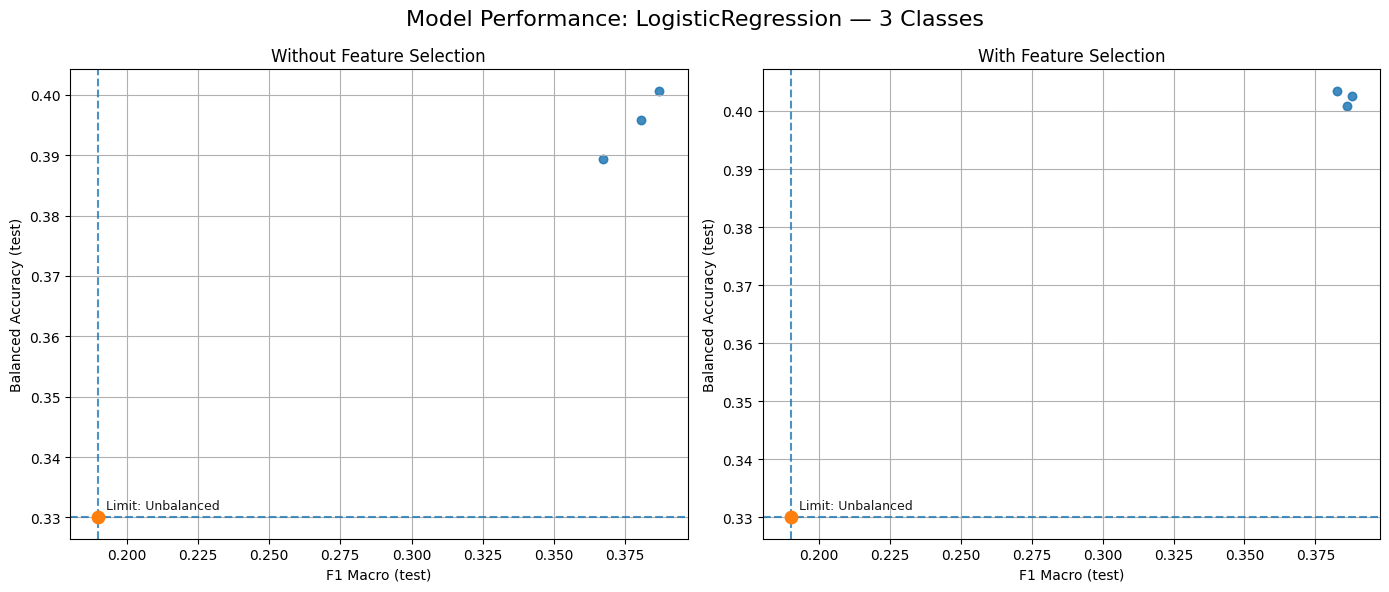

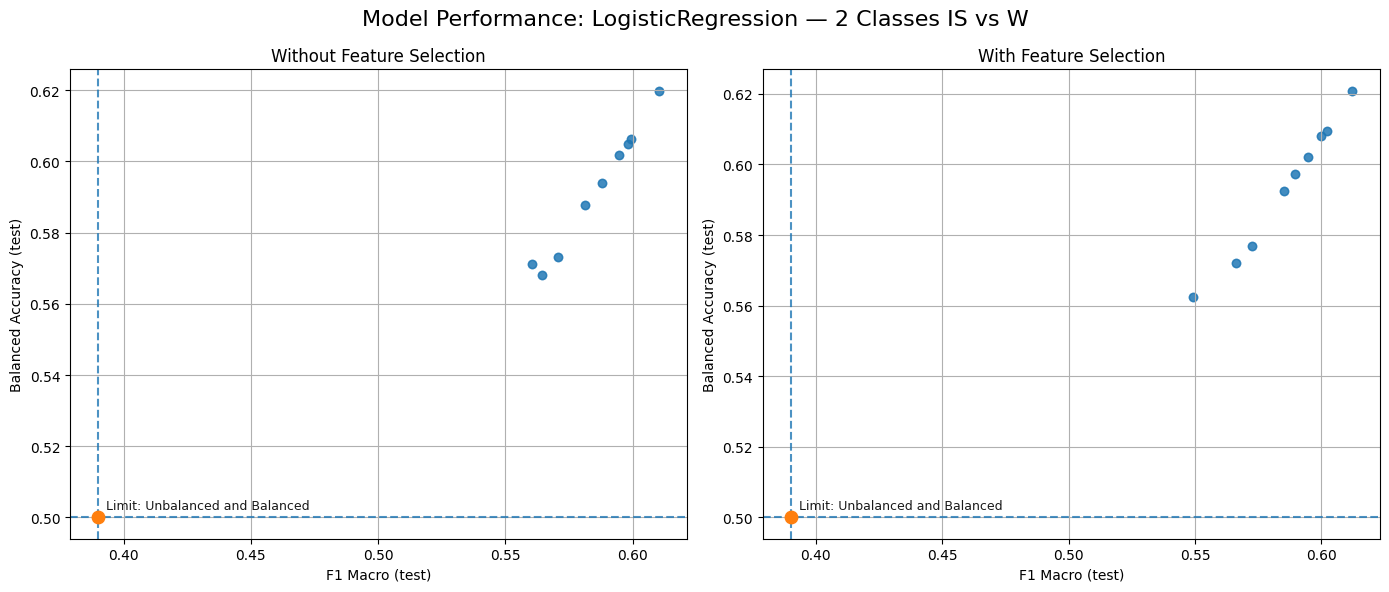

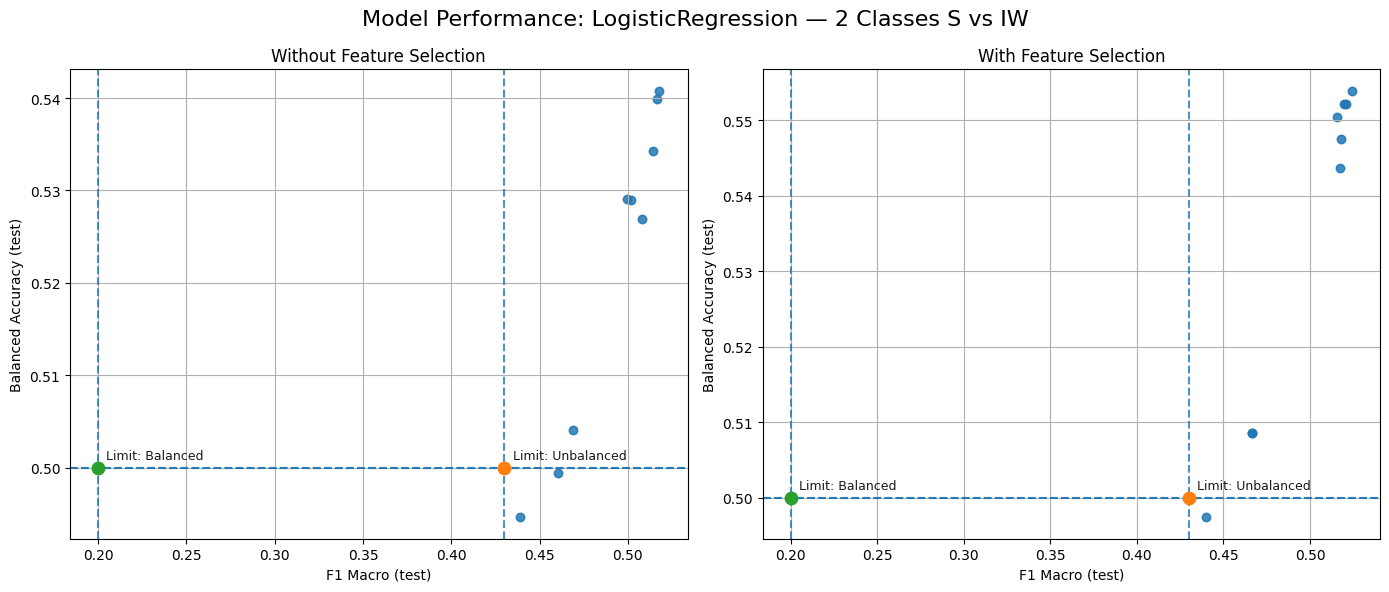

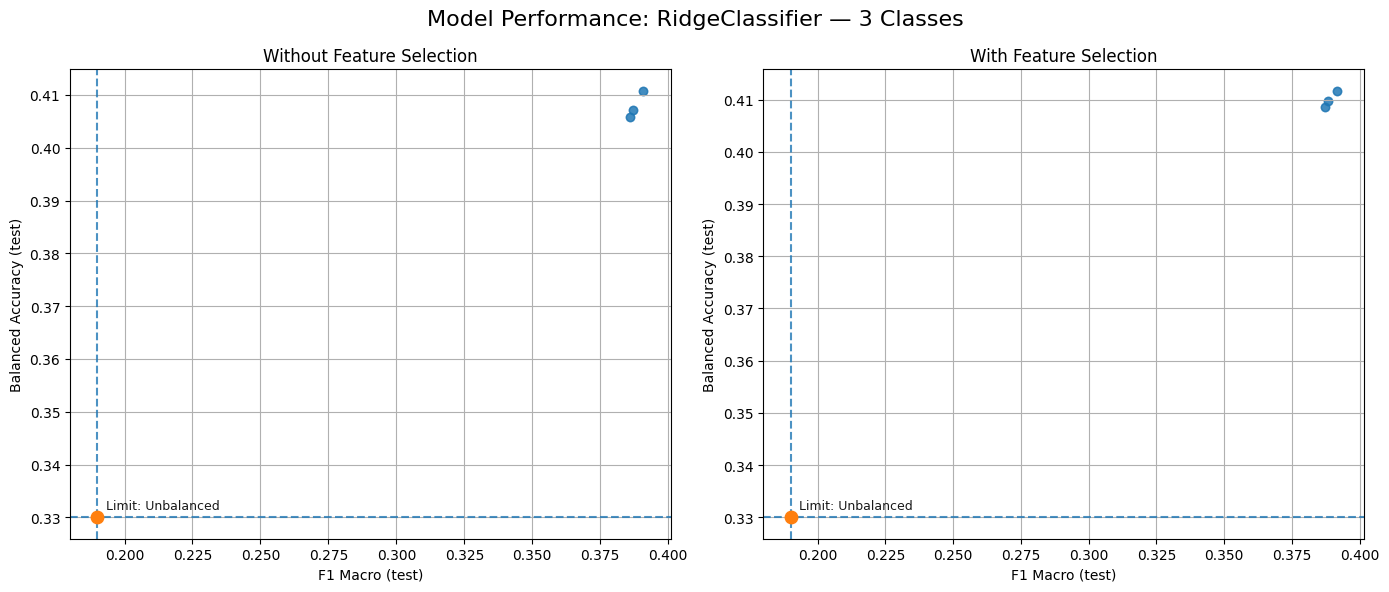

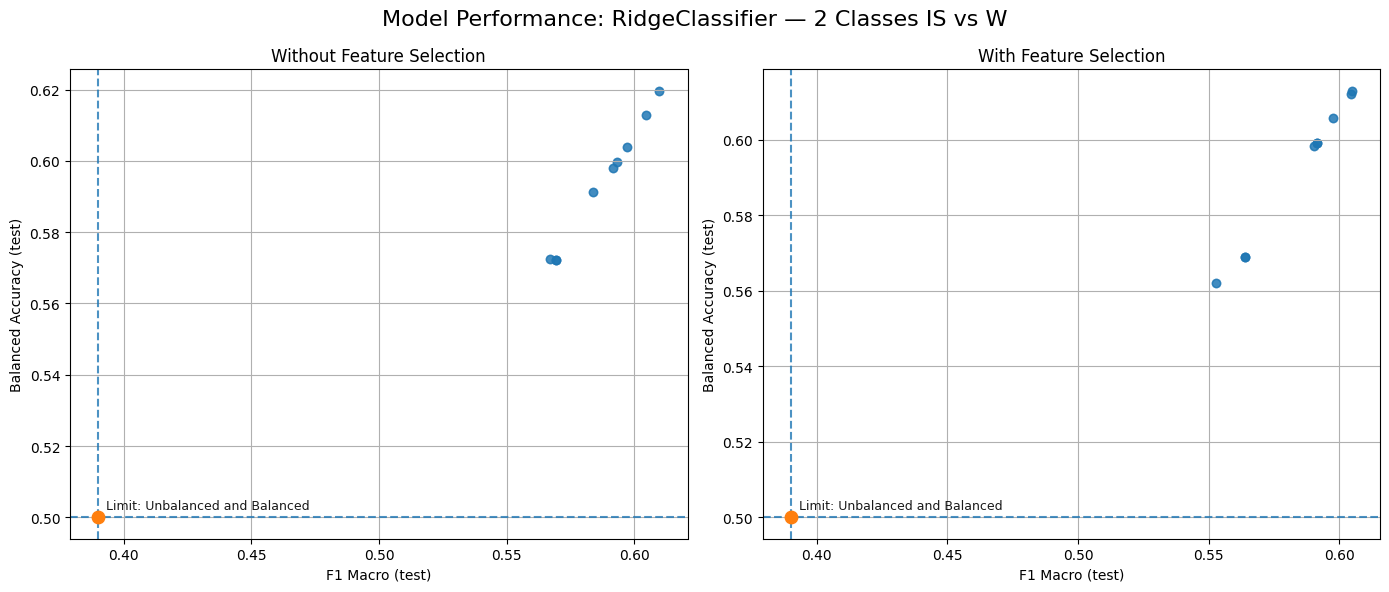

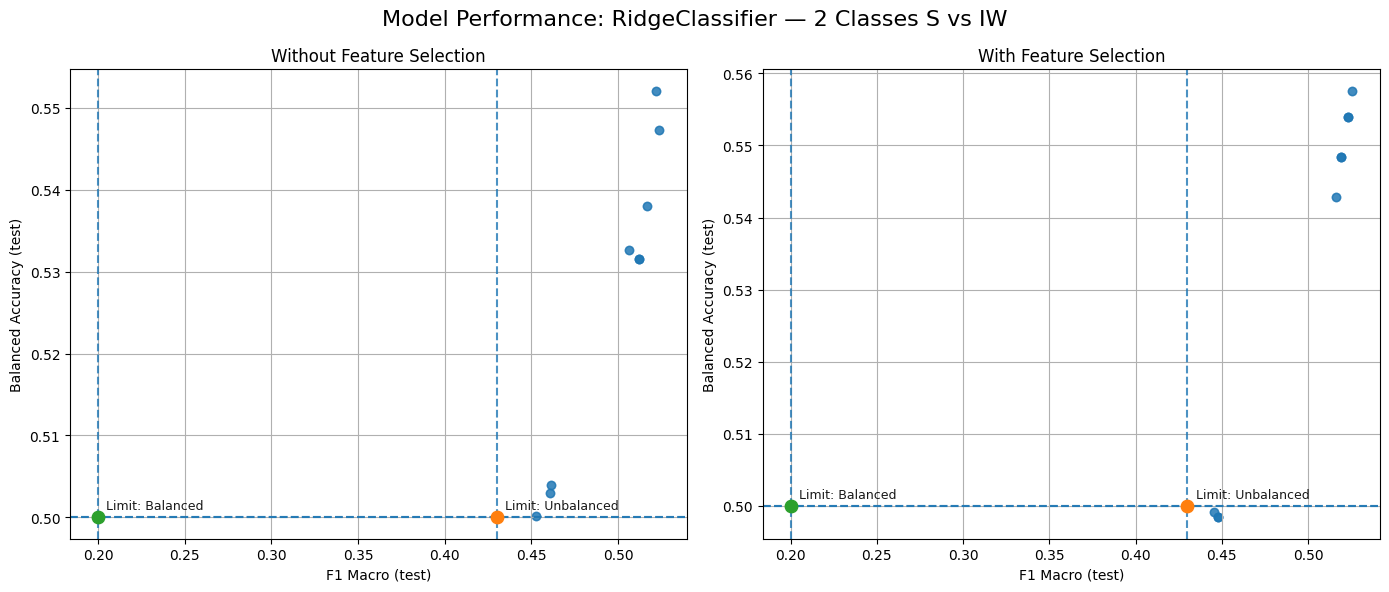

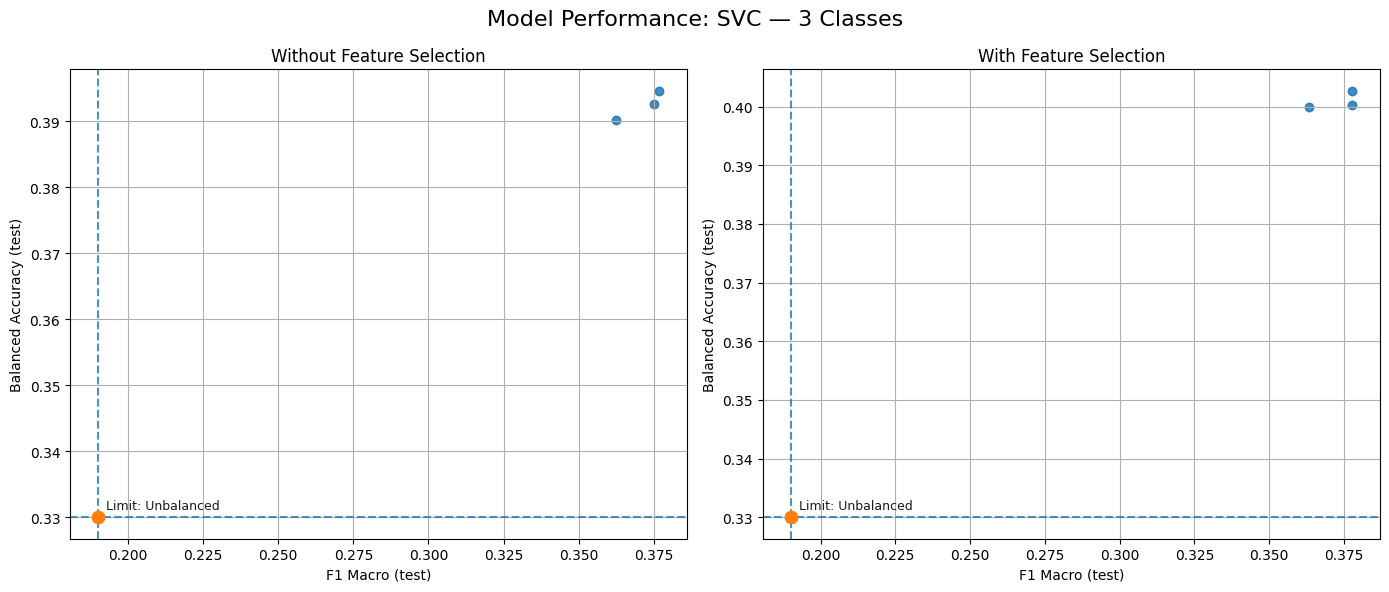

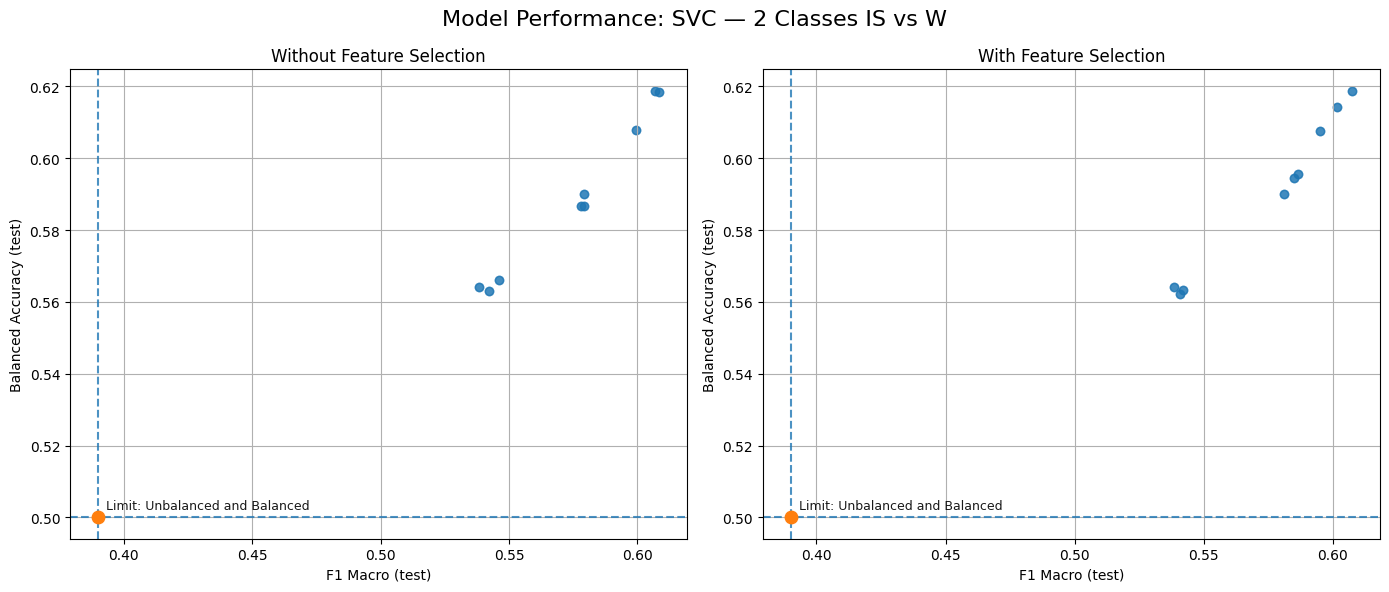

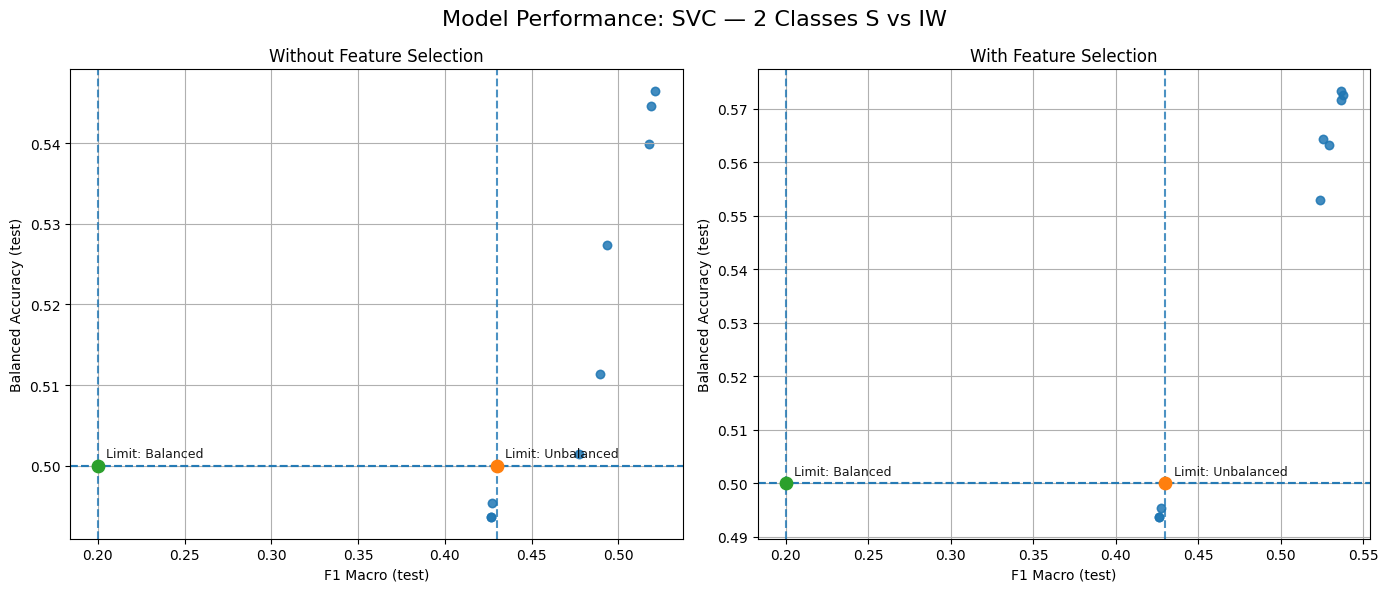

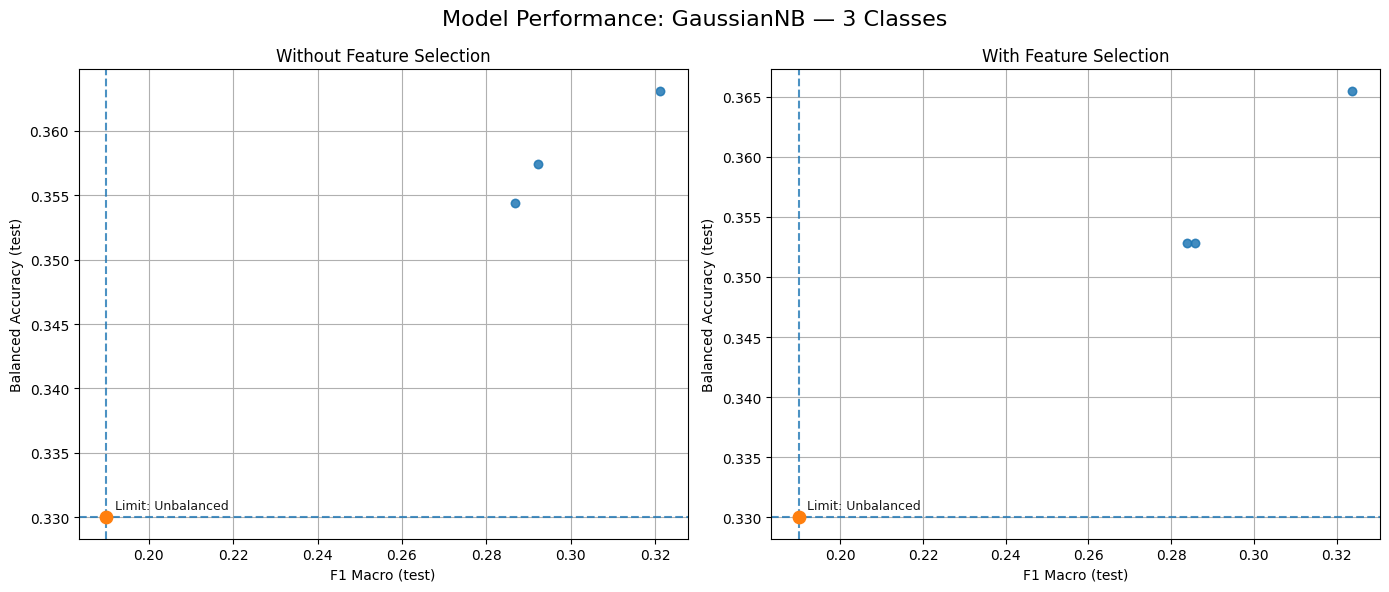

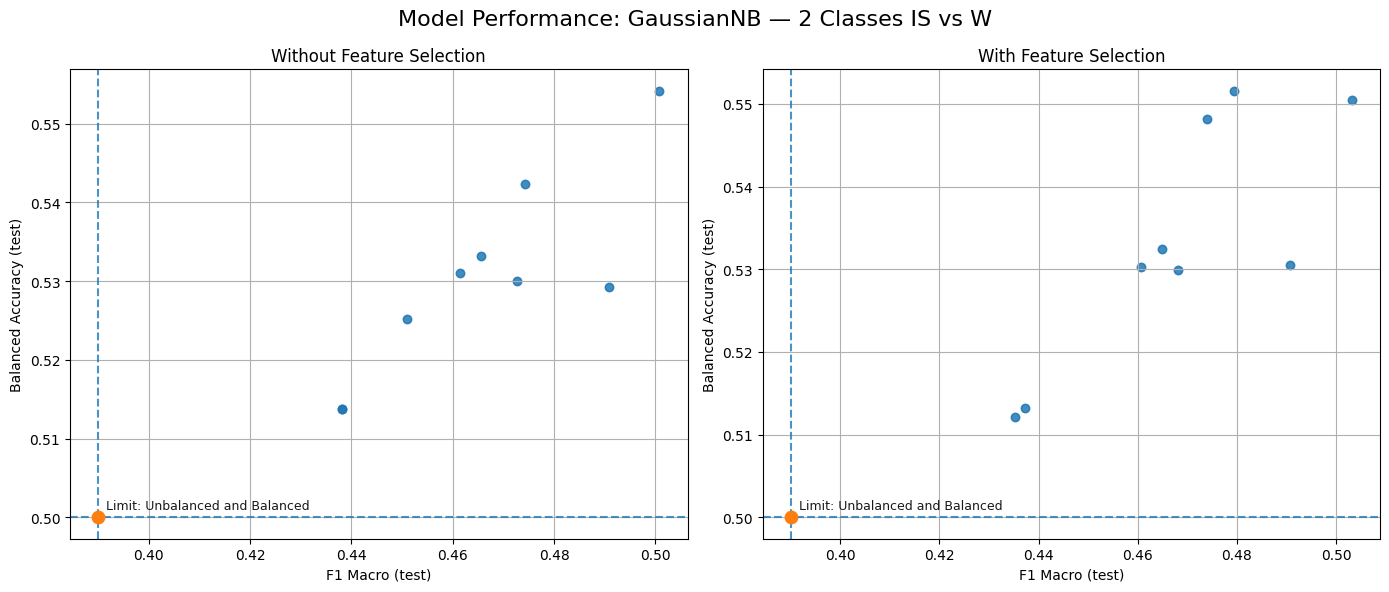

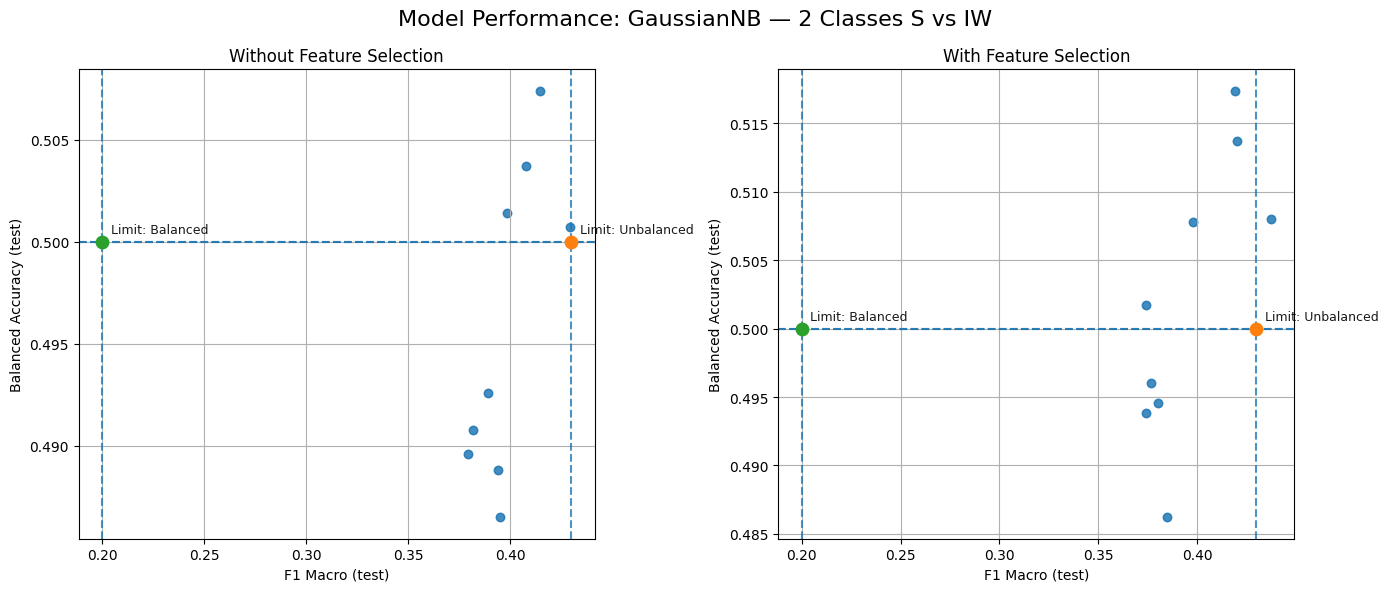

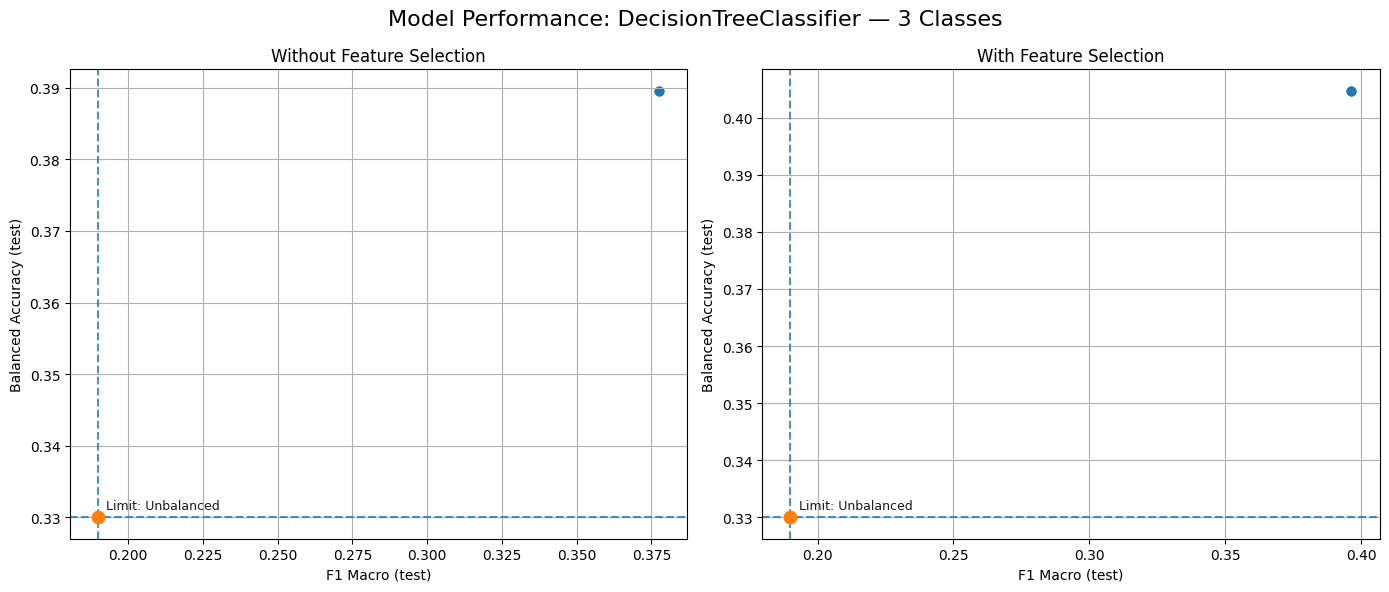

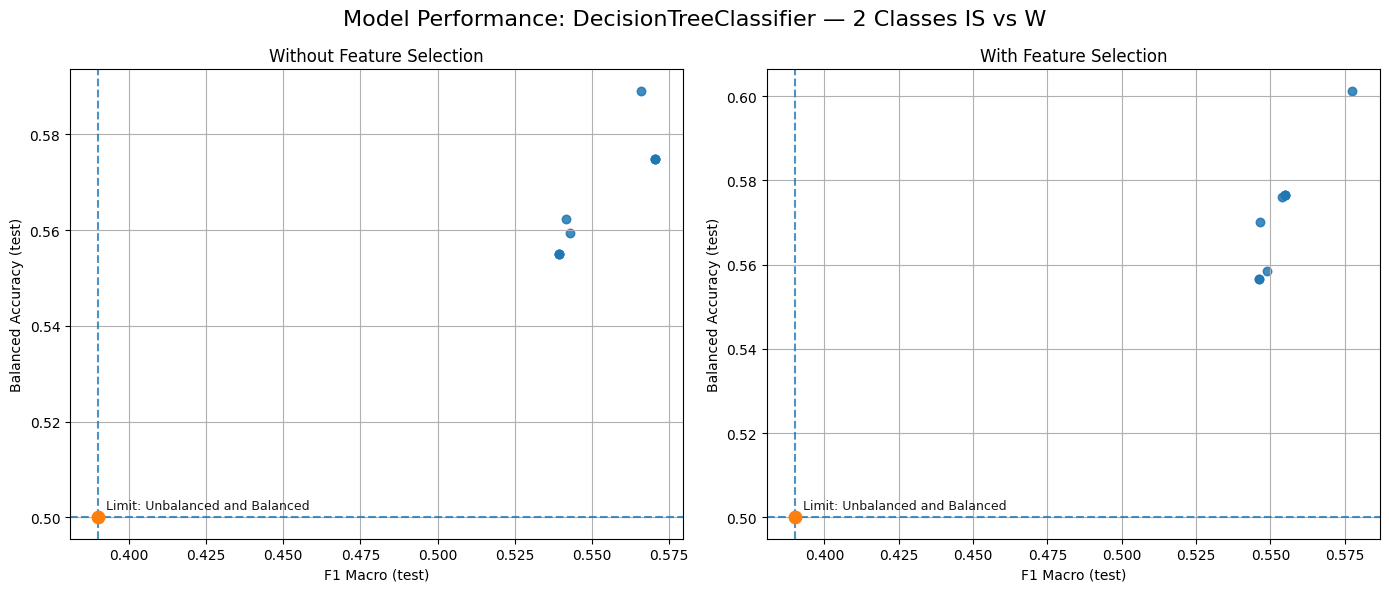

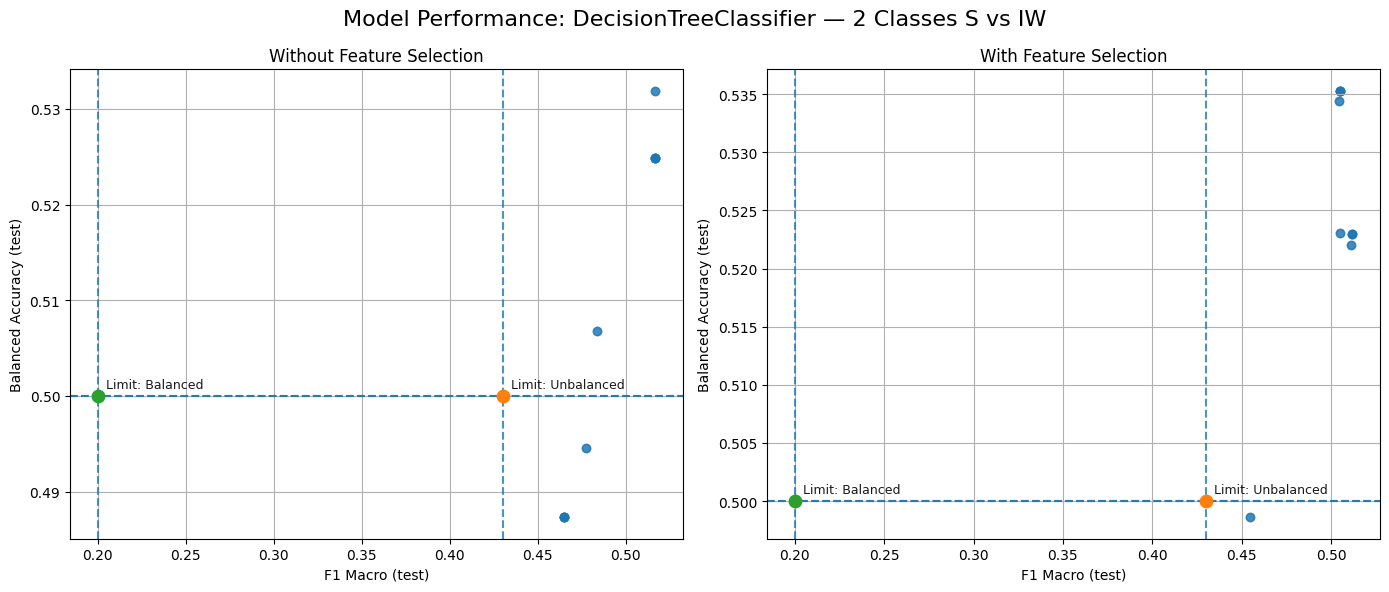

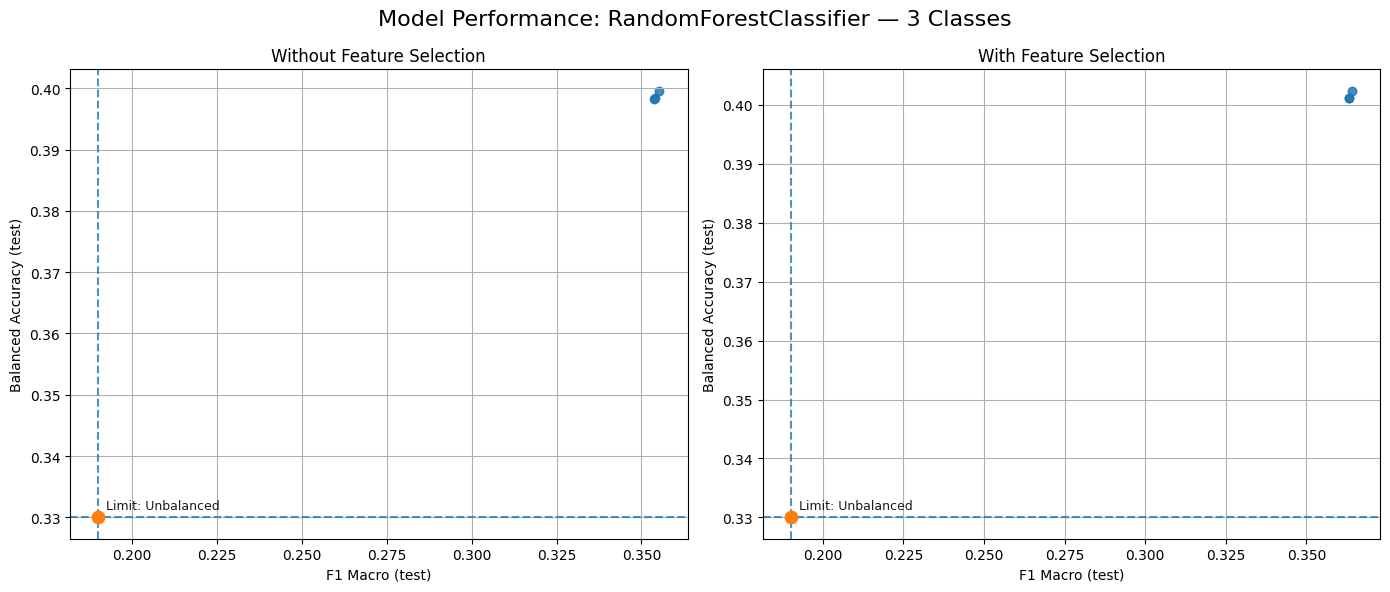

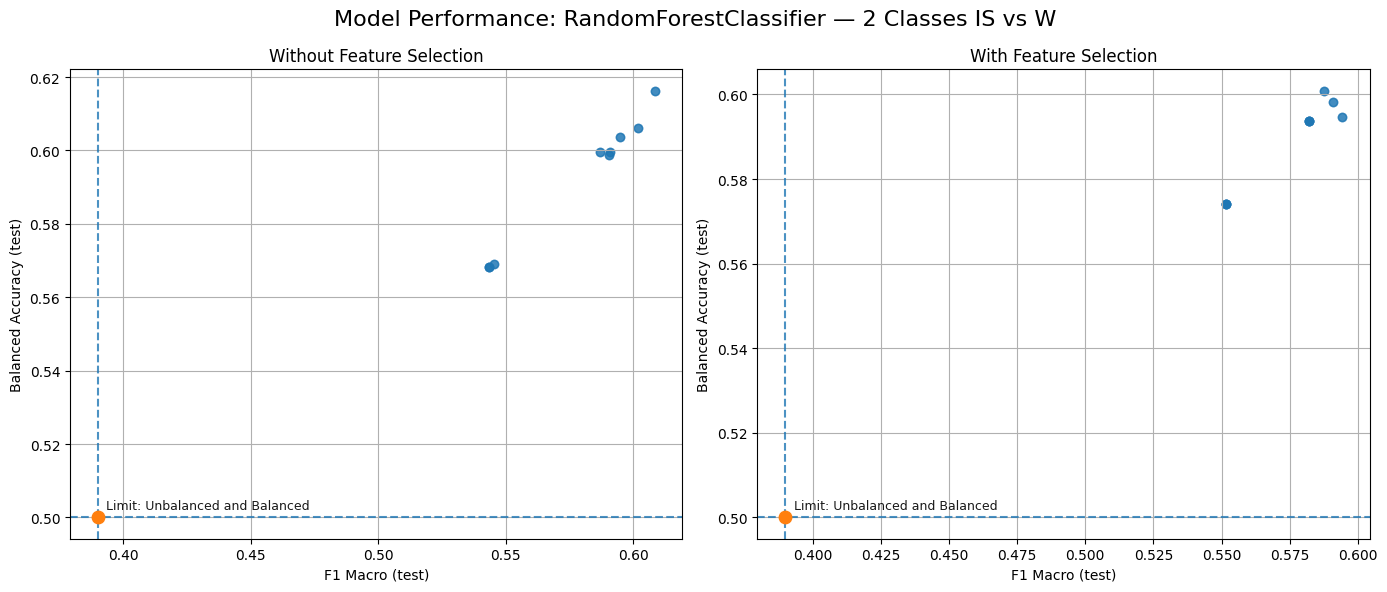

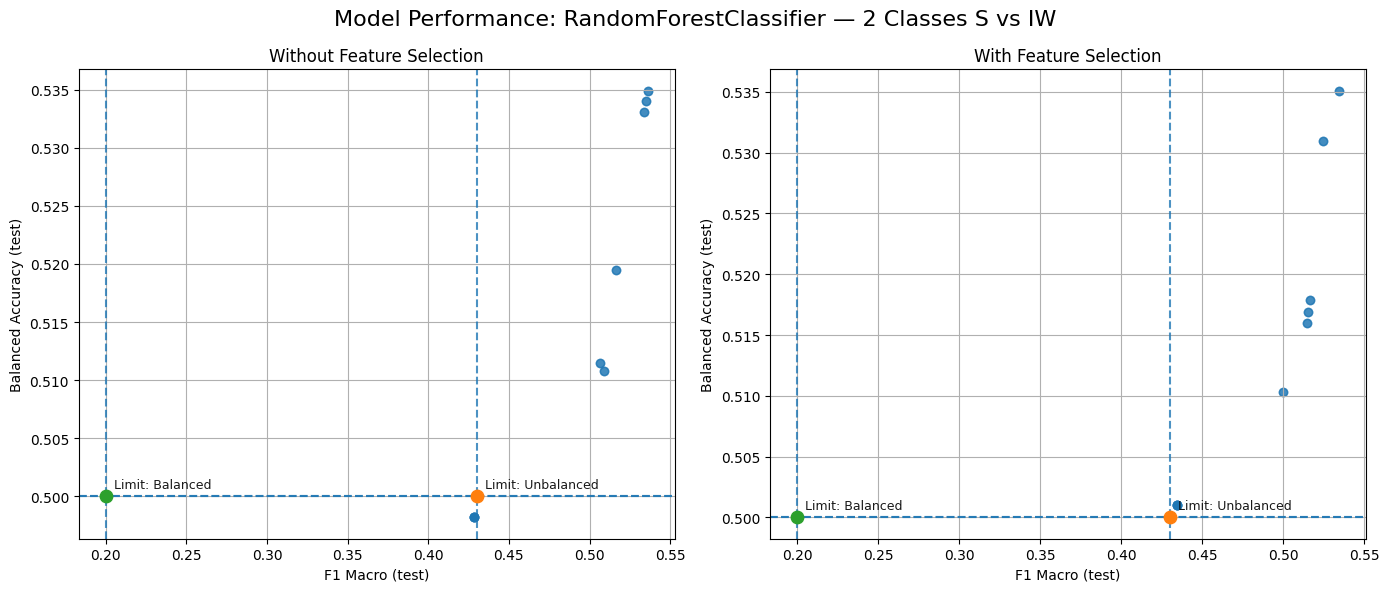

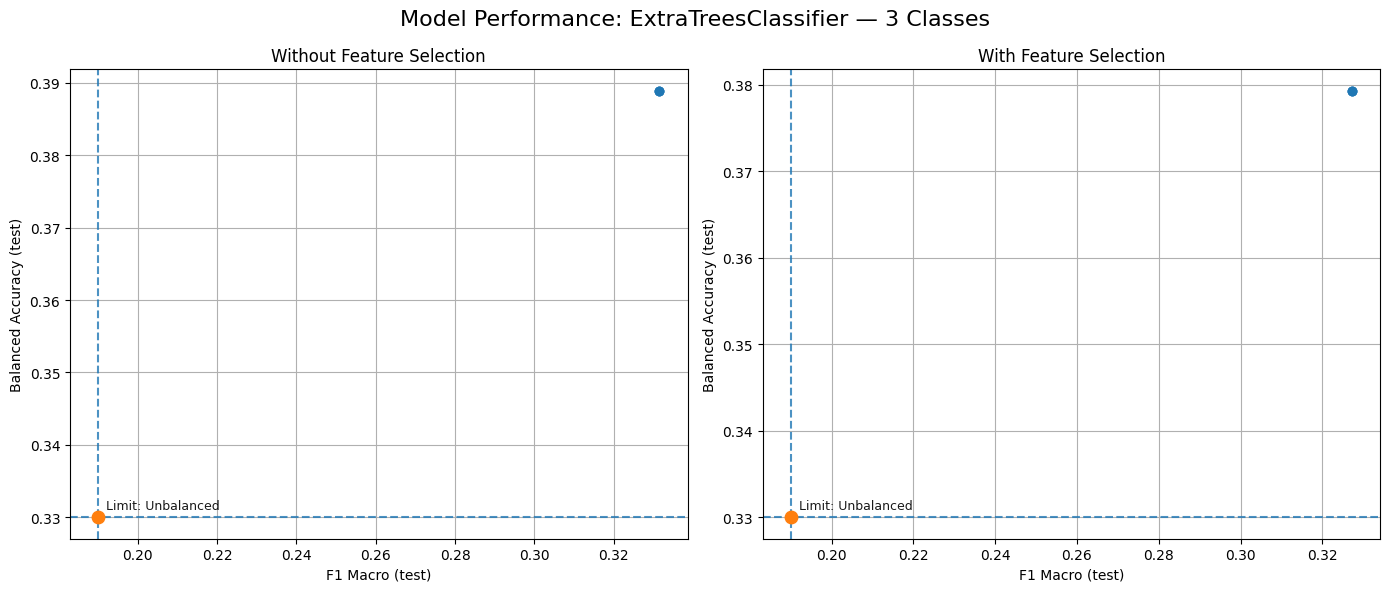

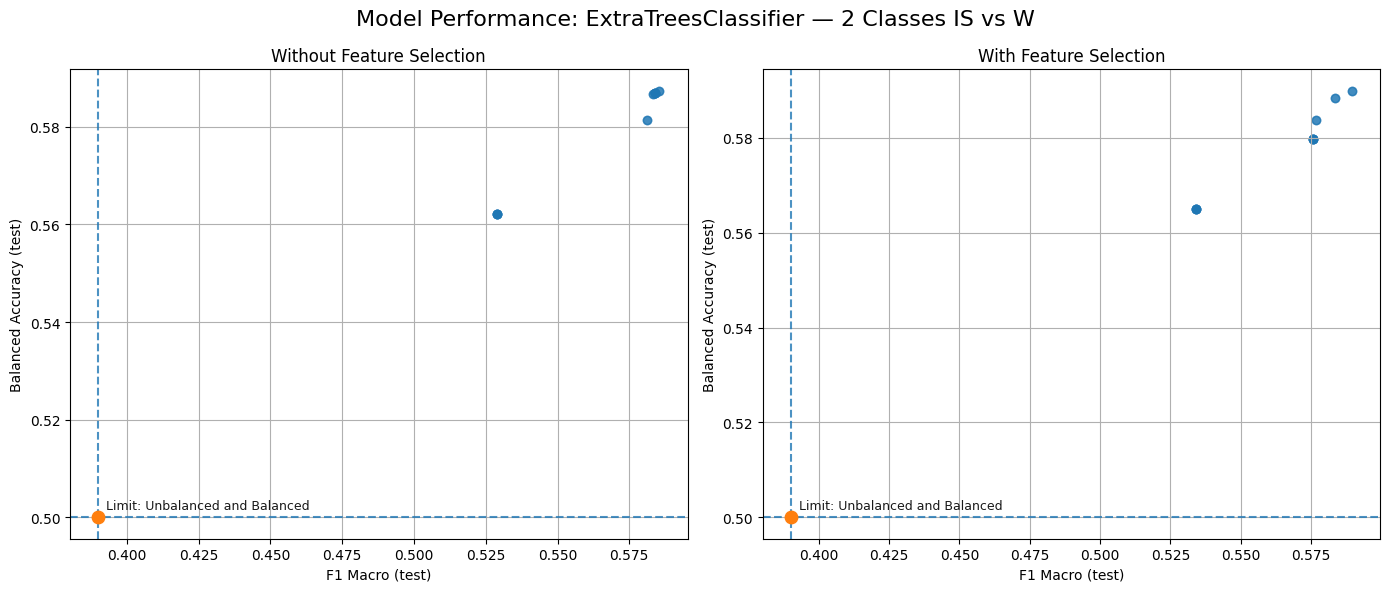

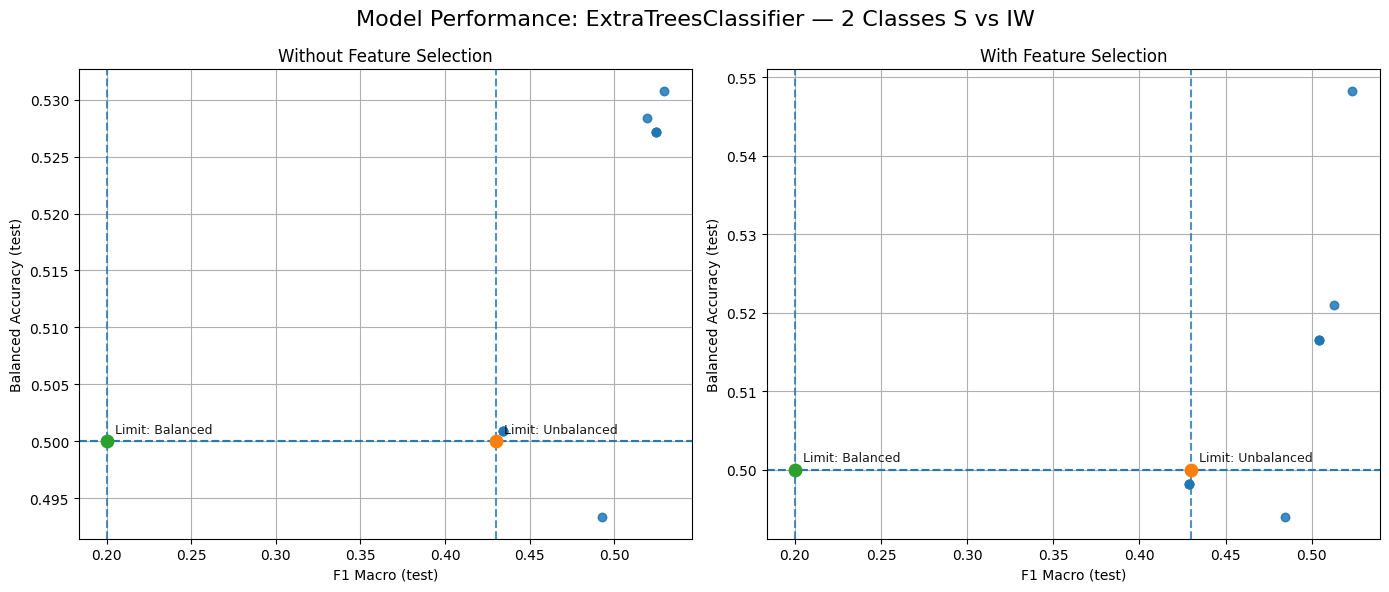

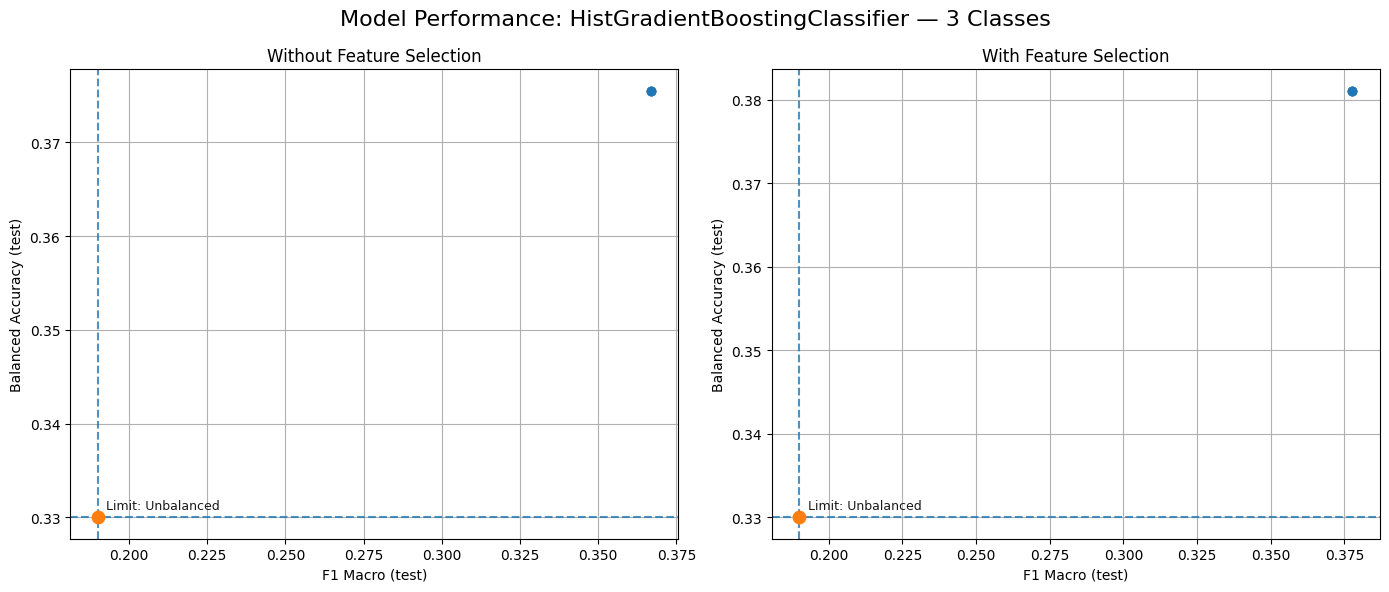

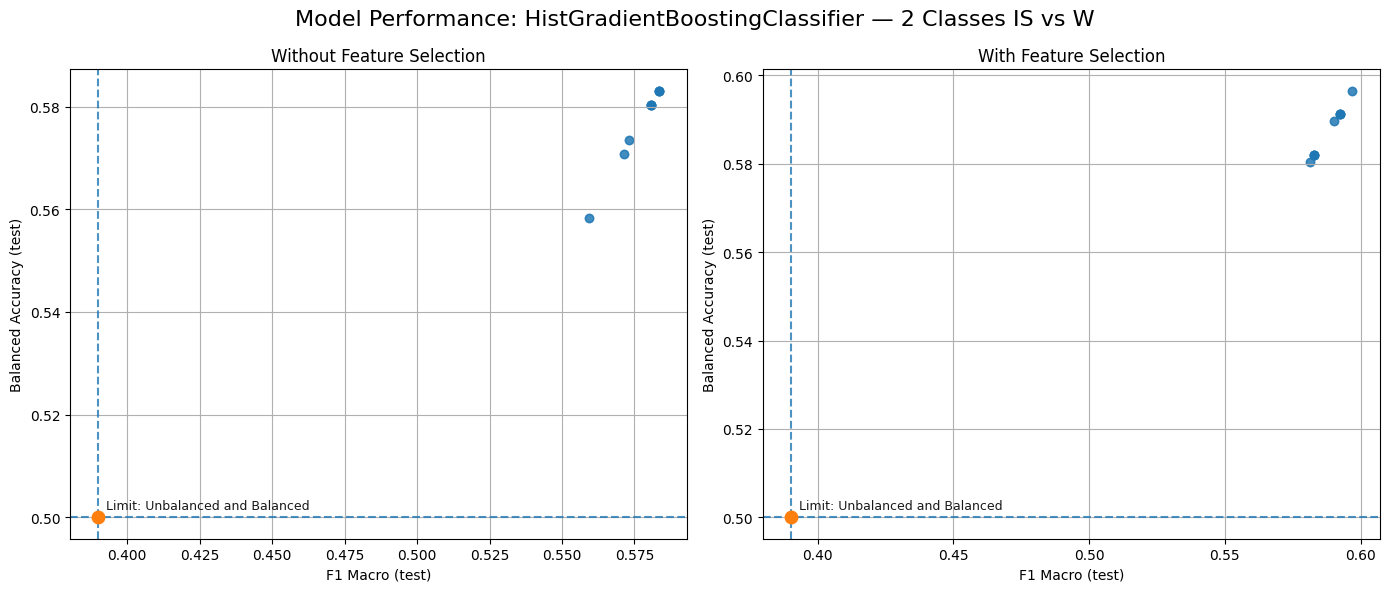

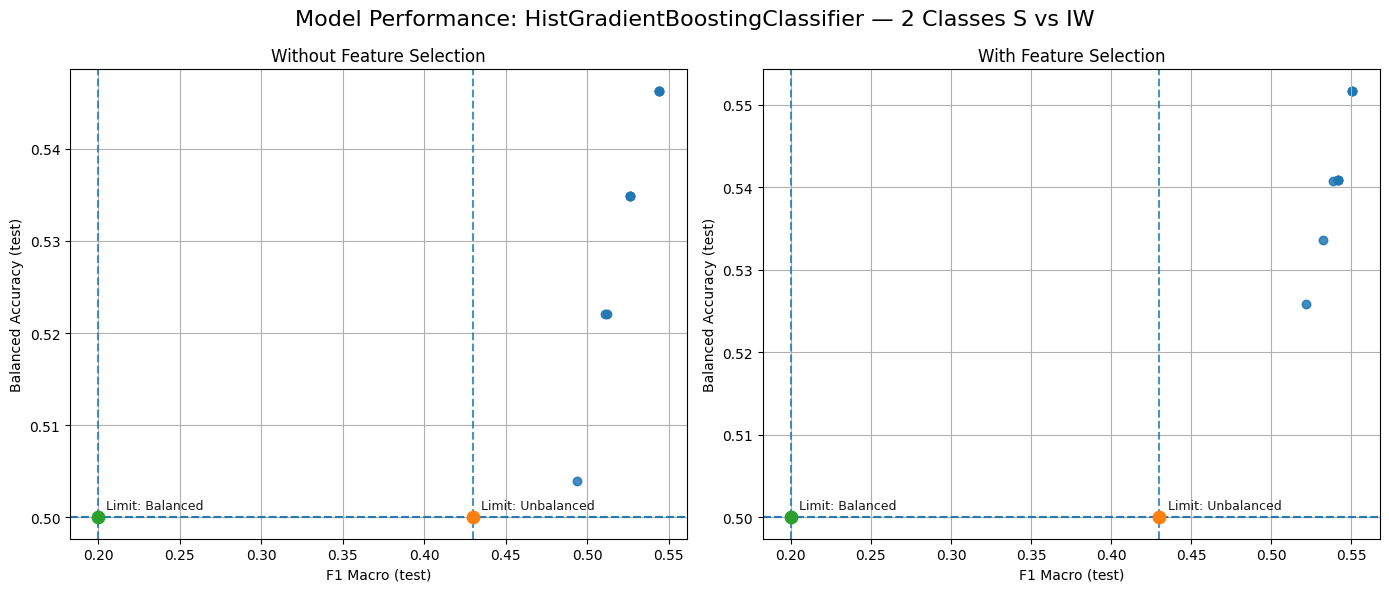

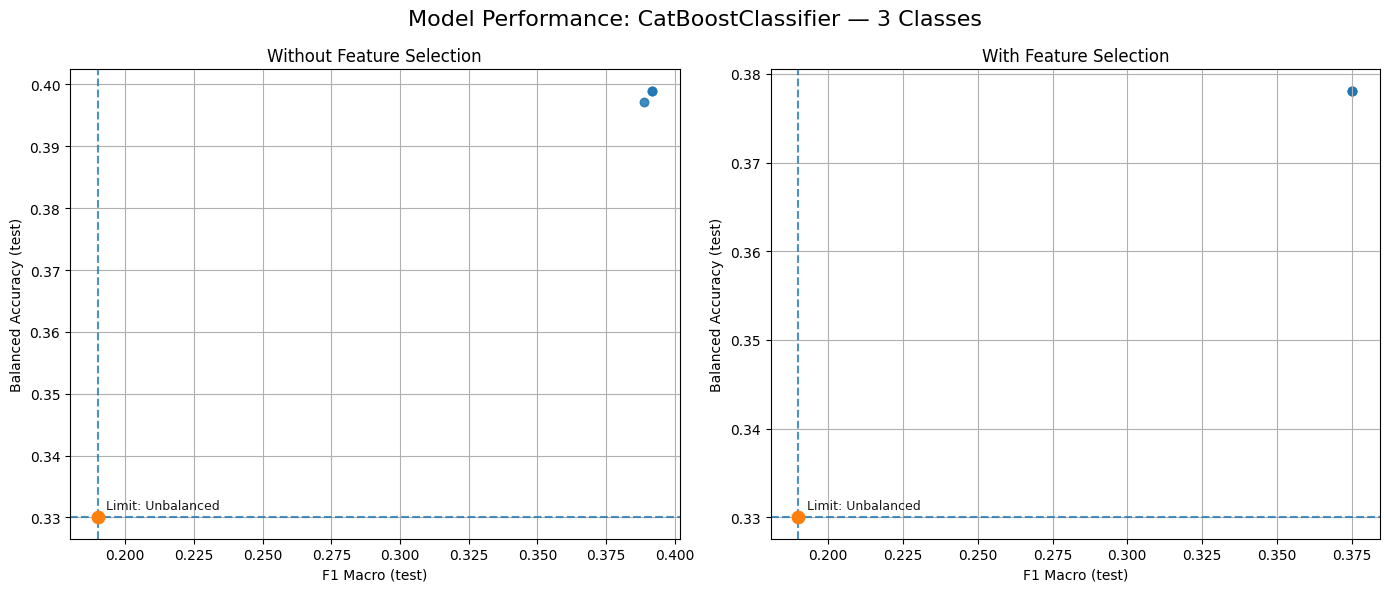

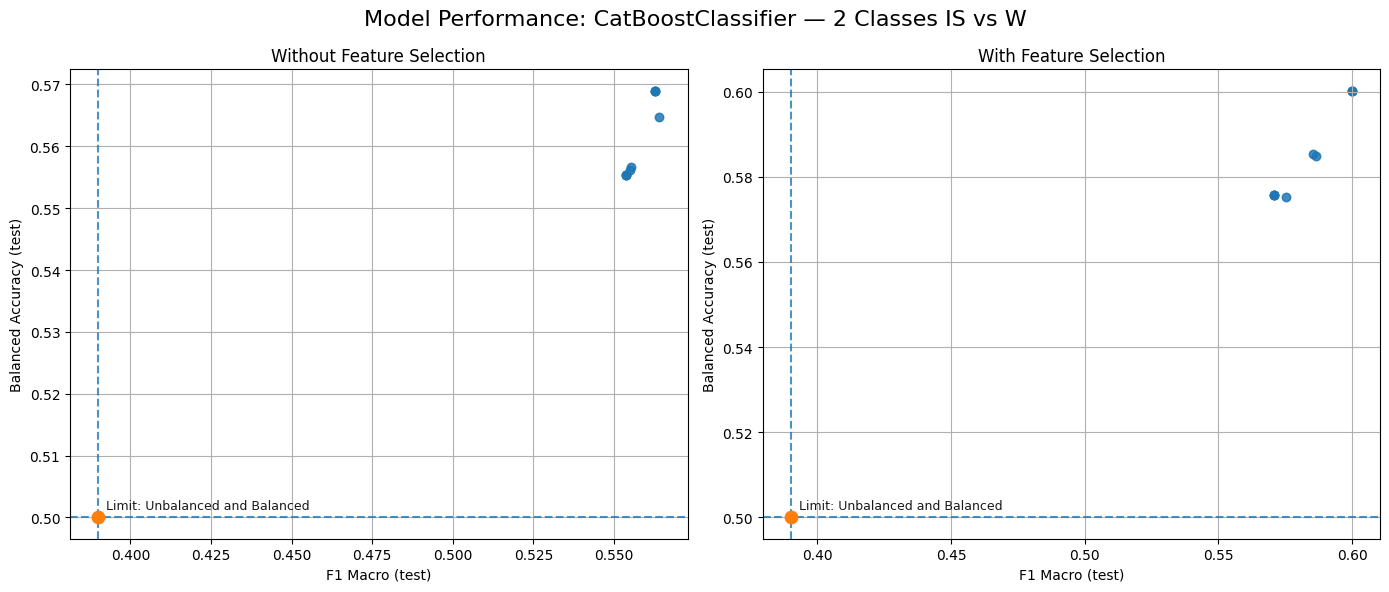

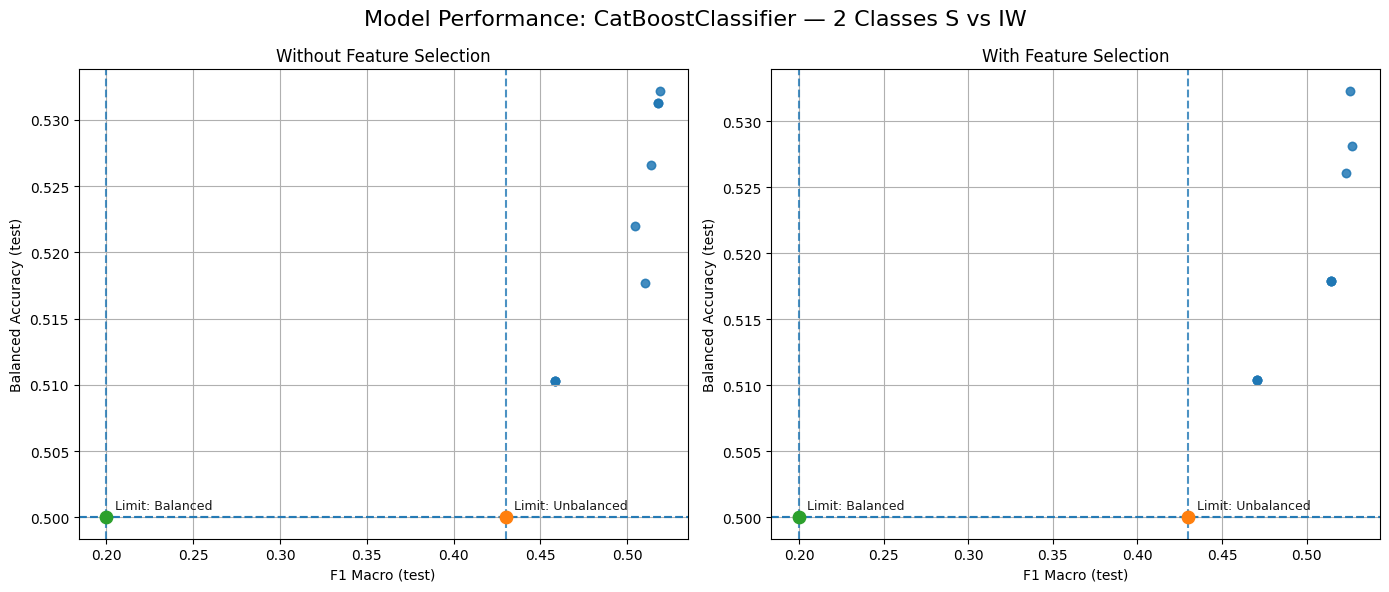

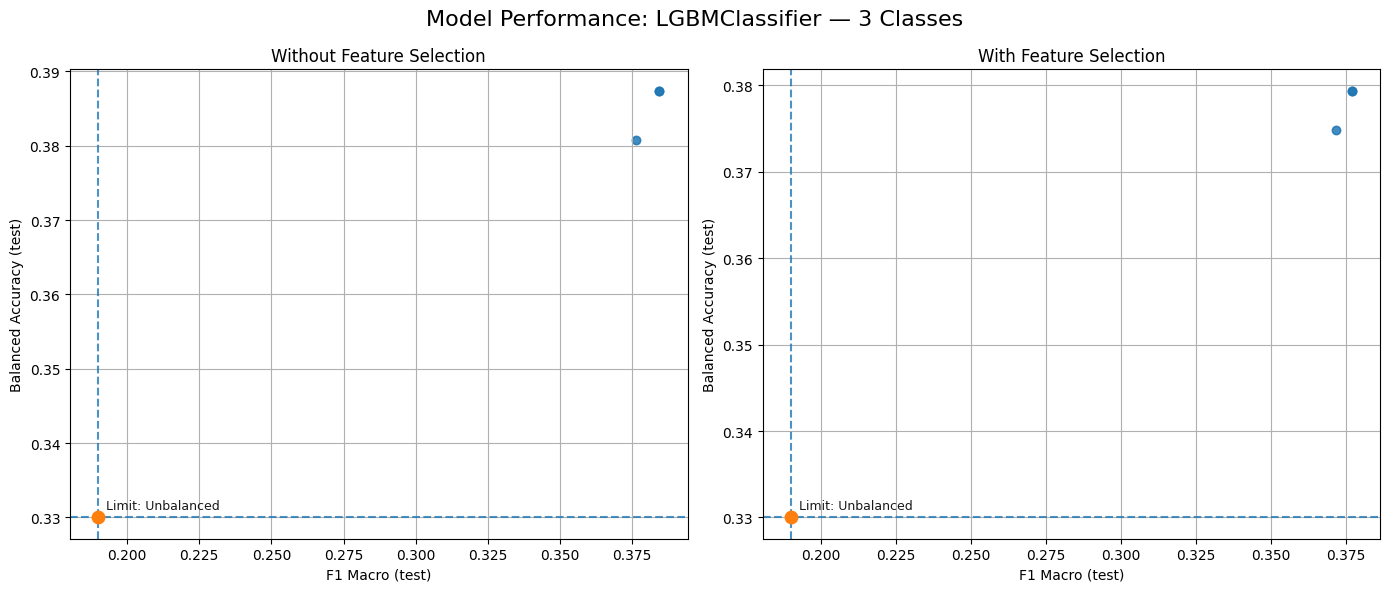

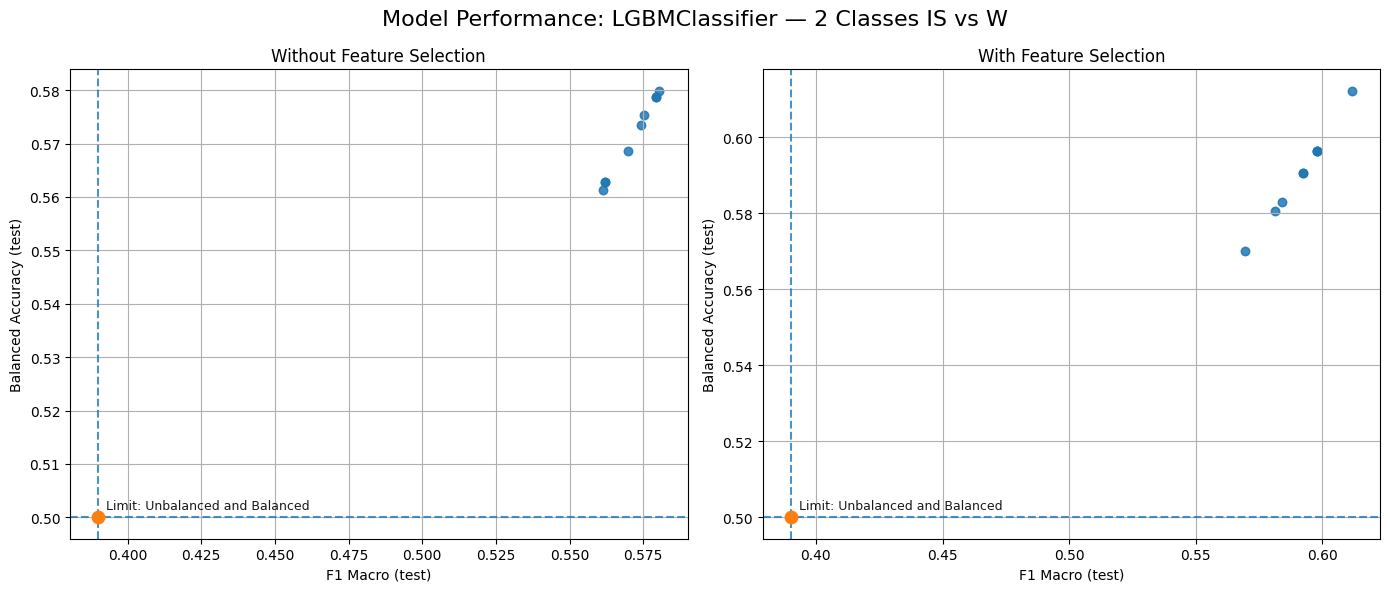

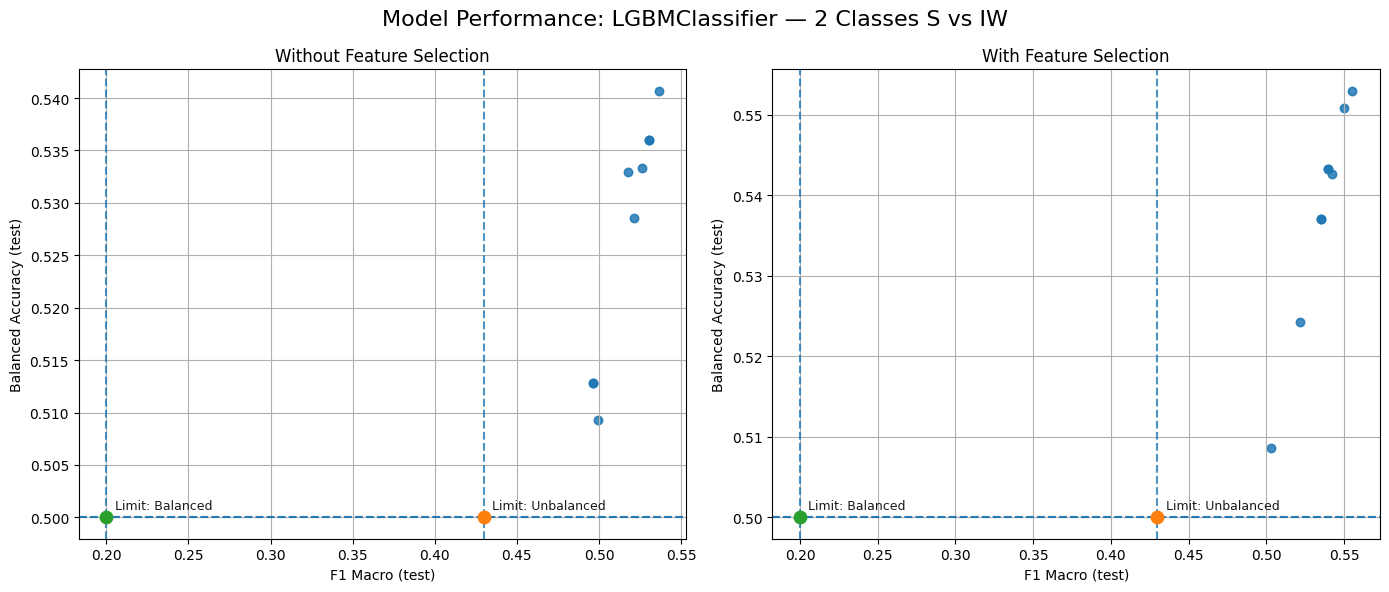

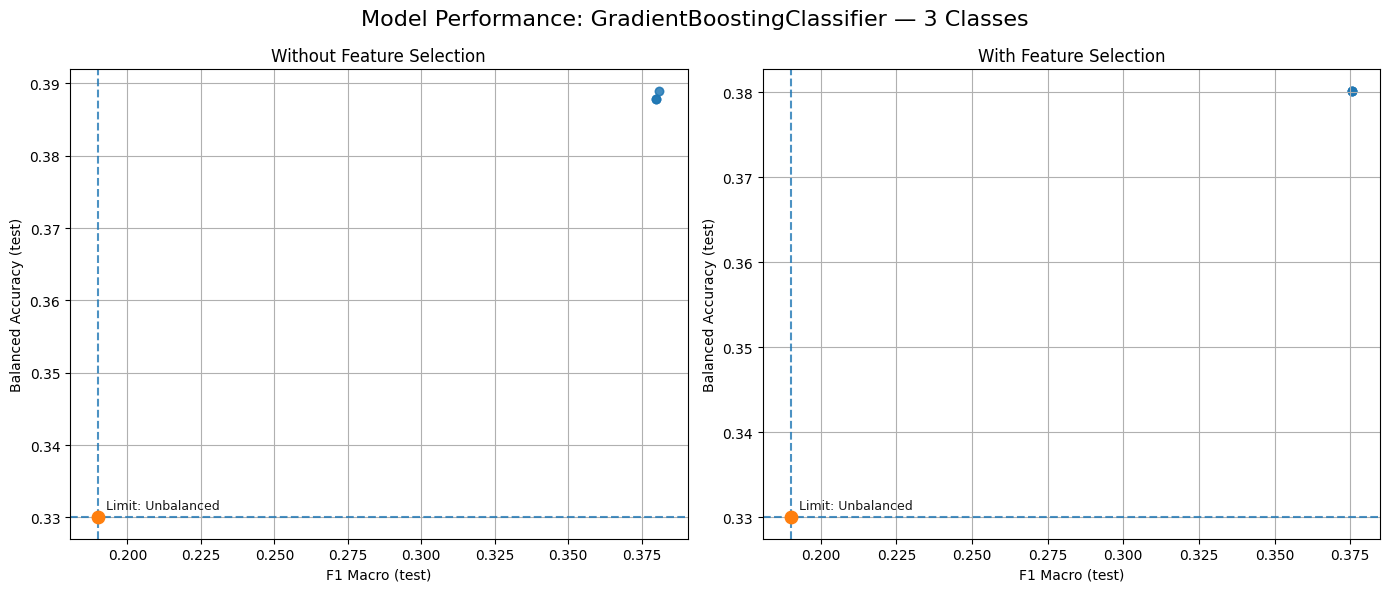

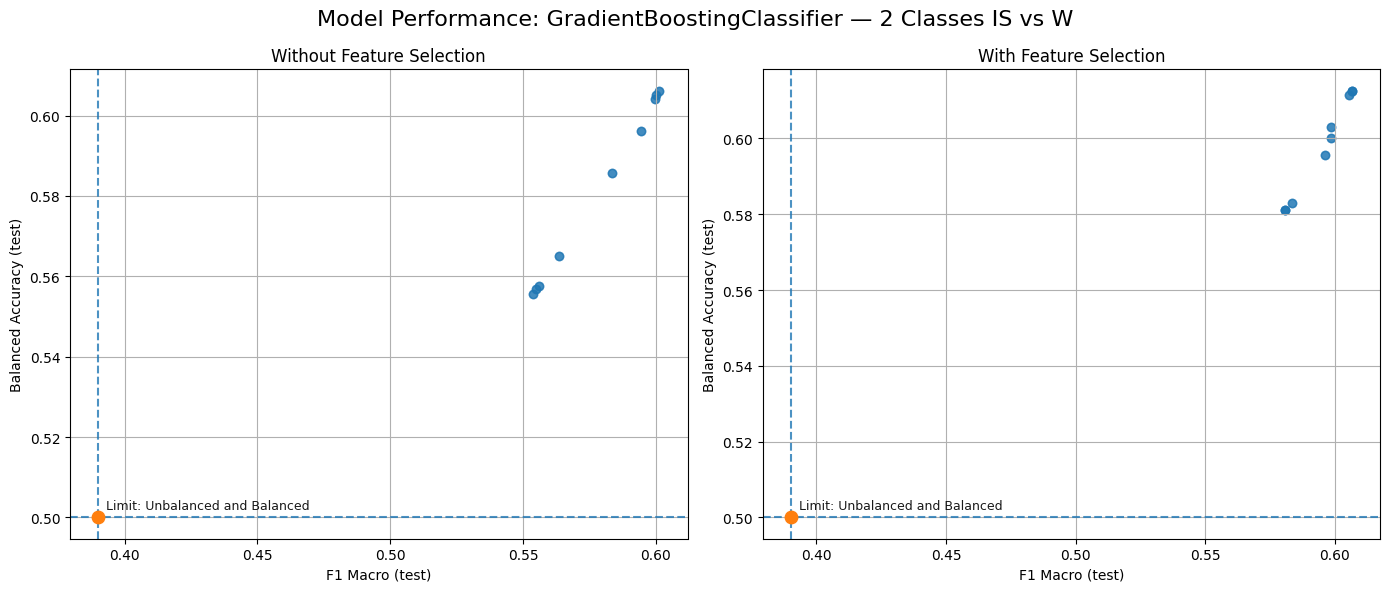

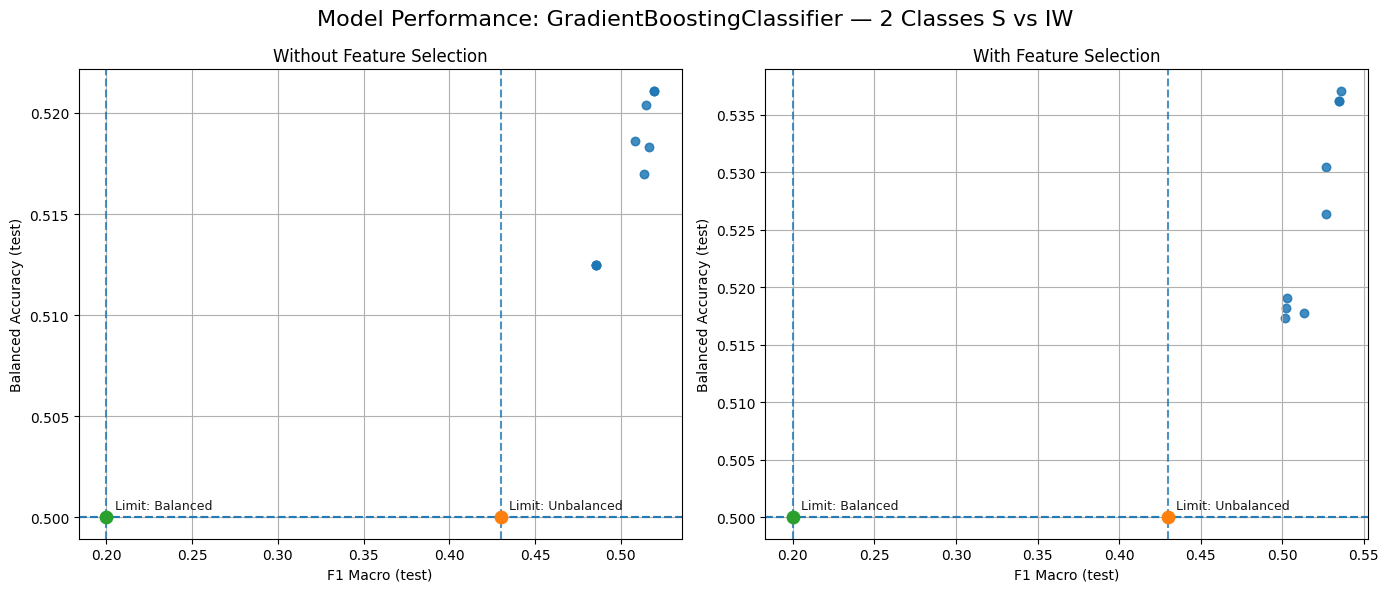

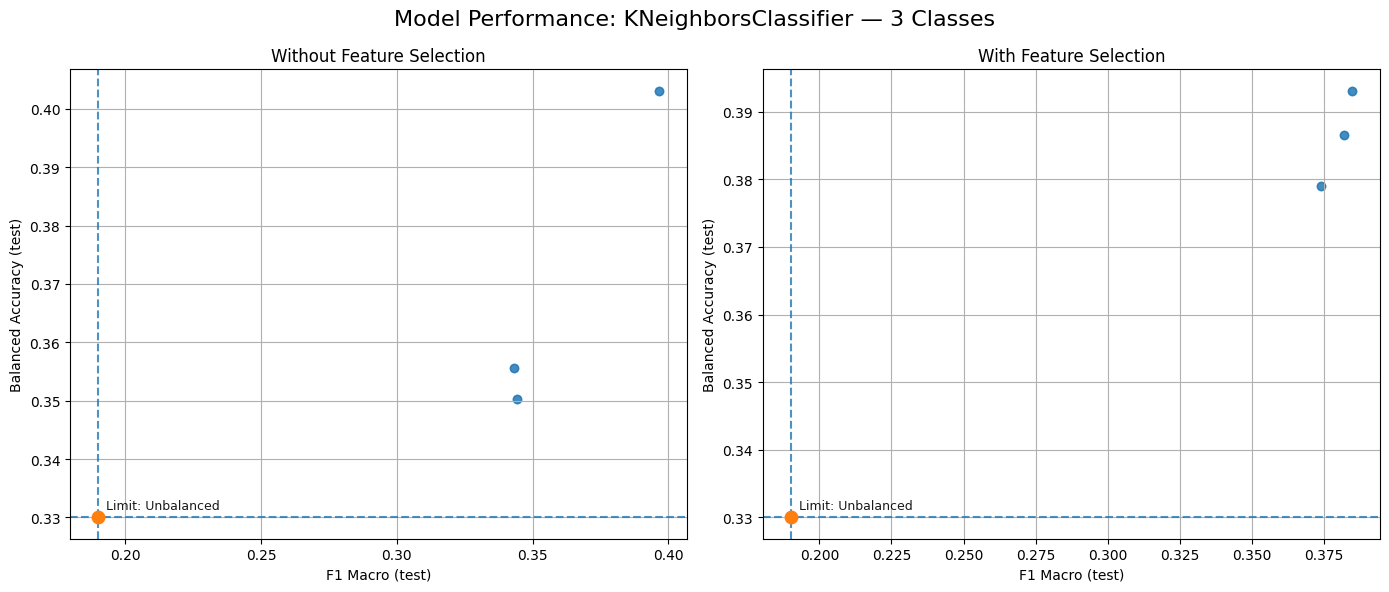

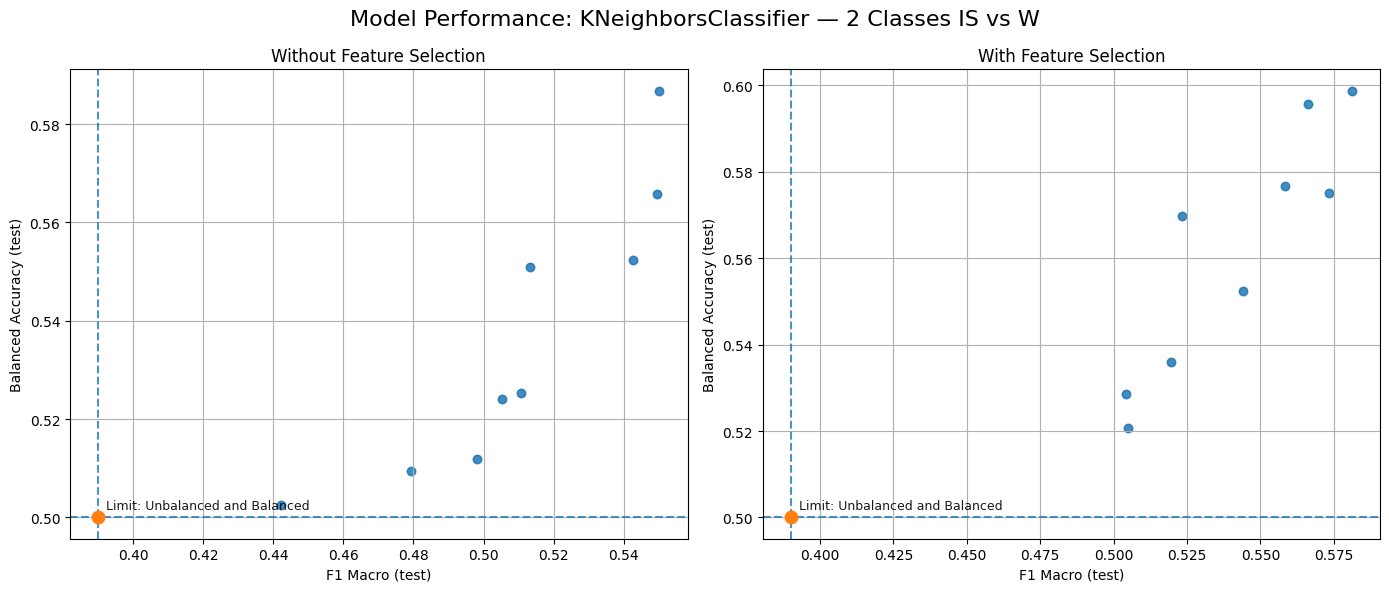

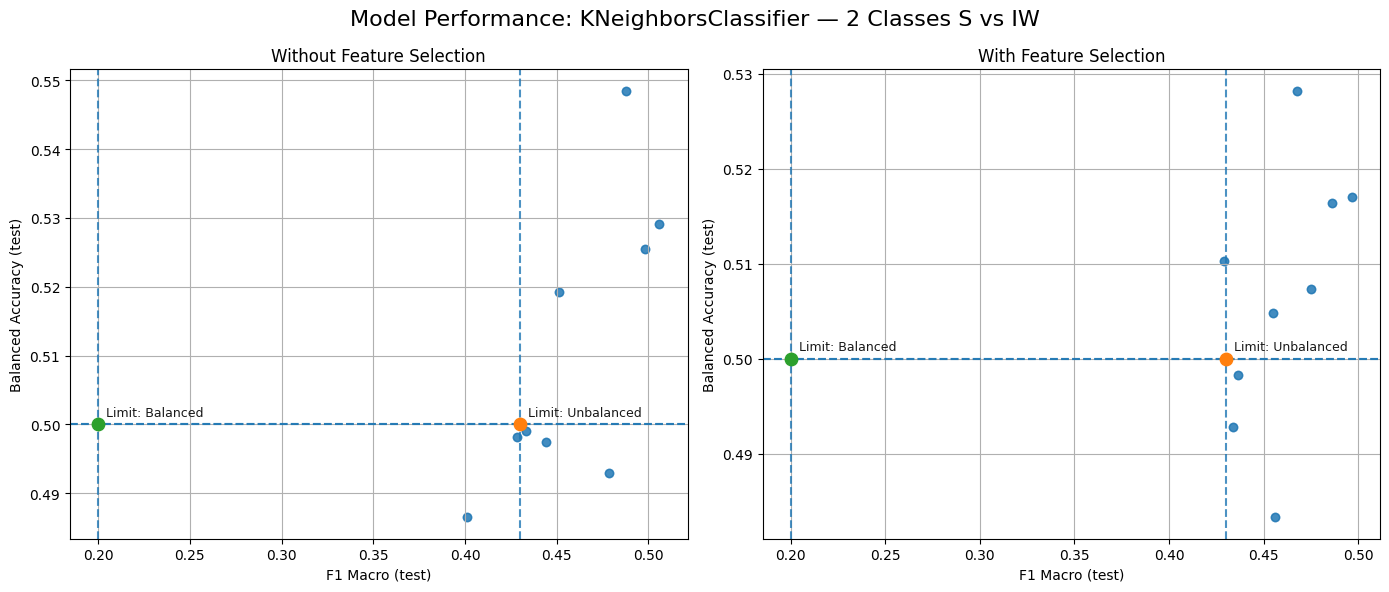

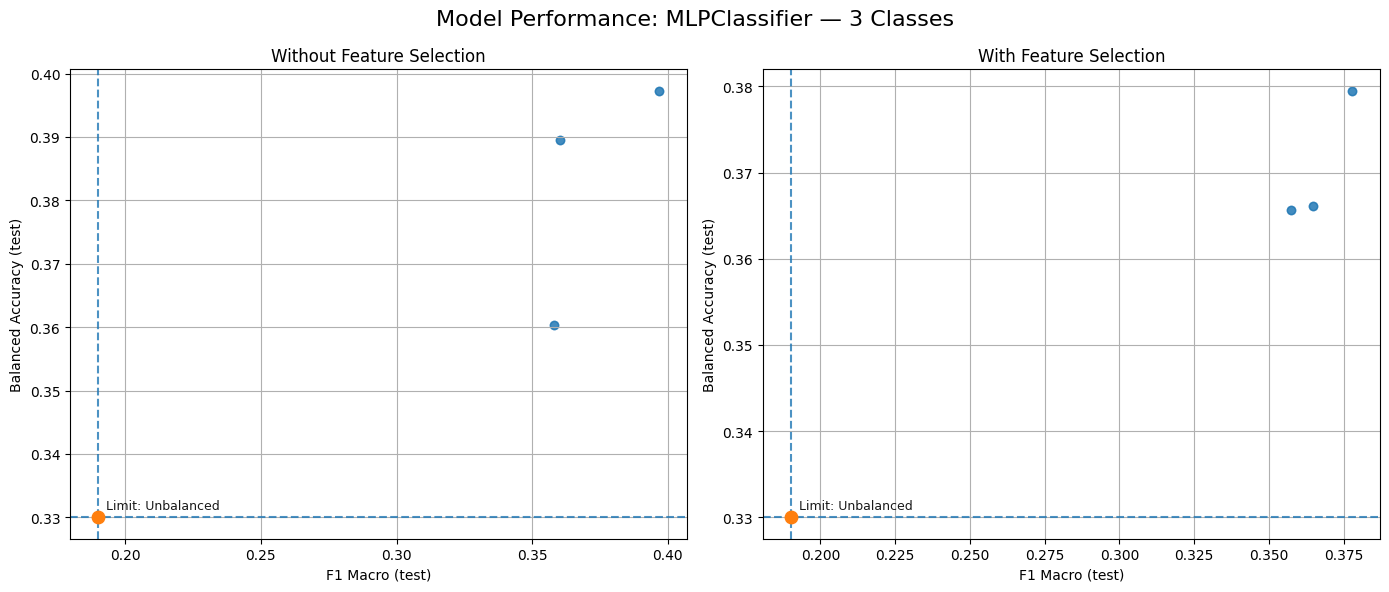

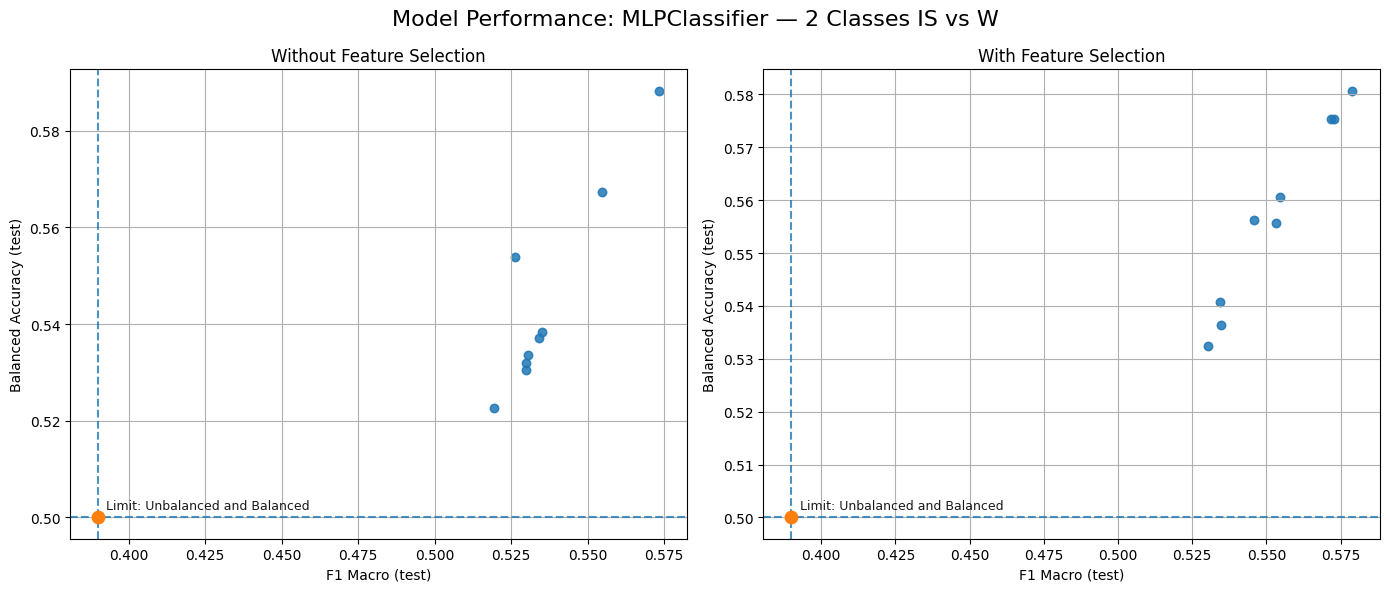

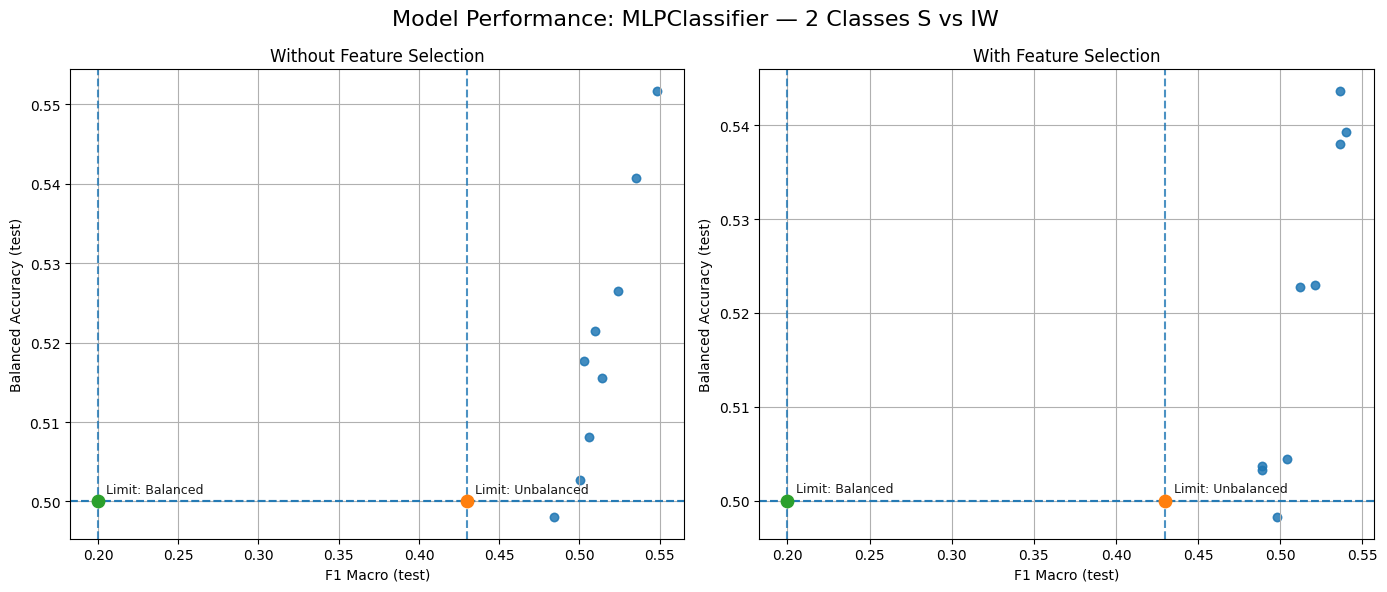

In [14]:
import matplotlib.pyplot as plt

dict_limits = {
    '3 Classes': {
        'Unbalanced': [0.19, 0.33]
    },
    '2 Classes IS vs W': {
        'Unbalanced and Balanced': [ 0.39, 0.5]
    },
    '2 Classes S vs IW': {
        'Unbalanced': [ 0.43, 0.5],
        'Balanced':   [ 0.20, 0.5]
    }
}

def get_limits(type_target: str):

    if type_target == '3 Classes':
        return [(dict_limits[type_target]['Unbalanced'], 'Unbalanced')]

    if type_target == '2 Classes IS vs W':
        label = 'Unbalanced and Balanced'
        return [(dict_limits[type_target][label], label)]

    if type_target == '2 Classes S vs IW':
        return [
            (dict_limits[type_target]['Unbalanced'], 'Unbalanced'),
            (dict_limits[type_target]['Balanced'], 'Balanced')
        ]

    return []


def draw_limits(ax, x_lim: float, y_lim: float, label: str = None):
    ax.axvline(x=x_lim, linestyle='--', alpha=0.8)
    ax.axhline(y=y_lim, linestyle='--', alpha=0.8)
    ax.scatter([x_lim], [y_lim], s=80, zorder=5)
    if label:
        ax.annotate(
            label,
            (x_lim, y_lim),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=9,
            alpha=0.9
        )


# PLOTS
models_tested = models_performance['Model'].unique().tolist()
targets = ['3 Classes', '2 Classes IS vs W', '2 Classes S vs IW']

for model in models_tested:
    for type_target in targets:

        # --- SIN Feature Selection ---
        df_selected_all_vars = models_performance.loc[
            (models_performance['Model'] == model) &
            (models_performance['Parameters'].str.contains(type_target, na=False)) &
            (~models_performance['Parameters'].str.contains('Feature Selection', na=False)),
            ['Parameters', 'test_bal_acc', 'test_f1_macro']
        ].copy()

        # --- CON Feature Selection ---
        df_selected_FS = models_performance.loc[
            (models_performance['Model'] == model) &
            (models_performance['Parameters'].str.contains(type_target, na=False)) &
            (models_performance['Parameters'].str.contains('Feature Selection', na=False)),
            ['Parameters', 'test_bal_acc', 'test_f1_macro']
        ].copy()

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        for ax, df, title in zip(
            axes,
            [df_selected_all_vars, df_selected_FS],
            ["Without Feature Selection", "With Feature Selection"]
        ):
            # Scatter
            if not df.empty:
                ax.scatter(df["test_f1_macro"], df["test_bal_acc"], alpha=0.6)

            ax.set_title(title)
            ax.set_xlabel("F1 Macro (test)")
            ax.set_ylabel("Balanced Accuracy (test)")
            ax.grid(True)

            # Dibujar límites (siempre, no depende del DF)
            for limits, balance_label in get_limits(type_target):
                if limits:
                    draw_limits(ax, limits[0], limits[1], label=f"Limit: {balance_label}")

        plt.suptitle(f"Model Performance: {model} — {type_target}", fontsize=16)
        plt.tight_layout()
        plt.show()


## 2. Scatterplot: Δ F1_macro vs Δ Accuracy_balanced (Test)

In [15]:
models_performance.head()
dict_limits = {
    '3 Classes': {
        'Unbalanced': [0.19, 0.33]
    },
    '2 Classes IS vs W': {
        'Unbalanced and Balanced': [ 0.39, 0.5]
    },
    '2 Classes S vs IW': {
        'Unbalanced': [ 0.43, 0.5],
        'Balanced':   [ 0.20, 0.5]
    }
}


def compute_gain(row, metric):
    p = row['Parameters']

    if metric == 'F1 Gain':
        if '3 Classes' in p:
            return row['test_f1_macro'] - 0.19

        elif '2 Classes IS vs W' in p:
            return row['test_f1_macro'] - 0.39

        elif '2 Classes S vs IW' in p and 'Unbalanced' in p:
            return row['test_f1_macro'] - 0.43

        elif '2 Classes S vs IW' in p and 'SMOTE' in p:
            return row['test_f1_macro'] - 0.20

        elif '2 Classes S vs IW' in p and 'RandomOverSampler' in p:
            return row['test_f1_macro'] - 0.20

    if metric == 'Accuracy Gain':

        if '3 Classes' in p:
            return row['test_bal_acc'] - 0.3

        elif '2 Classes IS vs W' in p:
            return row['test_bal_acc'] - 0.5

        elif '2 Classes S vs IW' in p and 'Unbalanced' in p:
            return row['test_bal_acc'] - 0.5

        elif '2 Classes S vs IW' in p and 'SMOTE' in p:
            return row['test_bal_acc'] - 0.5

        elif '2 Classes S vs IW' in p and 'RandomOverSampler' in p:
            return row['test_bal_acc'] - 0.5

models_performance['Δ Balanced Accuracy (Gain)'] = models_performance.apply(
    lambda row: compute_gain(row, metric='Accuracy Gain'), axis=1
)

models_performance['Δ F1_macro (Gain)'] = models_performance.apply(
    lambda row: compute_gain(row, metric='F1 Gain'), axis=1
)

models_performance


,Model,Parameters,test_acc,train_acc,test_bal_acc,train_bal_acc,test_f1_macro,train_f1_macro,test_f1_weighted,train_f1_weighted,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_specificity_weighted,train_specificity_weighted,test_g_mean,train_g_mean,Δ Balanced Accuracy (Gain),Δ F1_macro (Gain)
0,LogisticRegression,3 Classes / Normal / No Scaler / Unbalanced,0.4340,0.5271,0.4007,0.4963,0.3870,0.4944,0.4138,0.5139,0.3927,0.5184,0.4007,0.4963,0.6823,0.7298,0.5224,0.6018,0.1007,0.1970
1,LogisticRegression,3 Classes / Normal / StandardScaler / Unbalanced,0.4313,0.5282,0.3959,0.4963,0.3807,0.4937,0.4098,0.5141,0.3839,0.5192,0.3959,0.4963,0.6806,0.7298,0.5186,0.6017,0.0959,0.1907
2,LogisticRegression,3 Classes / Normal / MinMaxScaler / Unbalanced,0.4299,0.5312,0.3894,0.4939,0.3673,0.4876,0.3995,0.5109,0.3665,0.5315,0.3894,0.4939,0.6720,0.7255,0.5113,0.5986,0.0894,0.1773
3,LogisticRegression,3 Classes / Feature Engineering / No Scaler / ...,0.4340,0.5271,0.4007,0.4963,0.3870,0.4944,0.4138,0.5139,0.3927,0.5184,0.4007,0.4963,0.6823,0.7298,0.5224,0.6018,0.1007,0.1970
4,LogisticRegression,3 Classes / Feature Engineering / StandardScal...,0.4313,0.5282,0.3959,0.4963,0.3807,0.4937,0.4098,0.5141,0.3839,0.5192,0.3959,0.4963,0.6806,0.7298,0.5186,0.6017,0.0959,0.1907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,MLPClassifier,2 Classes S vs IW / Feature Engineering / Stan...,0.6442,1.0000,0.5230,1.0000,0.5213,1.0000,0.6434,1.0000,0.5226,1.0000,0.5230,1.0000,0.4019,1.0000,0.4581,1.0000,0.0230,0.3213
1088,MLPClassifier,2 Classes S vs IW / Feature Engineering / Stan...,0.6236,0.9997,0.4982,0.9993,0.4981,0.9995,0.6249,0.9997,0.4983,0.9998,0.4982,0.9993,0.3728,0.9990,0.4308,0.9991,-0.0018,0.2981
1089,MLPClassifier,2 Classes S vs IW / Feature Engineering / MinM...,0.6771,0.9602,0.5393,0.9264,0.5400,0.9437,0.6667,0.9591,0.5455,0.9663,0.5393,0.9264,0.4014,0.8927,0.4651,0.9094,0.0393,0.1100
1090,MLPClassifier,2 Classes S vs IW / Feature Engineering / MinM...,0.6415,0.9310,0.5380,0.9299,0.5362,0.9118,0.6474,0.9325,0.5386,0.9004,0.5380,0.9299,0.4345,0.9288,0.4834,0.9293,0.0380,0.3362


/tmp/ipykernel_1463324/1512792474.py:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(14, 6))


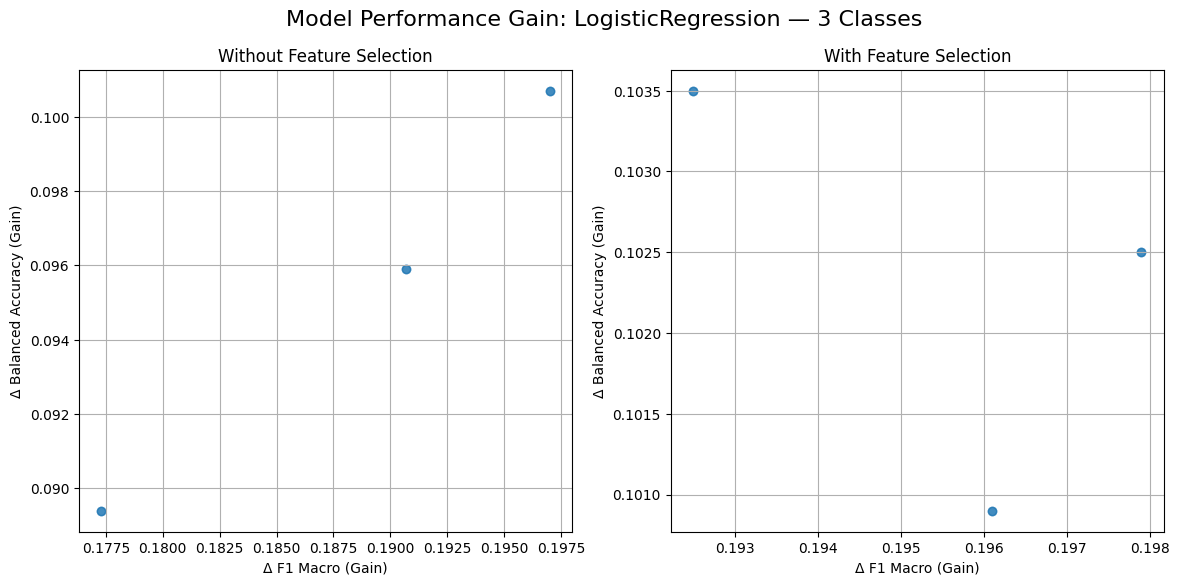

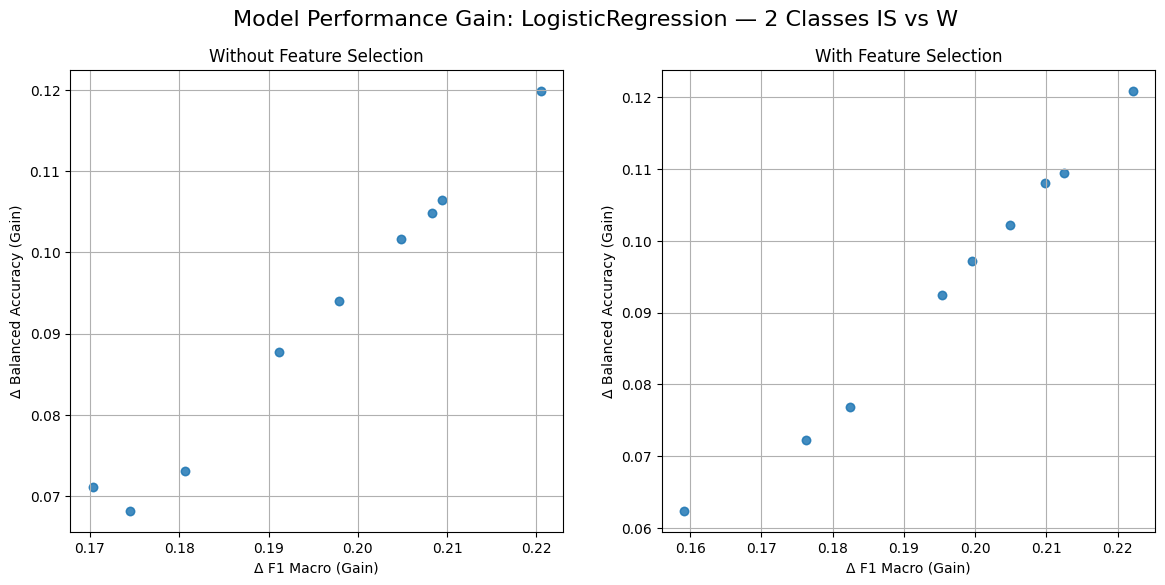

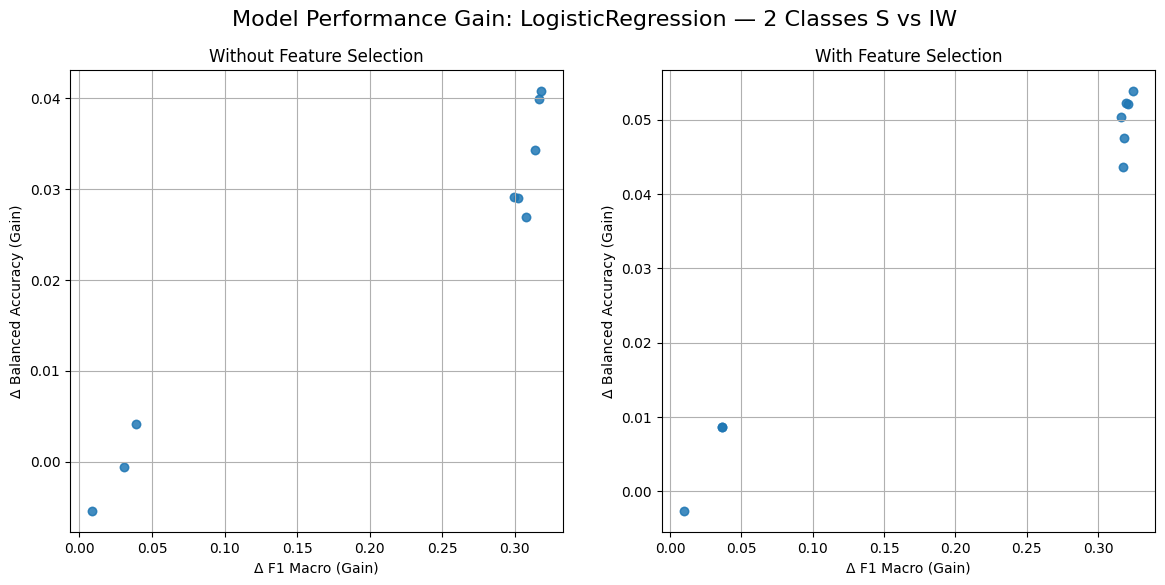

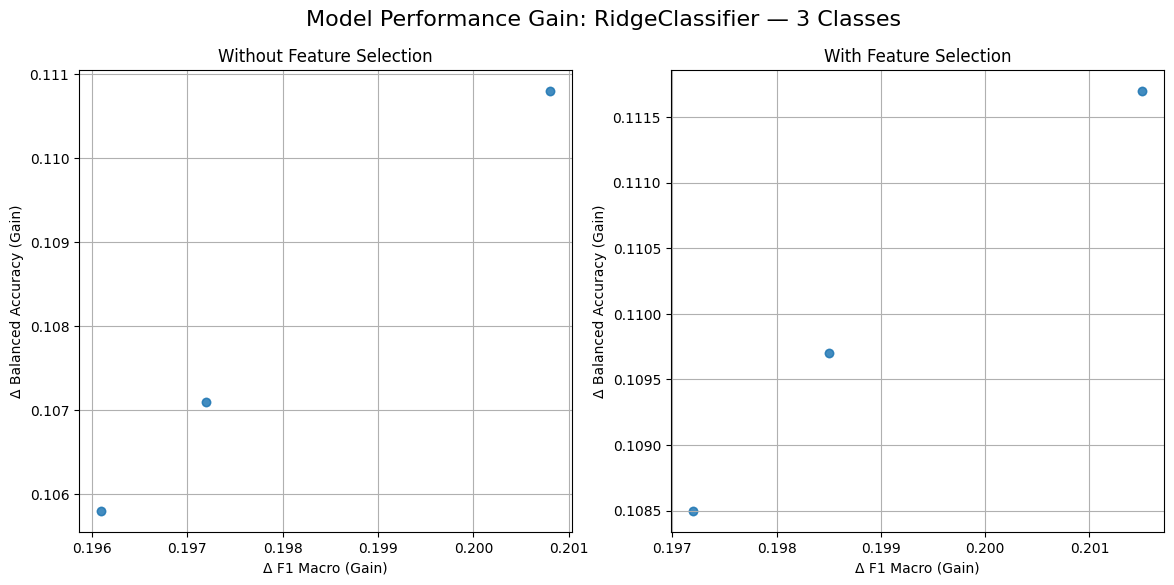

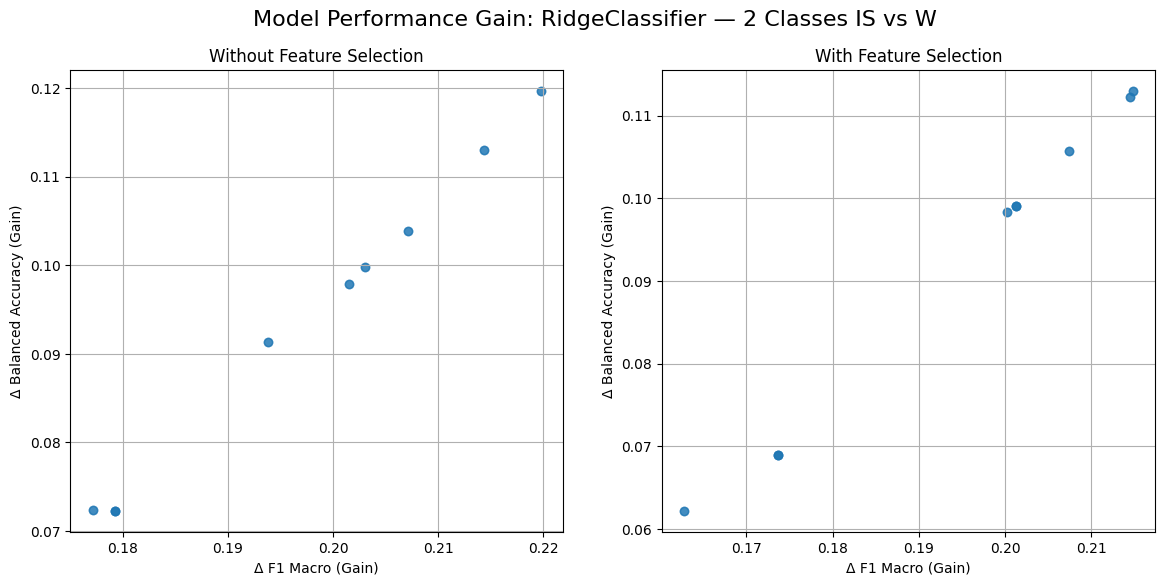

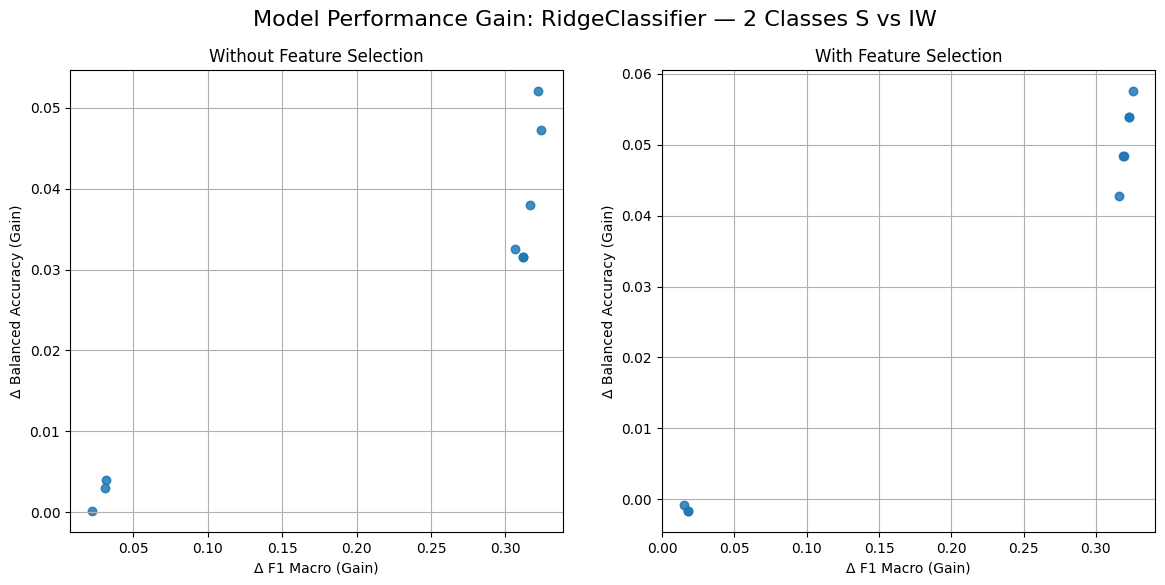

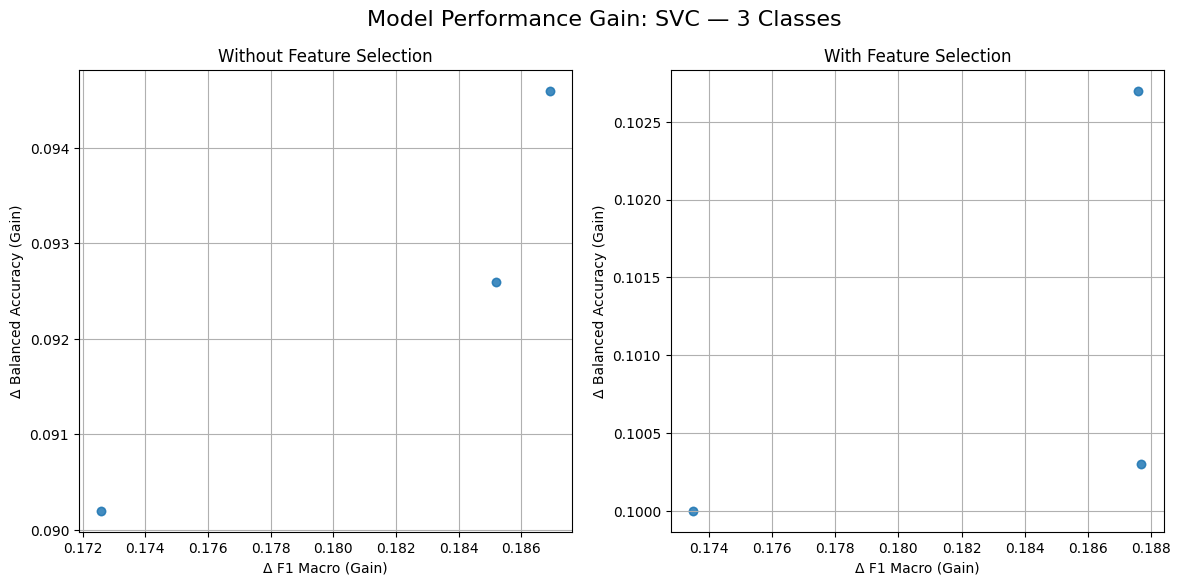

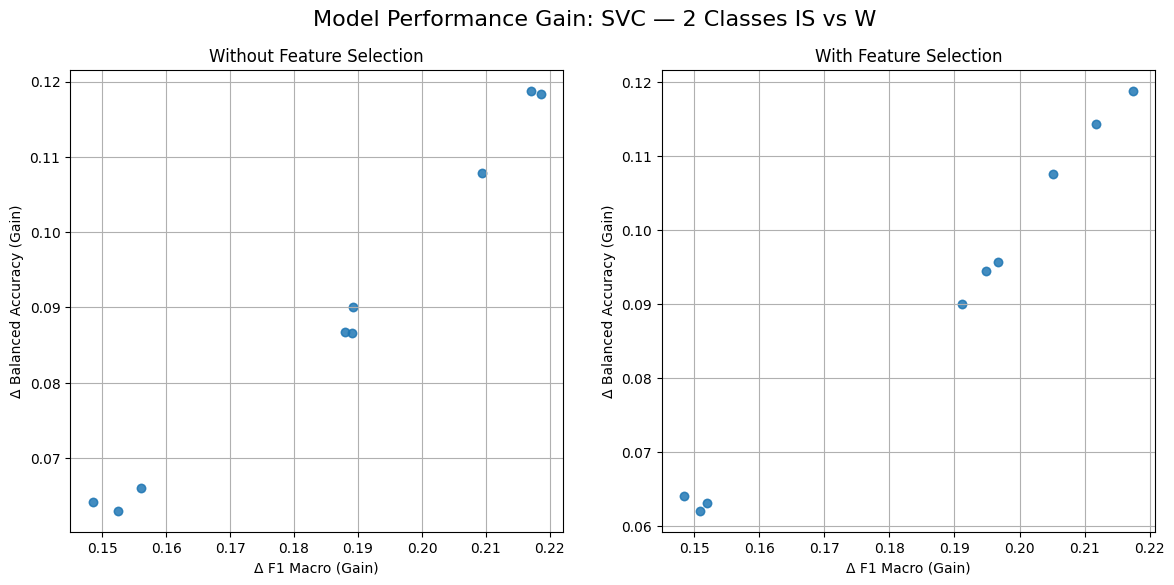

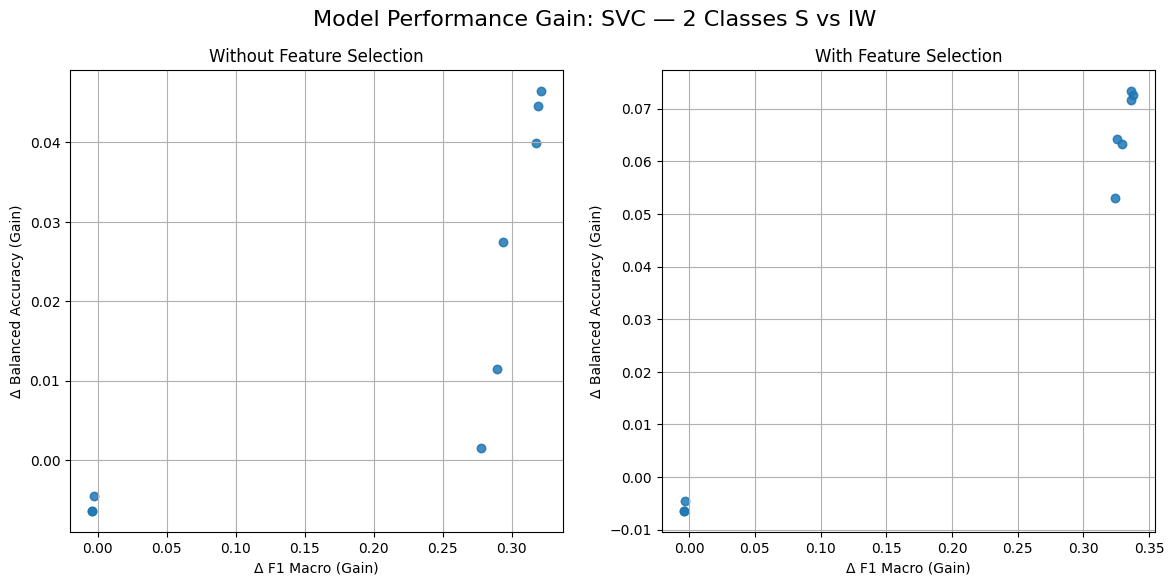

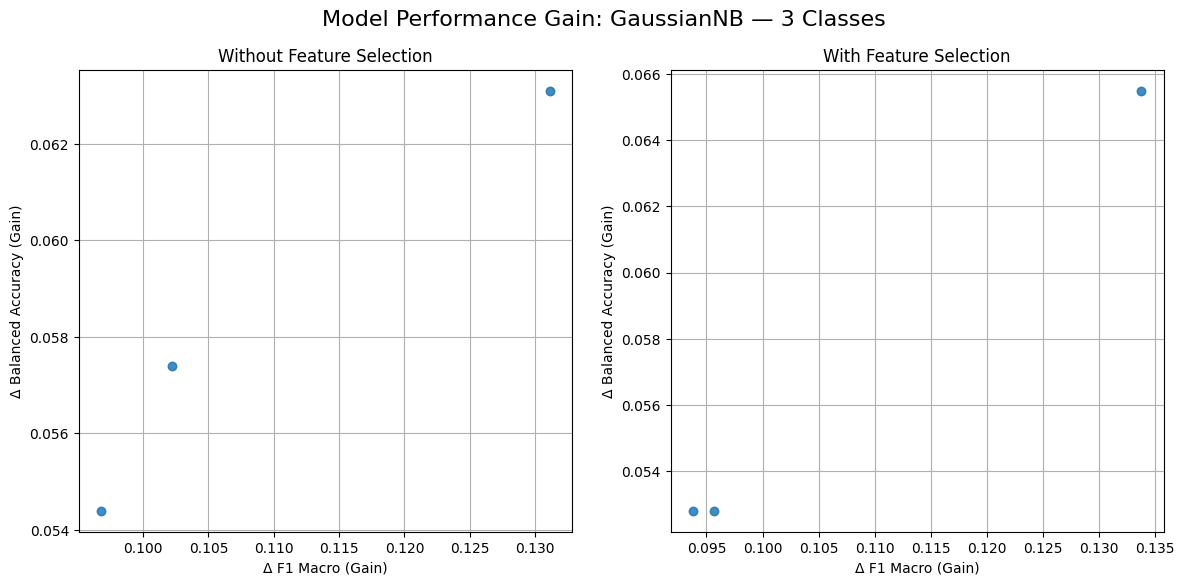

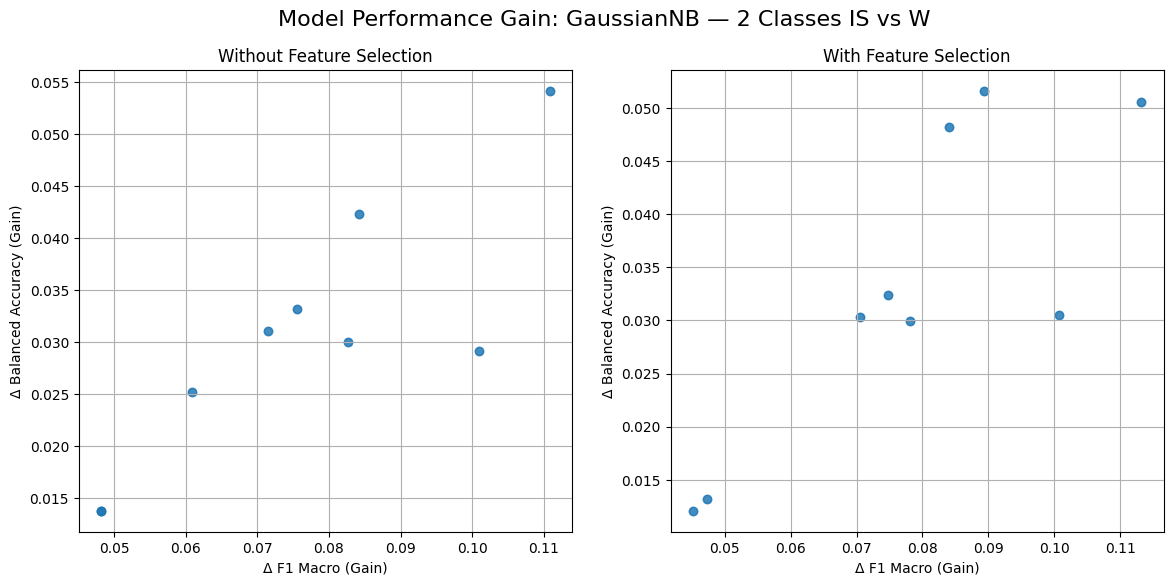

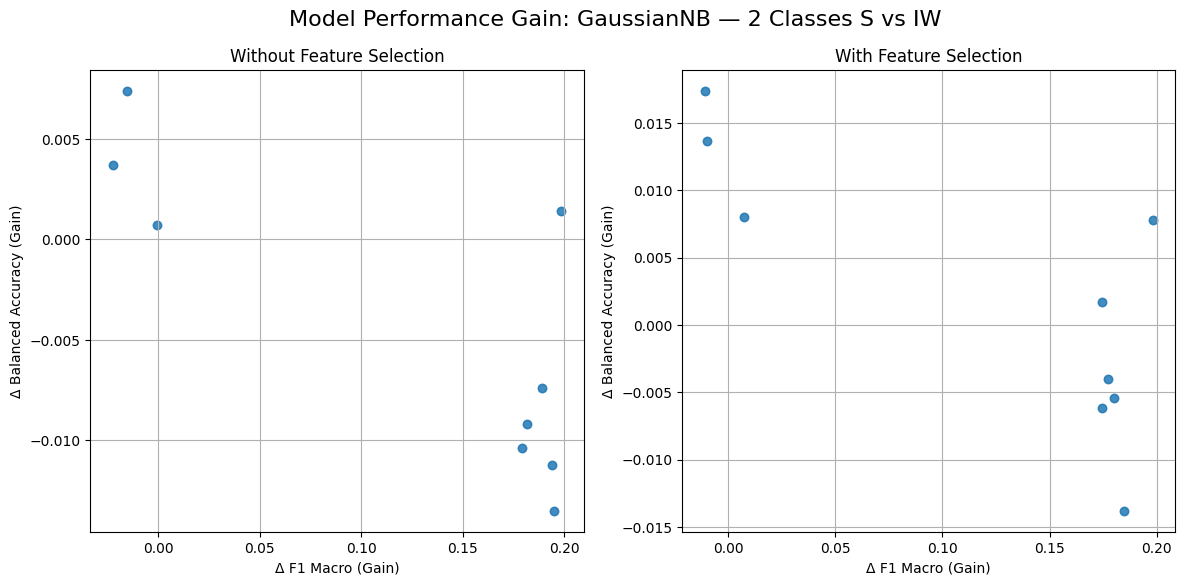

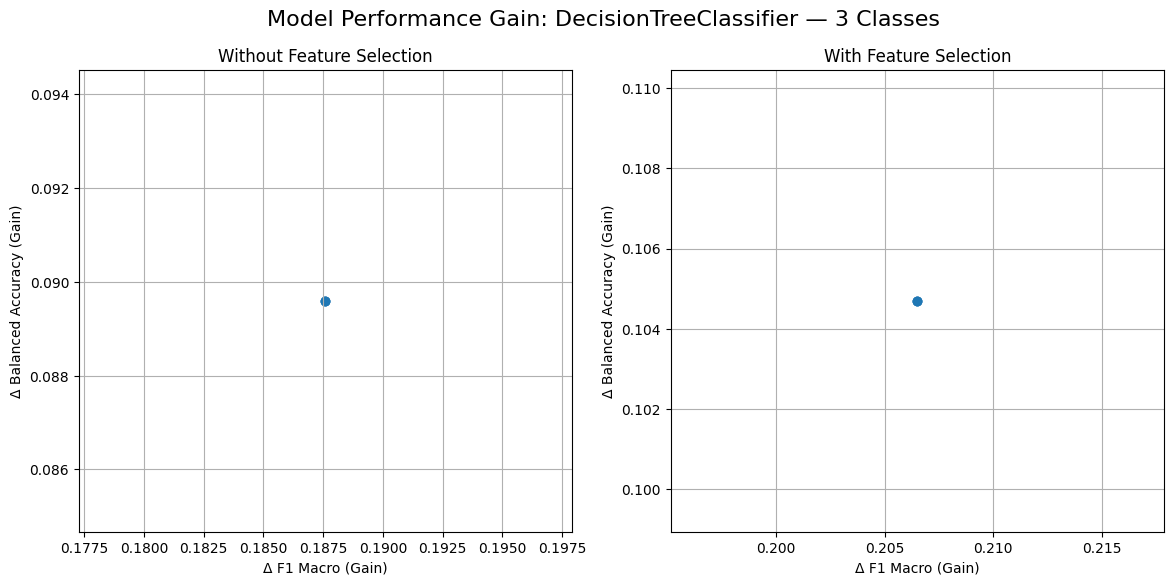

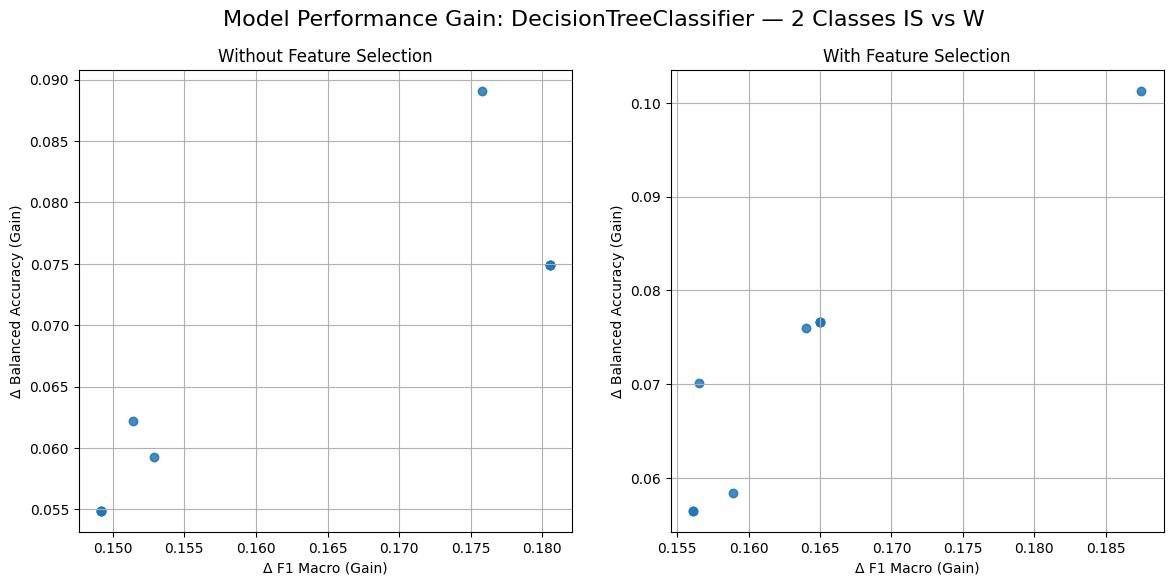

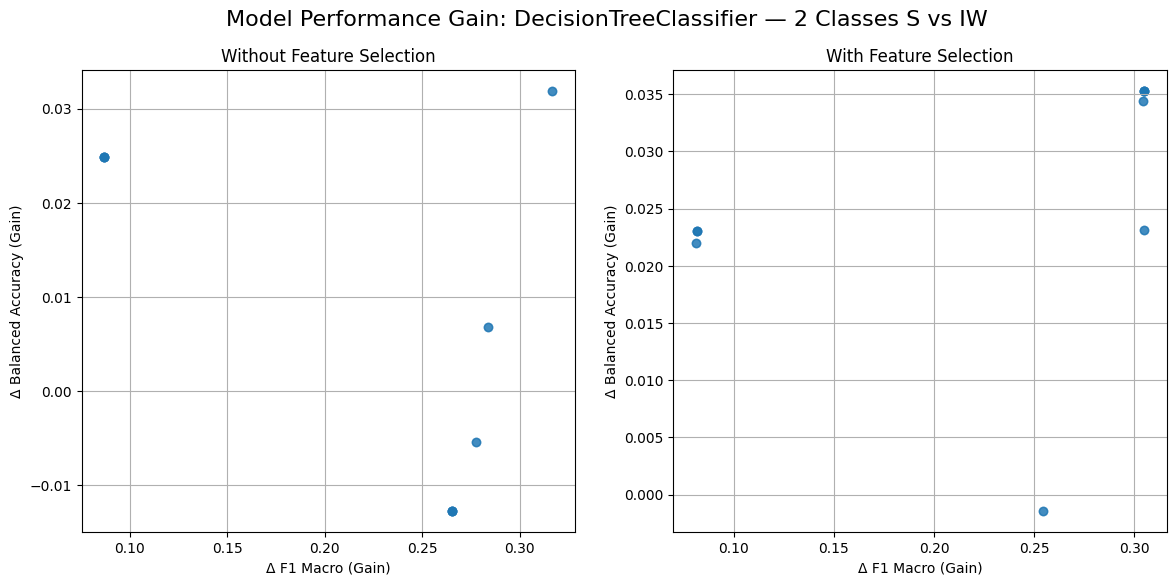

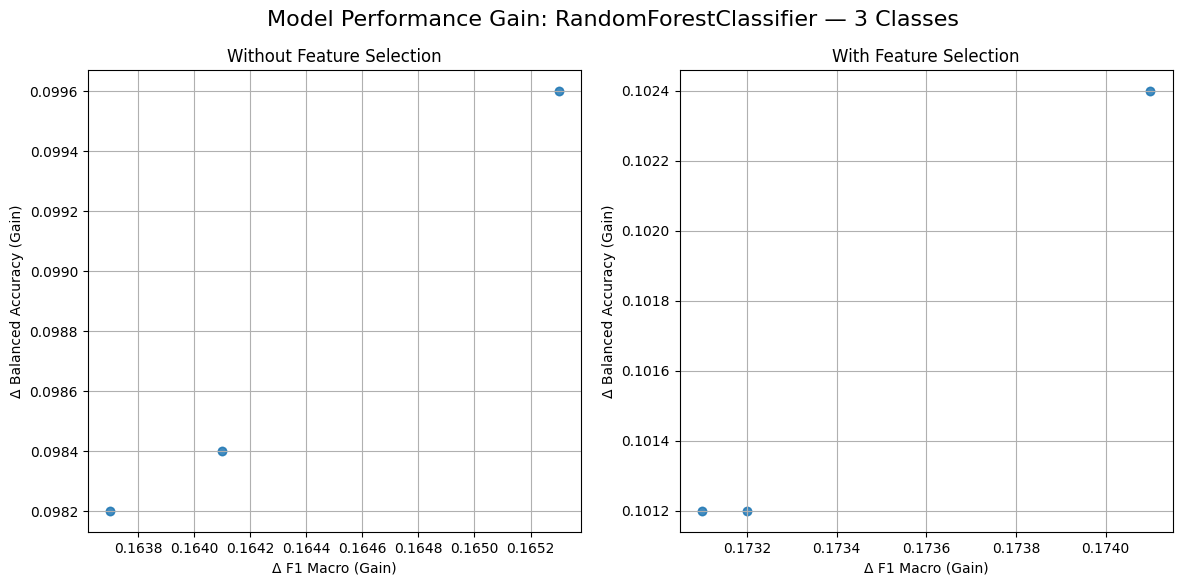

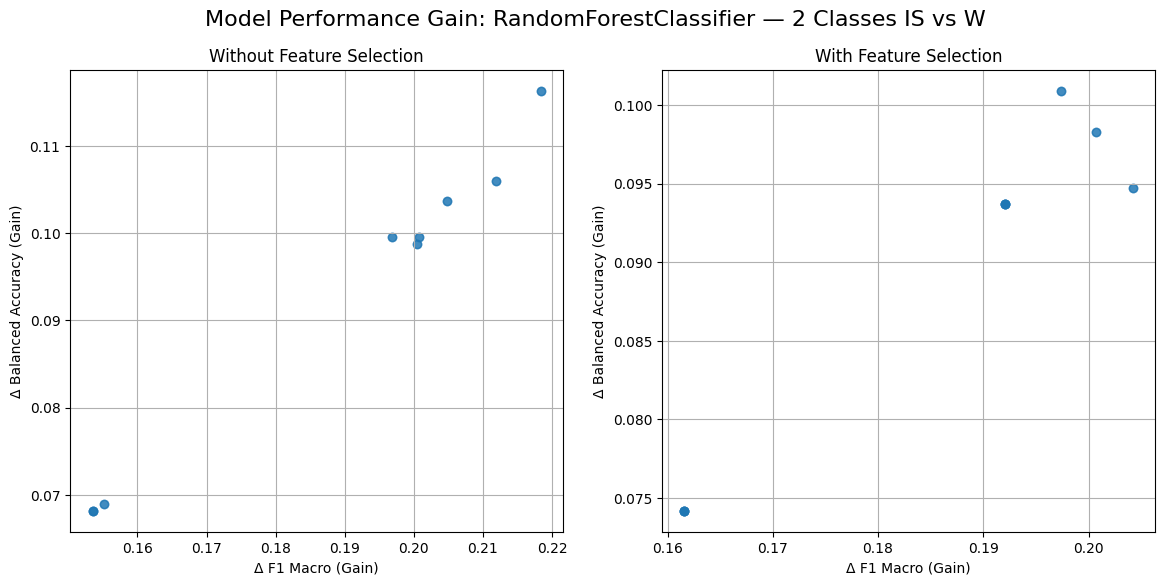

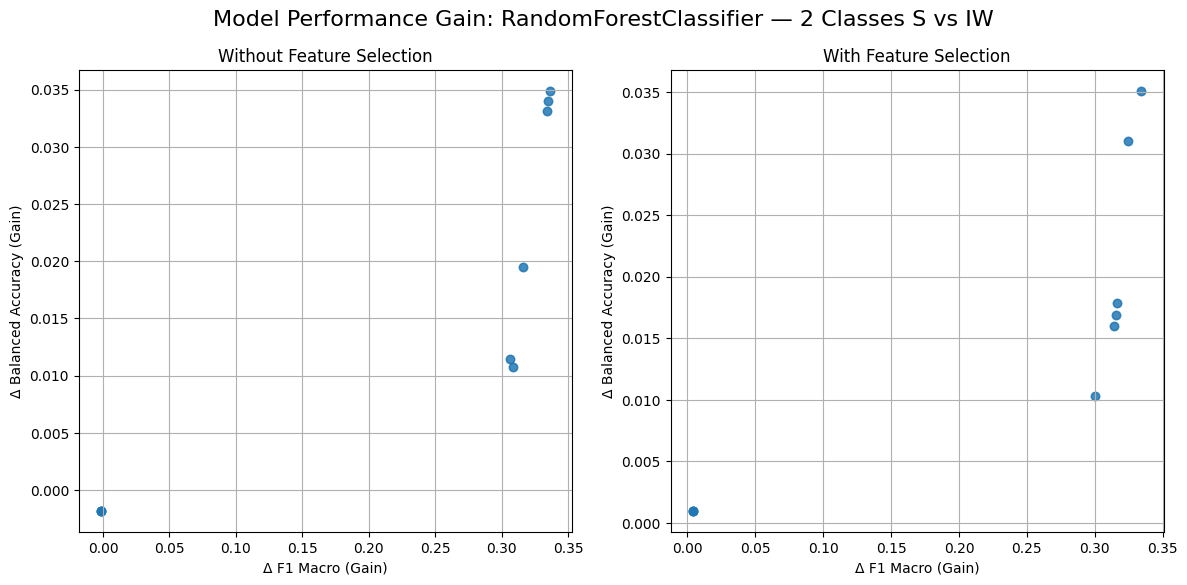

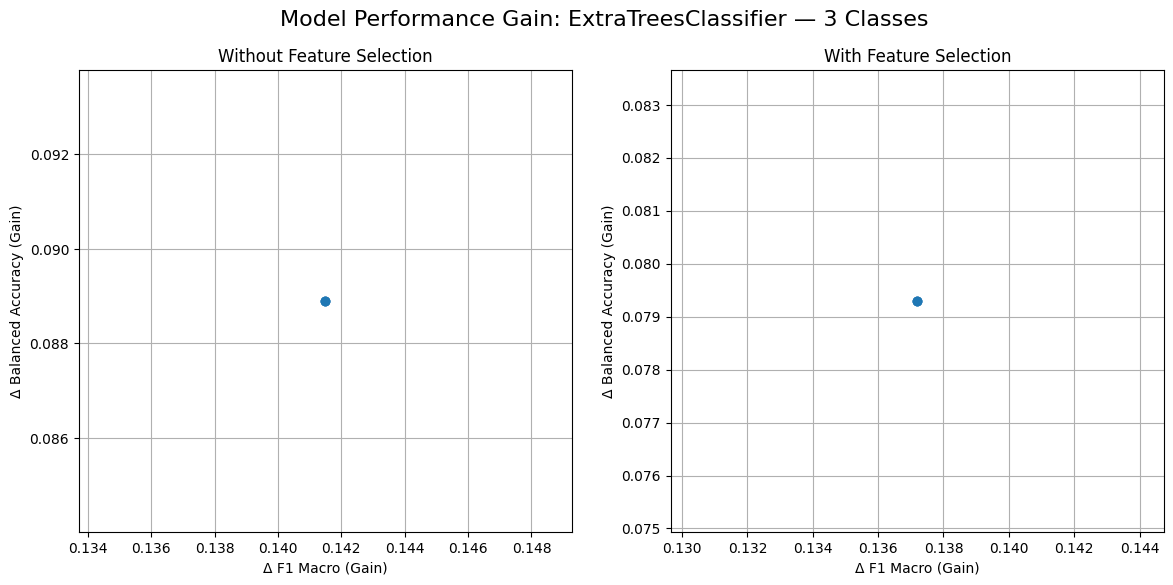

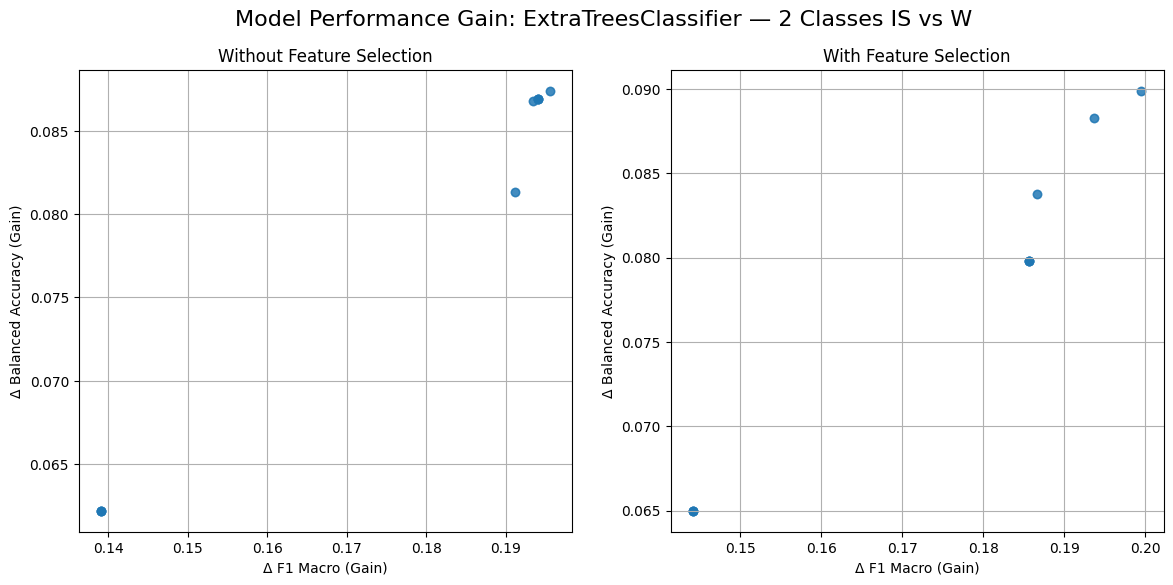

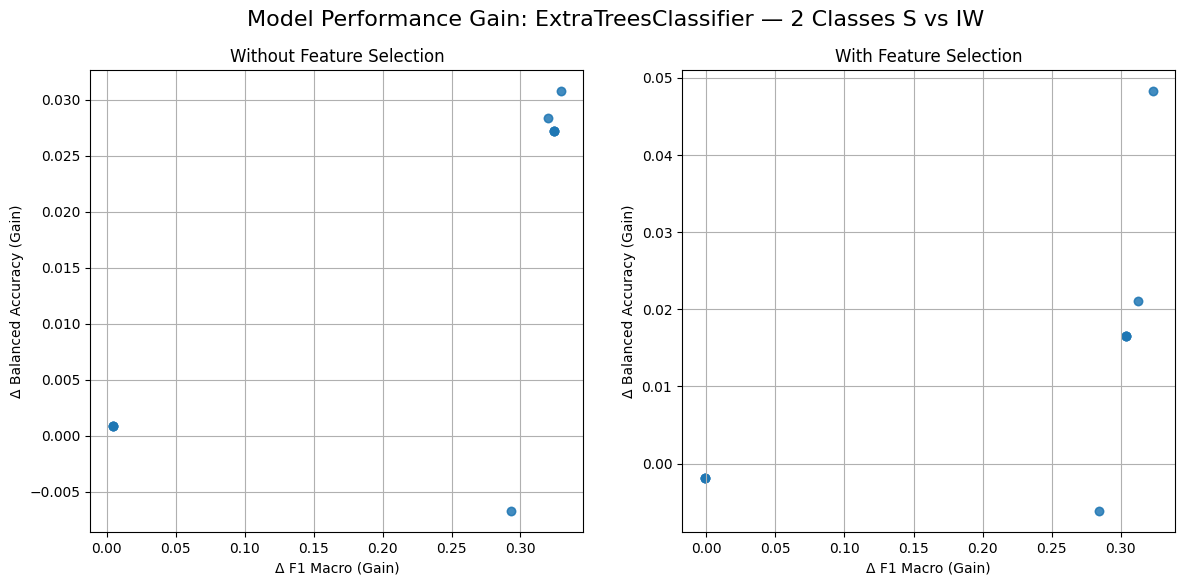

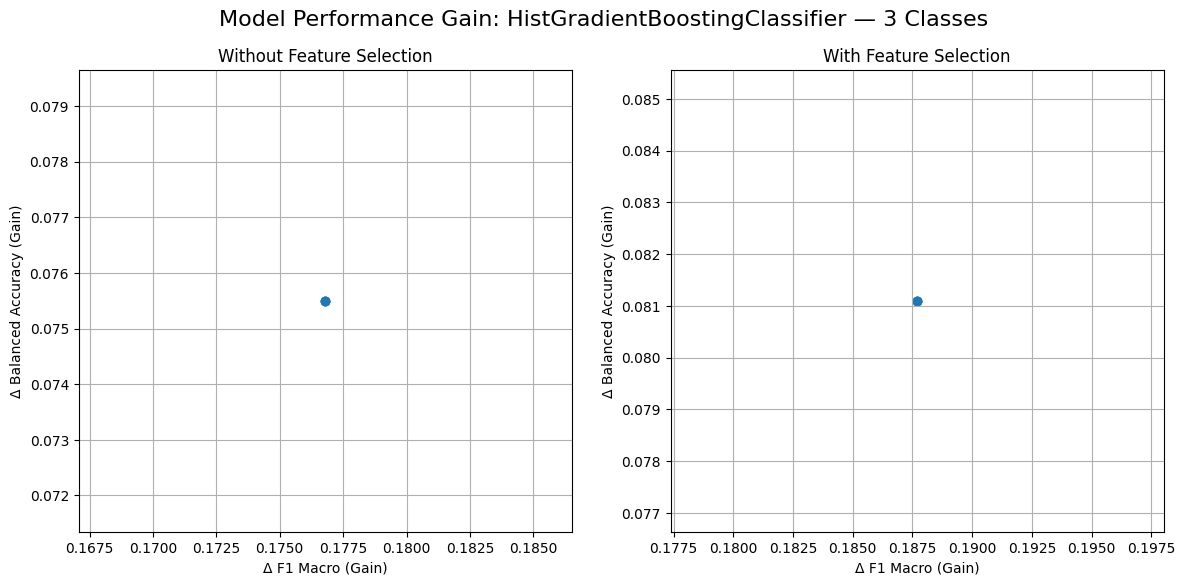

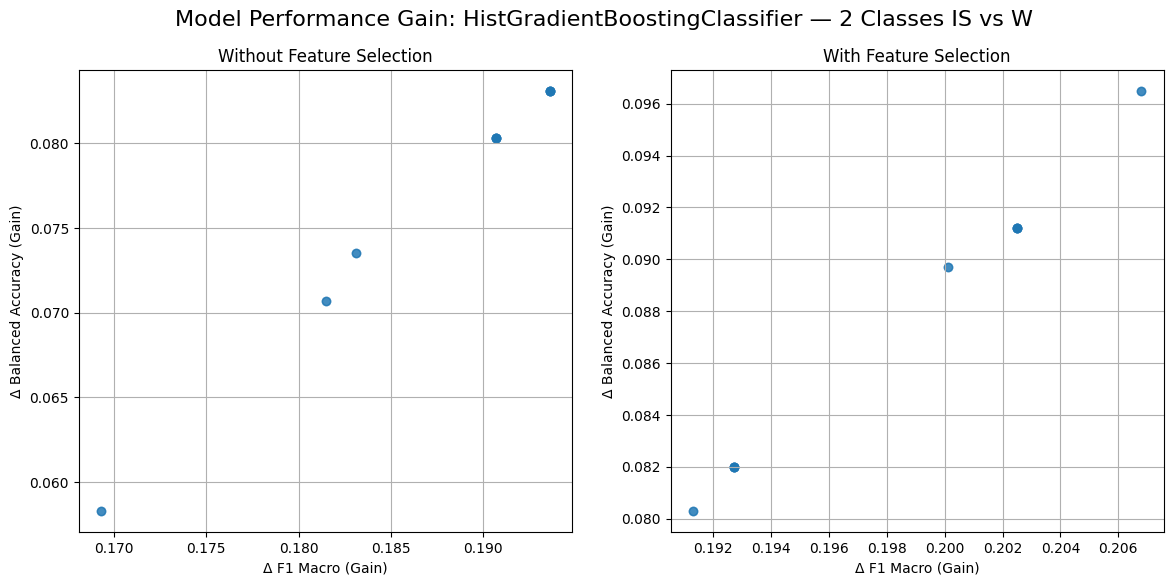

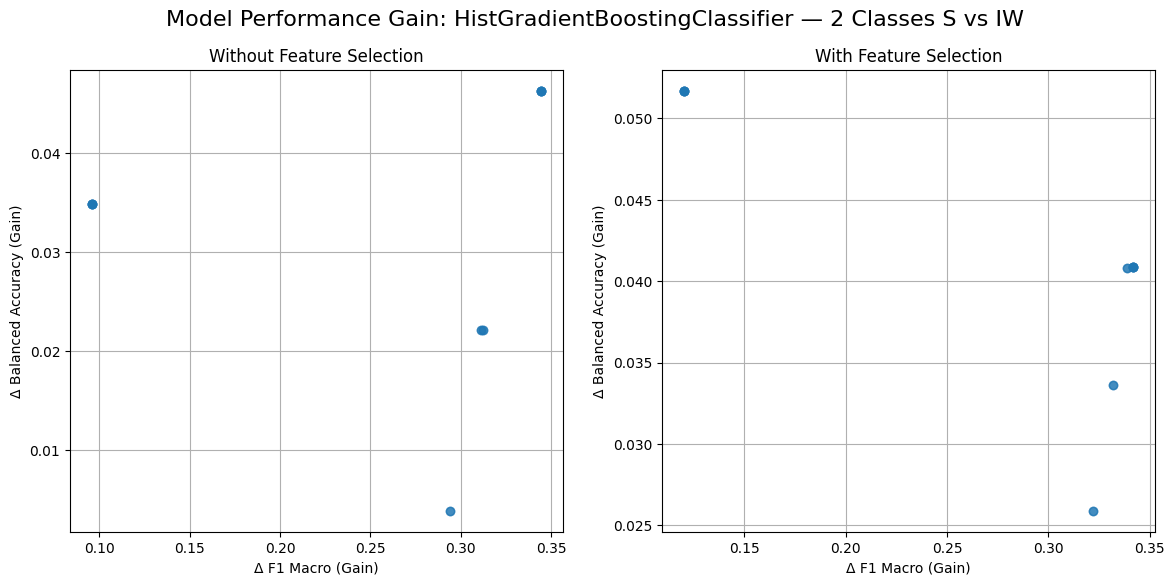

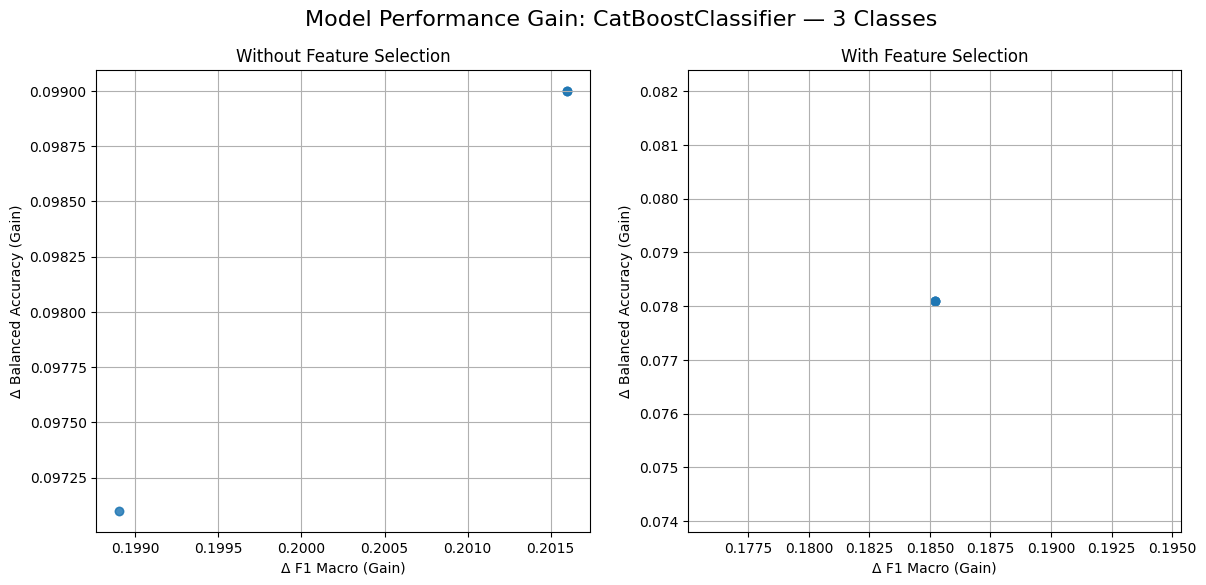

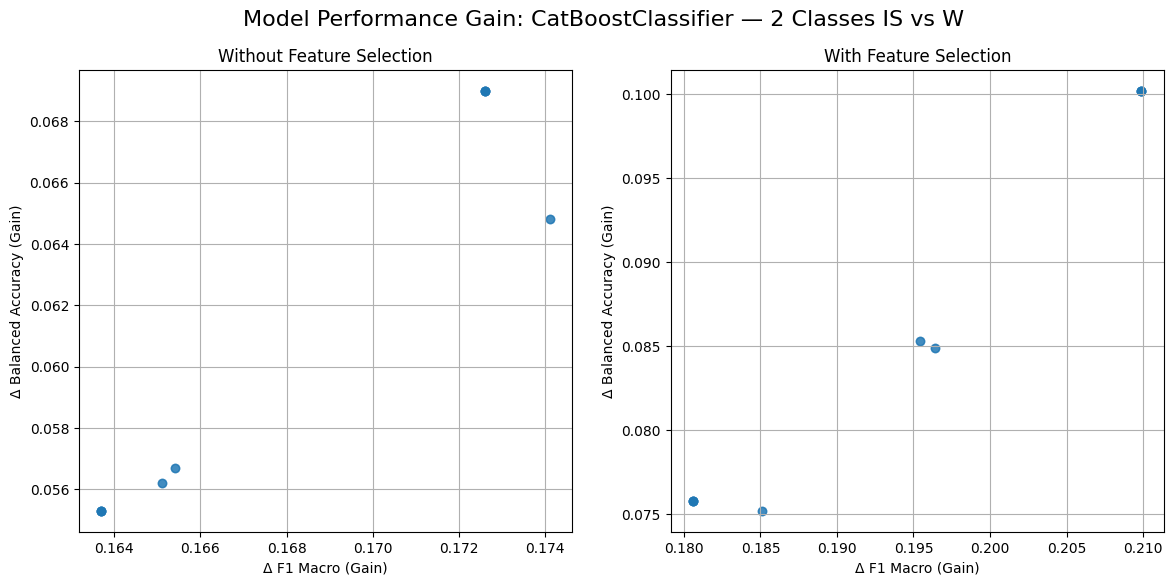

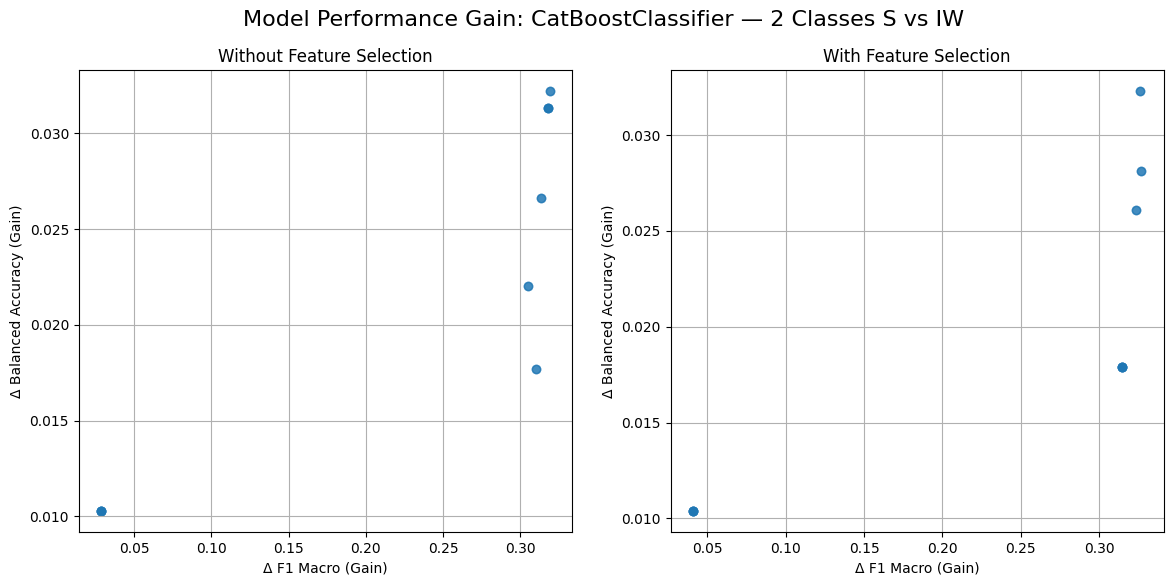

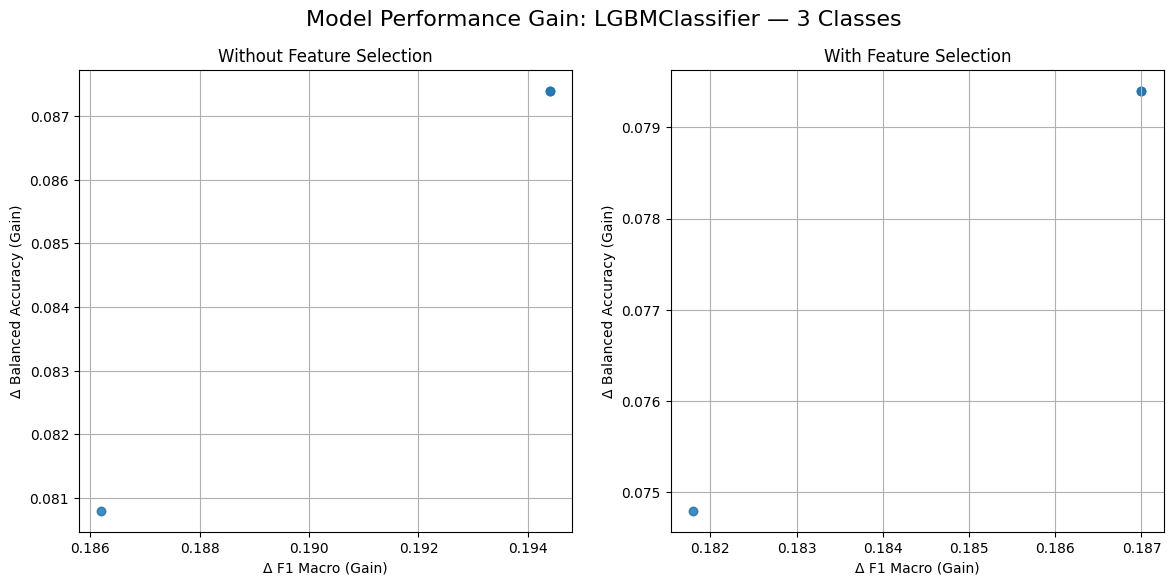

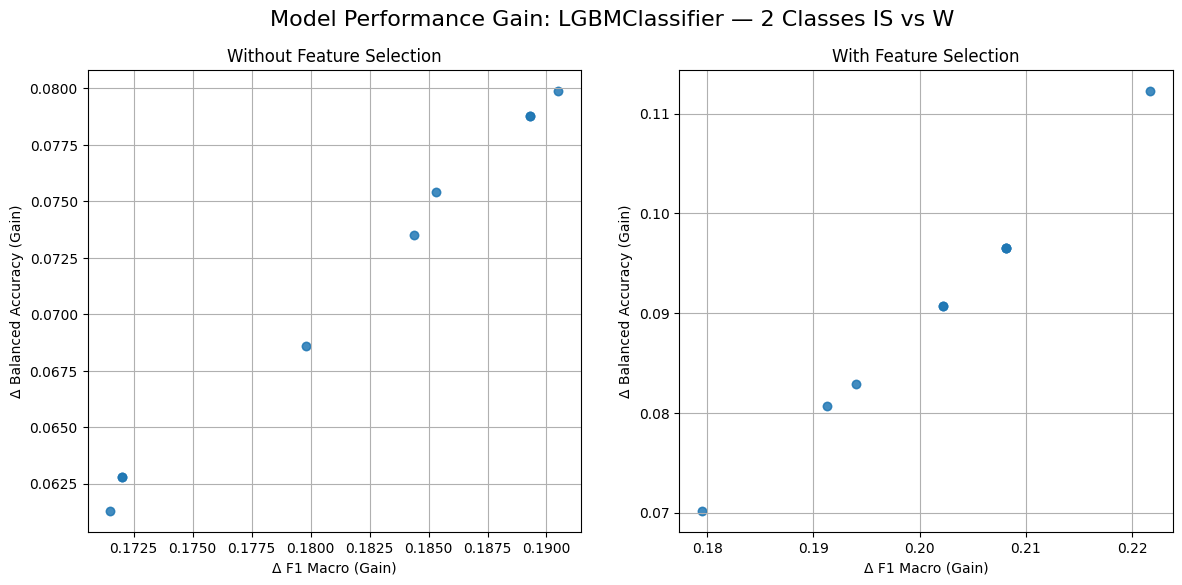

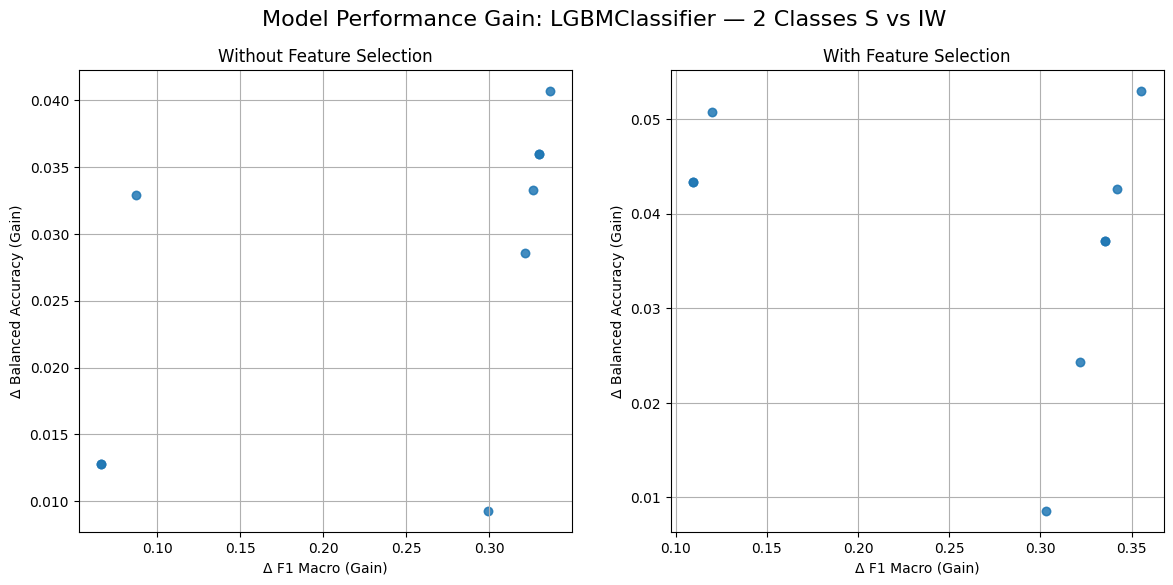

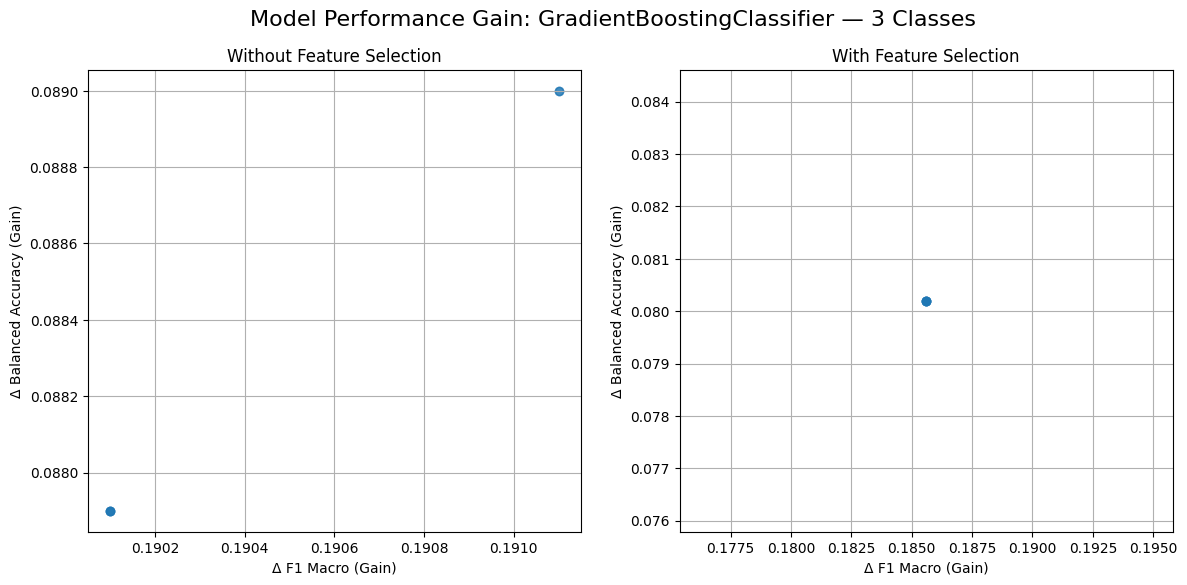

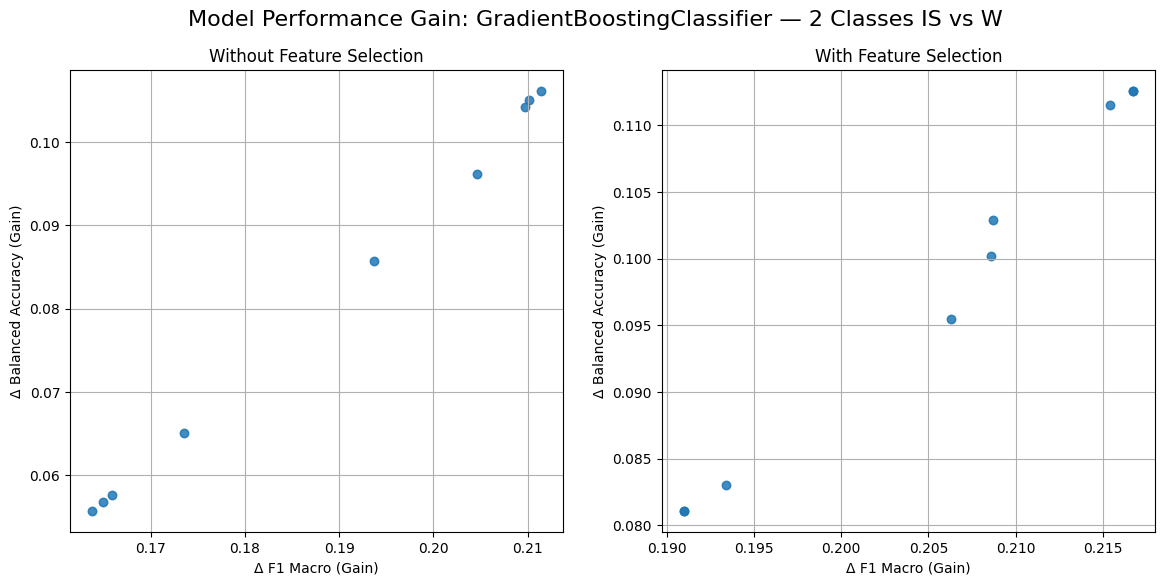

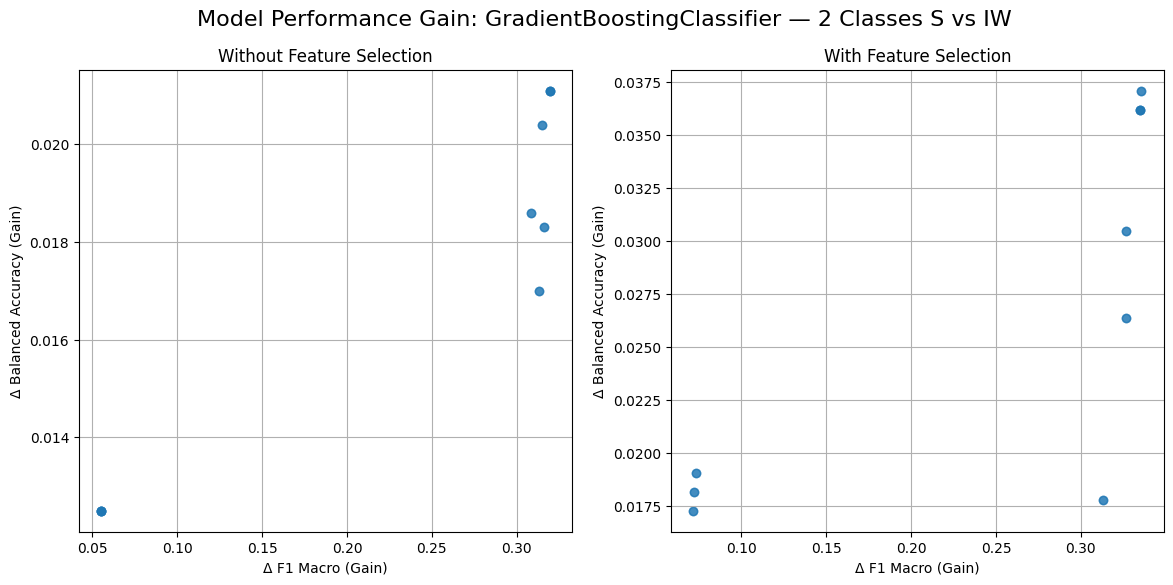

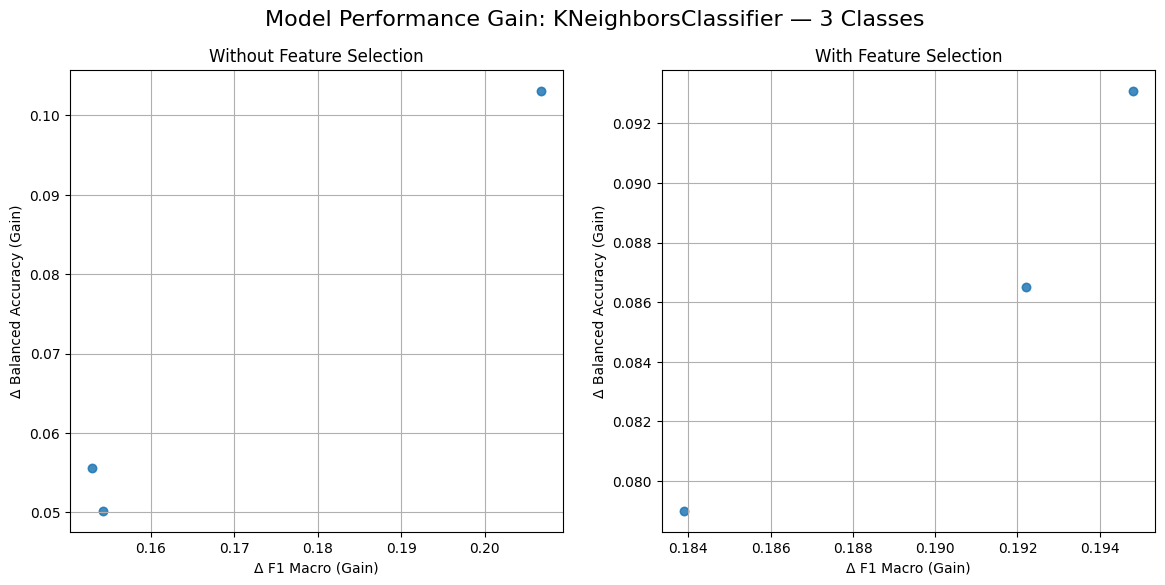

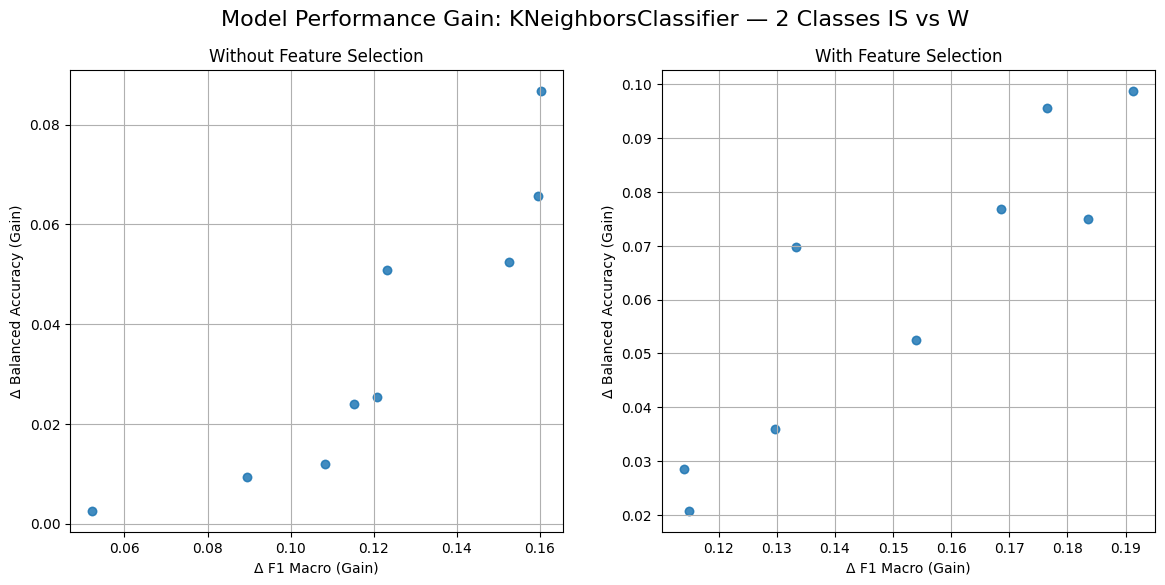

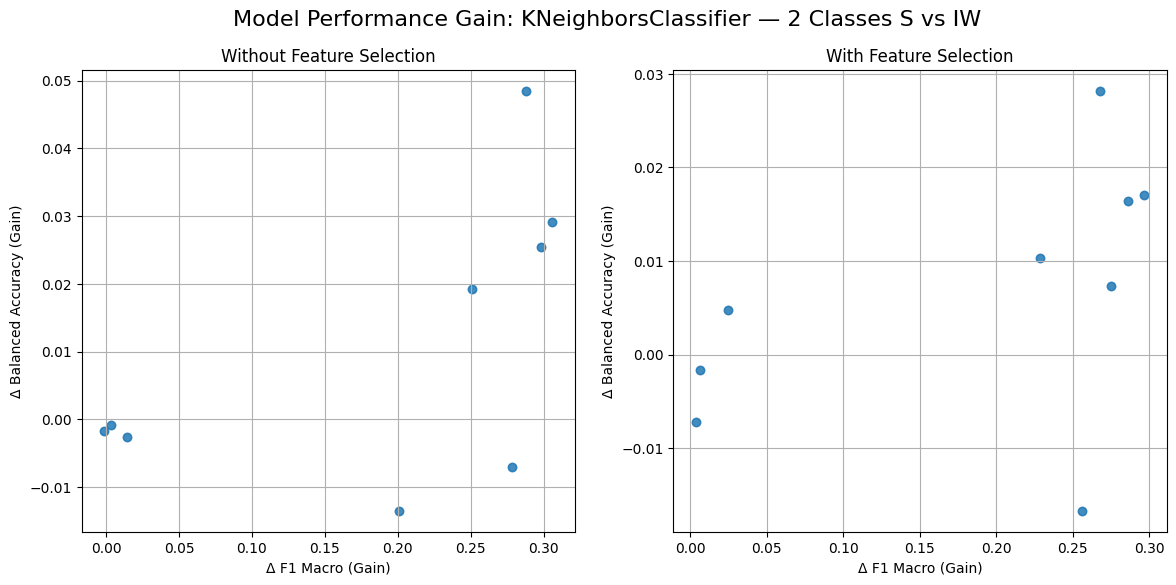

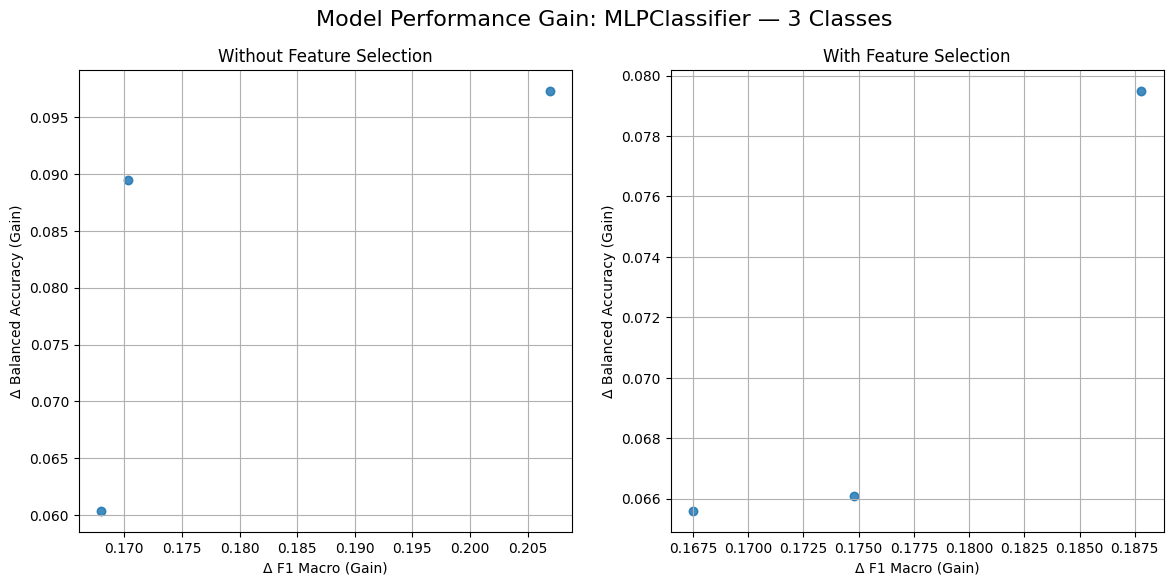

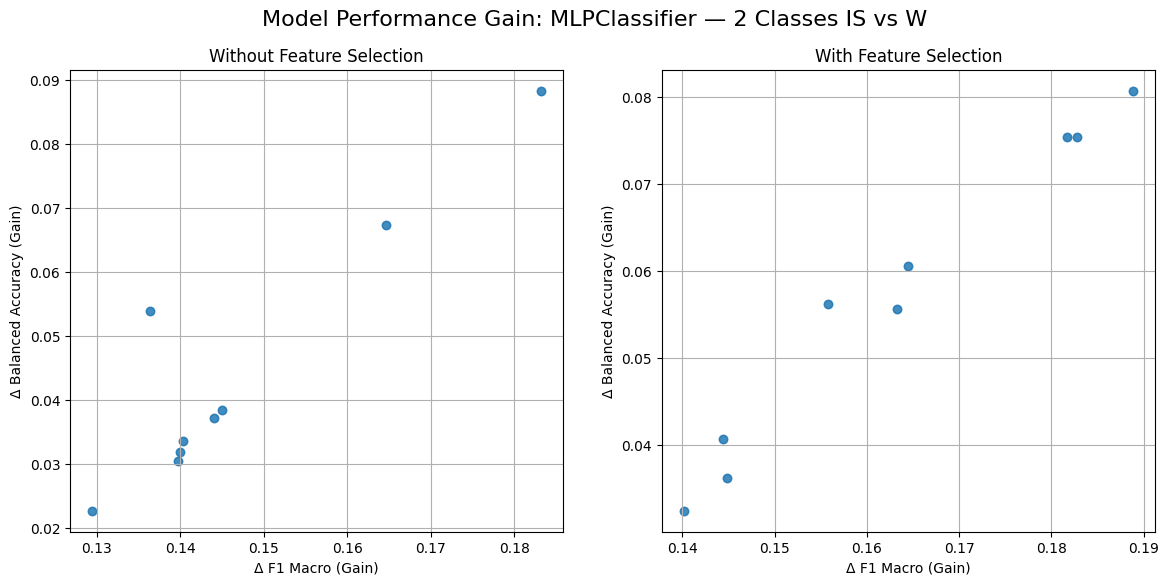

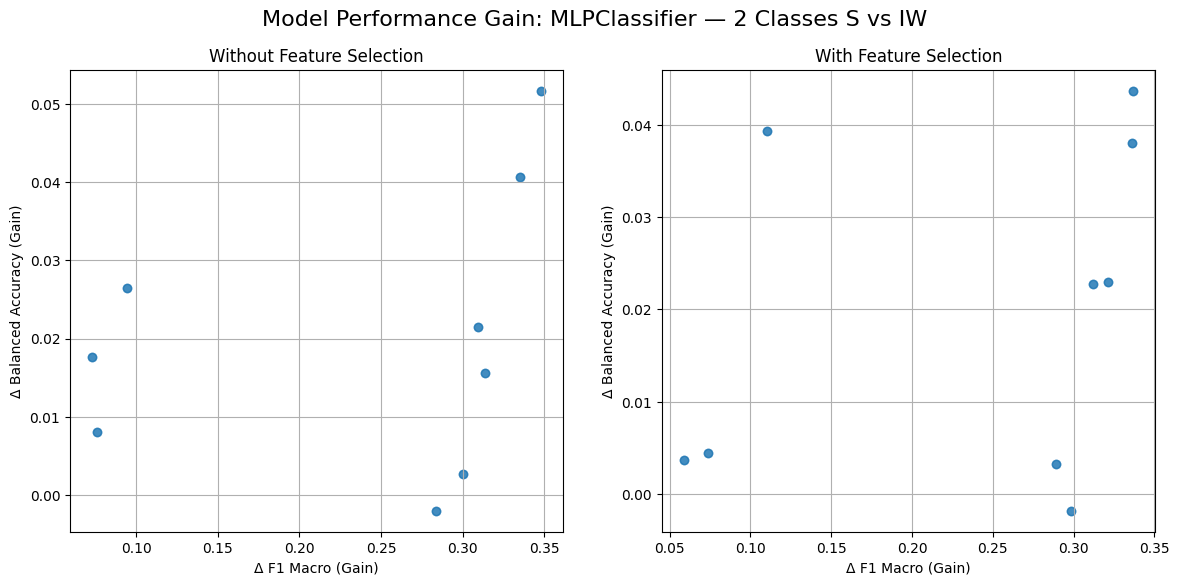

In [16]:
models_tested = models_performance['Model'].unique().tolist()
targets = ['3 Classes', '2 Classes IS vs W', '2 Classes S vs IW']

for model in models_tested:
    for type_target in targets:

        # --- SIN Feature Selection ---
        df_selected_all_vars = models_performance.loc[
            (models_performance['Model'] == model) &
            (models_performance['Parameters'].str.contains(type_target, na=False)) &
            (~models_performance['Parameters'].str.contains('Feature Selection', na=False)),
            ['Parameters', 'Δ Balanced Accuracy (Gain)', 'Δ F1_macro (Gain)']
        ].copy()

        # --- CON Feature Selection ---
        df_selected_FS = models_performance.loc[
            (models_performance['Model'] == model) &
            (models_performance['Parameters'].str.contains(type_target, na=False)) &
            (models_performance['Parameters'].str.contains('Feature Selection', na=False)),
            ['Parameters', 'Δ Balanced Accuracy (Gain)', 'Δ F1_macro (Gain)']
        ].copy()

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        for ax, df, title in zip(
            axes,
            [df_selected_all_vars, df_selected_FS],
            ["Without Feature Selection", "With Feature Selection"]
        ):
            # Scatter
            if not df.empty:
                ax.scatter(df["Δ F1_macro (Gain)"], df["Δ Balanced Accuracy (Gain)"], alpha=0.6)

            ax.set_title(title)
            ax.set_xlabel("Δ F1 Macro (Gain)")
            ax.set_ylabel("Δ Balanced Accuracy (Gain)")
            ax.grid(True)
        fig.suptitle(f"Model Performance Gain: {model} — {type_target}", fontsize=16)

## 3. Best Model Based on Gain Tresholds(Balanced Acc and F1_macro)

In [17]:
best_models = models_performance.loc[(models_performance['Δ Balanced Accuracy (Gain)']>=0.1) & (models_performance['Δ F1_macro (Gain)']>=0.2),:]
best_models = best_models[['Model','Parameters','test_bal_acc','test_f1_macro','Δ Balanced Accuracy (Gain)','Δ F1_macro (Gain)']]

best_models['Target'] = best_models['Parameters'].apply(
    lambda x: x.split(' / ')[0]
)

best_models['Scaler'] = best_models['Parameters'].apply(
    lambda x: 'Scaled' if ('StandardScaler' in x or 'MinMaxScaler' in x) else 'Not Scaled'
)

best_models['Data Balancing'] = best_models['Parameters'].apply(
    lambda x: 'Balanced' if ('SMOTE' in x or 'RandomOverSampler' in x) else 'Unbalanced'
)

best_models['Feature Selection'] = best_models['Parameters'].apply(
    lambda x: 'Yes FE' if 'Feature Selection' in x else 'No FE'
)
best_models.drop(columns=['Parameters'], inplace=True)
best_models['Model_Characteristics'] = best_models['Model'] + ' / ' + best_models['Scaler'] + ' / ' + best_models['Data Balancing'] + ' / ' + best_models['Feature Selection']

best_models_3_classes = best_models.loc[best_models['Target']=='3 Classes', :]
best_models_2_IS_W = best_models.loc[best_models['Target']=='2 Classes IS vs W', :]
best_models_2_S_IW = best_models.loc[best_models['Target']=='2 Classes S vs IW', :]


#### 3.1 The 3 Class Best Models

In [18]:
print(f"Number of Best Models for 3 Classes: {best_models_3_classes['Model_Characteristics'].nunique()} \nBest Models for 3 Classes{best_models_3_classes['Model'].unique().tolist()}")
best_models_3_classes.sort_values(by=['Δ Balanced Accuracy (Gain)', 'Δ F1_macro (Gain)'], ascending=False)

# 'RidgeClassifier / Scaled / Unbalanced / No FE', 
# 'RidgeClassifier / Scaled / Unbalanced / Yes FE',
# 'DecisionTreeClassifier / Not Scaled / Unbalanced / Yes FE', 
# 'DecisionTreeClassifier / Scaled / Unbalanced / Yes FE', 
# 'KNeighborsClassifier / Not Scaled / Unbalanced / No FE'

Number of Best Models for 3 Classes: 5 
Best Models for 3 Classes['RidgeClassifier', 'DecisionTreeClassifier', 'KNeighborsClassifier']


,Model,test_bal_acc,test_f1_macro,Δ Balanced Accuracy (Gain),Δ F1_macro (Gain),Target,Scaler,Data Balancing,Feature Selection,Model_Characteristics
128,RidgeClassifier,0.4117,0.3915,0.1117,0.2015,3 Classes,Scaled,Unbalanced,Yes FE,RidgeClassifier / Scaled / Unbalanced / Yes FE
131,RidgeClassifier,0.4117,0.3915,0.1117,0.2015,3 Classes,Scaled,Unbalanced,Yes FE,RidgeClassifier / Scaled / Unbalanced / Yes FE
86,RidgeClassifier,0.4108,0.3908,0.1108,0.2008,3 Classes,Scaled,Unbalanced,No FE,RidgeClassifier / Scaled / Unbalanced / No FE
89,RidgeClassifier,0.4108,0.3908,0.1108,0.2008,3 Classes,Scaled,Unbalanced,No FE,RidgeClassifier / Scaled / Unbalanced / No FE
378,DecisionTreeClassifier,0.4047,0.3965,0.1047,0.2065,3 Classes,Not Scaled,Unbalanced,Yes FE,DecisionTreeClassifier / Not Scaled / Unbalanc...
379,DecisionTreeClassifier,0.4047,0.3965,0.1047,0.2065,3 Classes,Scaled,Unbalanced,Yes FE,DecisionTreeClassifier / Scaled / Unbalanced /...
380,DecisionTreeClassifier,0.4047,0.3965,0.1047,0.2065,3 Classes,Scaled,Unbalanced,Yes FE,DecisionTreeClassifier / Scaled / Unbalanced /...
381,DecisionTreeClassifier,0.4047,0.3965,0.1047,0.2065,3 Classes,Not Scaled,Unbalanced,Yes FE,DecisionTreeClassifier / Not Scaled / Unbalanc...
382,DecisionTreeClassifier,0.4047,0.3965,0.1047,0.2065,3 Classes,Scaled,Unbalanced,Yes FE,DecisionTreeClassifier / Scaled / Unbalanced /...
383,DecisionTreeClassifier,0.4047,0.3965,0.1047,0.2065,3 Classes,Scaled,Unbalanced,Yes FE,DecisionTreeClassifier / Scaled / Unbalanced /...


#### 3.2 The 2 Class IS vs W Best Models

In [19]:
print(f"Number of Best Models for 2 Classes IS vs W: {best_models_2_IS_W['Model_Characteristics'].nunique()} \nBest Models for 2 Classes IS vs W{best_models_2_IS_W['Model'].unique().tolist()}")
best_models_2_IS_W.sort_values(by=['Δ Balanced Accuracy (Gain)', 'Δ F1_macro (Gain)'], ascending=False)

# 'LogisticRegression / Not Scaled / Balanced / No FE',
#  'LogisticRegression / Scaled / Balanced / No FE',
#  'LogisticRegression / Not Scaled / Balanced / Yes FE',
#  'LogisticRegression / Scaled / Balanced / Yes FE',
#  'RidgeClassifier / Scaled / Balanced / No FE',
#  'RidgeClassifier / Not Scaled / Balanced / Yes FE',
#  'RidgeClassifier / Scaled / Balanced / Yes FE',
#  'SVC / Not Scaled / Balanced / No FE', 
#  'SVC / Scaled / Balanced / No FE',
#  'SVC / Not Scaled / Balanced / Yes FE',
#  'SVC / Scaled / Balanced / Yes FE',
#  'RandomForestClassifier / Not Scaled / Balanced / No FE',
#  'RandomForestClassifier / Scaled / Balanced / No FE',
#  'CatBoostClassifier / Not Scaled / Balanced / Yes FE',
#  'CatBoostClassifier / Scaled / Balanced / Yes FE',
#  'LGBMClassifier / Scaled / Balanced / Yes FE',
#  'GradientBoostingClassifier / Not Scaled / Balanced / No FE',
#  'GradientBoostingClassifier / Scaled / Balanced / No FE',
#  'GradientBoostingClassifier / Not Scaled / Balanced / Yes FE',
#  'GradientBoostingClassifier / Scaled / Balanced / Yes FE'

best_models_2_IS_W

Number of Best Models for 2 Classes IS vs W: 20 
Best Models for 2 Classes IS vs W['LogisticRegression', 'RidgeClassifier', 'SVC', 'RandomForestClassifier', 'CatBoostClassifier', 'LGBMClassifier', 'GradientBoostingClassifier']


,Model,test_bal_acc,test_f1_macro,Δ Balanced Accuracy (Gain),Δ F1_macro (Gain),Target,Scaler,Data Balancing,Feature Selection,Model_Characteristics
8,LogisticRegression,0.6049,0.5983,0.1049,0.2083,2 Classes IS vs W,Not Scaled,Balanced,No FE,LogisticRegression / Not Scaled / Balanced / N...
10,LogisticRegression,0.6199,0.6105,0.1199,0.2205,2 Classes IS vs W,Scaled,Balanced,No FE,LogisticRegression / Scaled / Balanced / No FE
11,LogisticRegression,0.6017,0.5948,0.1017,0.2048,2 Classes IS vs W,Scaled,Balanced,No FE,LogisticRegression / Scaled / Balanced / No FE
13,LogisticRegression,0.6064,0.5994,0.1064,0.2094,2 Classes IS vs W,Scaled,Balanced,No FE,LogisticRegression / Scaled / Balanced / No FE
17,LogisticRegression,0.6049,0.5983,0.1049,0.2083,2 Classes IS vs W,Not Scaled,Balanced,No FE,LogisticRegression / Not Scaled / Balanced / N...
...,...,...,...,...,...,...,...,...,...,...
899,GradientBoostingClassifier,0.6126,0.6067,0.1126,0.2167,2 Classes IS vs W,Not Scaled,Balanced,Yes FE,GradientBoostingClassifier / Not Scaled / Bala...
901,GradientBoostingClassifier,0.6002,0.5986,0.1002,0.2086,2 Classes IS vs W,Scaled,Balanced,Yes FE,GradientBoostingClassifier / Scaled / Balanced...
902,GradientBoostingClassifier,0.6115,0.6054,0.1115,0.2154,2 Classes IS vs W,Scaled,Balanced,Yes FE,GradientBoostingClassifier / Scaled / Balanced...
904,GradientBoostingClassifier,0.6029,0.5987,0.1029,0.2087,2 Classes IS vs W,Scaled,Balanced,Yes FE,GradientBoostingClassifier / Scaled / Balanced...


#### 3.2 The 2 Class IS Vs W Best Models

In [20]:
print(f"Number of Best Models for 2 Classes S vs IW: {best_models_2_S_IW['Model_Characteristics'].nunique()} \nBest Models for 2 Classes S vs IW {best_models_2_S_IW['Model_Characteristics'].unique().tolist()}")


Number of Best Models for 2 Classes S vs IW: 0 
Best Models for 2 Classes S vs IW []


# HYPERPARAMETER TURNING

In [17]:
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from scipy.stats import loguniform


def types_of_evaluation_combinations(features_n):
    dict_types = {}
    for val in features_n:
        if val == 'ALL':
            d = {
                'T2.1.1.1': ['FeatureEngineered', 'passthrough', 'passthrough', 'passthrough'],
                'T2.1.2.1': ['FeatureEngineered', 'passthrough', SMOTE(random_state=42), 'passthrough'],
                'T2.1.3.1': ['FeatureEngineered', 'passthrough', RandomOverSampler(random_state=42), 'passthrough'],

                'T2.2.1.1': ['FeatureEngineered', StandardScaler(), 'passthrough', 'passthrough'],
                'T2.2.2.1': ['FeatureEngineered', StandardScaler(), SMOTE(random_state=42), 'passthrough'],
                'T2.2.3.1': ['FeatureEngineered', StandardScaler(), RandomOverSampler(random_state=42), 'passthrough'],

                'T2.3.1.1': ['FeatureEngineered', MinMaxScaler(), 'passthrough', 'passthrough'],
                'T2.3.2.1': ['FeatureEngineered', MinMaxScaler(), SMOTE(random_state=42), 'passthrough'],
                'T2.3.3.1': ['FeatureEngineered', MinMaxScaler(), RandomOverSampler(random_state=42), 'passthrough'],
            }
            dict_types.update(d)
        else:
            d = {
                f'T2.1.1.2_{val}': ['FeatureEngineered', 'passthrough', 'passthrough', SelectKBest(f_classif, k=int(val))],
                f'T2.1.2.2_{val}': ['FeatureEngineered', 'passthrough', SMOTE(random_state=42), SelectKBest(f_classif, k=int(val))],
                f'T2.1.3.2_{val}': ['FeatureEngineered', 'passthrough', RandomOverSampler(random_state=42), SelectKBest(f_classif, k=int(val))],

                f'T2.2.1.2_{val}': ['FeatureEngineered', StandardScaler(), 'passthrough', SelectKBest(f_classif, k=int(val))],
                f'T2.2.2.2_{val}': ['FeatureEngineered', StandardScaler(), SMOTE(random_state=42), SelectKBest(f_classif, k=int(val))],
                f'T2.2.3.2_{val}': ['FeatureEngineered', StandardScaler(), RandomOverSampler(random_state=42), SelectKBest(f_classif, k=int(val))],

                f'T2.3.1.2_{val}': ['FeatureEngineered', MinMaxScaler(), 'passthrough', SelectKBest(f_classif, k=int(val))],
                f'T2.3.2.2_{val}': ['FeatureEngineered', MinMaxScaler(), SMOTE(random_state=42), SelectKBest(f_classif, k=int(val))],
                f'T2.3.3.2_{val}': ['FeatureEngineered', MinMaxScaler(), RandomOverSampler(random_state=42), SelectKBest(f_classif, k=int(val))],
            }
            dict_types.update(d)
    return dict_types



def model_test_evaluation(dict_class, y_train, model, param_distributions,
                          n_iter=50, n_splits=5, random_state=42, n_jobs=-1):

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fits_por_combo = n_iter * cv.get_n_splits()
    total_fits = fits_por_combo * len(dict_class)

    rows = []  # <-- acumulador

    with tqdm(total=total_fits, desc="Total fits", unit="fit") as pbar:
        for key, (dataset_type, scaler, sampler, selector) in dict_class.items():

            X_train_use = X_train_fe

            num_pipe = Pipeline([
                ("select", selector),
                ("scale", scaler),
            ])

            cat_pipe = Pipeline([
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ])

            preprocess = ColumnTransformer([
                ("num", num_pipe, numerical_col),
                ("cat", cat_pipe, categroical_col),
            ])

            pipe = Pipeline(steps=[
                ("prep", preprocess),
                ("sampler", sampler),
                ("clf", clone(model)),
            ])

            random_search = RandomizedSearchCV(
                estimator=pipe,
                param_distributions=param_distributions,
                n_iter=n_iter,
                scoring="balanced_accuracy",
                cv=cv,
                random_state=random_state,
                n_jobs=n_jobs,
                verbose=0,
                error_score="raise"
            )

            random_search.fit(X_train_use, y_train)

            # en vez de crear df_model y concat, guardamos una fila (dict)
            rows.append({
                "Key": key,
                "Model": type(model).__name__,
                "Dataset_Type": dataset_type,
                "Scaler": type(scaler).__name__ if scaler != "passthrough" else "passthrough",
                "Sampler": type(sampler).__name__ if sampler != "passthrough" else "passthrough",
                "Selector": type(selector).__name__ if selector != "passthrough" else "passthrough",
                "Best_Params": random_search.best_params_,
                "Best_Score": random_search.best_score_,
            })

            pbar.update(fits_por_combo)
            pbar.set_postfix_str(f"{key} | best={random_search.best_score_:.4f}")

    # un solo DataFrame al final (sin warning)
    df_results_all = pd.DataFrame.from_records(
        rows,
        columns=["Key", "Model", "Dataset_Type", "Scaler", "Sampler", "Selector", "Best_Params", "Best_Score"]
    )

    return df_results_all


## 1. The 2 Class Traget IS vs W

In [18]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated",
    category=UserWarning
)


### 1.1 LogisticRegression

In [ ]:

from sklearn.linear_model import LogisticRegression
from scipy.stats import loguniform, uniform

log_reg_model = LogisticRegression(
    max_iter=20000,
    solver="saga",
    random_state=42
)


param_distributions = [
    # Equivalente a penalty="l2"
    {
        "clf__C": loguniform(1e-4, 1e2),
        "clf__l1_ratio": [0],
        "clf__class_weight": [None, "balanced"],
    },


    {
        "clf__C": loguniform(1e-4, 1e2),
        "clf__l1_ratio": [1],
        "clf__class_weight": [None, "balanced"],
    },


    {
        "clf__C": loguniform(1e-4, 1e2),
        "clf__l1_ratio": np.linspace(0, 1, 6),
        "clf__class_weight": [None, "balanced"],
    },
]


features_n = ['10','15','20', 'ALL']
test_combinations = types_of_evaluation_combinations(features_n)

results = model_test_evaluation(test_combinations, y_train_2_IS_W, log_reg_model, param_distributions)
results


Total fits: 100%|██████████| 9000/9000 [02:37<00:00, 57.25fit/s, T2.3.3.1 | best=0.6138]    


,Key,Model,Dataset_Type,Scaler,Sampler,Selector,Best_Params,Best_Score
0,T2.1.1.2_10,LogisticRegression,FeatureEngineered,passthrough,passthrough,SelectKBest,"{'clf__C': 0.0018794668241638478, 'clf__class_...",0.626080
1,T2.1.2.2_10,LogisticRegression,FeatureEngineered,passthrough,SMOTE,SelectKBest,"{'clf__C': 0.00028965395242758657, 'clf__class...",0.629112
2,T2.1.3.2_10,LogisticRegression,FeatureEngineered,passthrough,RandomOverSampler,SelectKBest,"{'clf__C': 0.0018794668241638478, 'clf__class_...",0.637800
3,T2.2.1.2_10,LogisticRegression,FeatureEngineered,StandardScaler,passthrough,SelectKBest,"{'clf__C': 0.054853888940716654, 'clf__class_w...",0.632058
4,T2.2.2.2_10,LogisticRegression,FeatureEngineered,StandardScaler,SMOTE,SelectKBest,"{'clf__C': 0.2548014921296846, 'clf__class_wei...",0.632872
5,T2.2.3.2_10,LogisticRegression,FeatureEngineered,StandardScaler,RandomOverSampler,SelectKBest,"{'clf__C': 0.054502936945582565, 'clf__class_w...",0.634175
6,T2.3.1.2_10,LogisticRegression,FeatureEngineered,MinMaxScaler,passthrough,SelectKBest,"{'clf__C': 0.13335385049873044, 'clf__class_we...",0.620191
7,T2.3.2.2_10,LogisticRegression,FeatureEngineered,MinMaxScaler,SMOTE,SelectKBest,"{'clf__C': 0.2548014921296846, 'clf__class_wei...",0.616476
8,T2.3.3.2_10,LogisticRegression,FeatureEngineered,MinMaxScaler,RandomOverSampler,SelectKBest,"{'clf__C': 0.2548014921296846, 'clf__class_wei...",0.616903
9,T2.1.1.2_15,LogisticRegression,FeatureEngineered,passthrough,passthrough,SelectKBest,"{'clf__C': 0.0018794668241638478, 'clf__class_...",0.628044


### 1.2 RidgeClassifier

In [20]:
from sklearn.linear_model import RidgeClassifier
param_distributions = [
    {
        "clf__alpha": loguniform(1e-6, 1e3),
        "clf__class_weight": [None, "balanced"],
        "clf__fit_intercept": [True, False],
        "clf__solver": ["auto", "svd", "cholesky", "lsqr", "sag", "saga"],
        "clf__tol": loguniform(1e-6, 1e-2),
        "clf__max_iter": [500, 1000, 2000, 5000],
    }
]

features_n = ['10','15','20', 'ALL']
test_combinations = types_of_evaluation_combinations(features_n)

results = model_test_evaluation(test_combinations, y_train_2_IS_W, RidgeClassifier(random_state=42), param_distributions)
results

Total fits:   0%|          | 0/9000 [00:00<?, ?fit/s]/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<

,Key,Model,Dataset_Type,Scaler,Sampler,Selector,Best_Params,Best_Score
0,T2.1.1.2_10,RidgeClassifier,FeatureEngineered,passthrough,passthrough,SelectKBest,"{'clf__alpha': 2.358594058414265, 'clf__class_...",0.620065
1,T2.1.2.2_10,RidgeClassifier,FeatureEngineered,passthrough,SMOTE,SelectKBest,"{'clf__alpha': 305.9723168418651, 'clf__class_...",0.630756
2,T2.1.3.2_10,RidgeClassifier,FeatureEngineered,passthrough,RandomOverSampler,SelectKBest,"{'clf__alpha': 2.358594058414265, 'clf__class_...",0.619428
3,T2.2.1.2_10,RidgeClassifier,FeatureEngineered,StandardScaler,passthrough,SelectKBest,"{'clf__alpha': 490.5556676028767, 'clf__class_...",0.623279
4,T2.2.2.2_10,RidgeClassifier,FeatureEngineered,StandardScaler,SMOTE,SelectKBest,"{'clf__alpha': 305.9723168418651, 'clf__class_...",0.624157
5,T2.2.3.2_10,RidgeClassifier,FeatureEngineered,StandardScaler,RandomOverSampler,SelectKBest,"{'clf__alpha': 147.26456718740803, 'clf__class...",0.616862
6,T2.3.1.2_10,RidgeClassifier,FeatureEngineered,MinMaxScaler,passthrough,SelectKBest,"{'clf__alpha': 2.630213296503228e-06, 'clf__cl...",0.614302
7,T2.3.2.2_10,RidgeClassifier,FeatureEngineered,MinMaxScaler,SMOTE,SelectKBest,"{'clf__alpha': 0.002348881295853313, 'clf__cla...",0.618973
8,T2.3.3.2_10,RidgeClassifier,FeatureEngineered,MinMaxScaler,RandomOverSampler,SelectKBest,"{'clf__alpha': 1.2056216919628222, 'clf__class...",0.600227
9,T2.1.1.2_15,RidgeClassifier,FeatureEngineered,passthrough,passthrough,SelectKBest,"{'clf__alpha': 490.5556676028767, 'clf__class_...",0.619656


### 1.3 SVC

In [27]:

from sklearn.svm import SVC
param_distributions = [
    {
        "clf__kernel": ["linear"],
        "clf__C": loguniform(1e-4, 1e3),
        "clf__class_weight": [None, "balanced"],
        "clf__tol": loguniform(1e-5, 1e-2),
    },

    {
        "clf__kernel": ["rbf"],
        "clf__C": loguniform(1e-4, 1e3),
        "clf__gamma": loguniform(1e-4, 1e1),
        "clf__class_weight": [None, "balanced"],
        "clf__tol": loguniform(1e-5, 1e-2),
    }
]

features_n = ['10','15','20', 'ALL']
test_combinations = types_of_evaluation_combinations(features_n)

results = model_test_evaluation(test_combinations, y_train_2_IS_W,  SVC(probability=False), param_distributions)
results

Total fits:   0%|          | 0/9000 [00:00<?, ?fit/s]/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<

KeyboardInterrupt: 

### 1.4 RandomForestClassifier

In [33]:
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'clf__n_estimators': randint(100, 500),
    'clf__max_depth': [None] + list(range(5, 41, 5)),
    'clf__min_samples_split': randint(2, 15),
    'clf__min_samples_leaf': randint(1, 8),
    'clf__max_features': ['sqrt', 'log2']
}

features_n = ['10','15','20', 'ALL']
test_combinations = types_of_evaluation_combinations(features_n)

results = model_test_evaluation(test_combinations, y_train_2_IS_W,  RandomForestClassifier(random_state=42, n_jobs=-1), param_dist)
results

Total fits:  11%|█         | 1000/9000 [00:27<03:39, 36.53fit/s, T2.2.1.2_10 | best=0.5880]/home/fsc/Desktop/PD_Project_UofL/venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
Total fits:  14%|█▍        | 1250/9000 [00:34<03:37, 35.65fit/s, T2.2.2.2_10 | best=0.6007]/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal a

,Key,Model,Dataset_Type,Scaler,Sampler,Selector,Best_Params,Best_Score
0,T2.1.1.2_10,RandomForestClassifier,FeatureEngineered,passthrough,passthrough,SelectKBest,"{'clf__max_depth': 15, 'clf__max_features': 's...",0.588023
1,T2.1.2.2_10,RandomForestClassifier,FeatureEngineered,passthrough,SMOTE,SelectKBest,"{'clf__max_depth': 5, 'clf__max_features': 'sq...",0.601333
2,T2.1.3.2_10,RandomForestClassifier,FeatureEngineered,passthrough,RandomOverSampler,SelectKBest,"{'clf__max_depth': 5, 'clf__max_features': 'sq...",0.606099
3,T2.2.1.2_10,RandomForestClassifier,FeatureEngineered,StandardScaler,passthrough,SelectKBest,"{'clf__max_depth': 15, 'clf__max_features': 's...",0.588023
4,T2.2.2.2_10,RandomForestClassifier,FeatureEngineered,StandardScaler,SMOTE,SelectKBest,"{'clf__max_depth': 10, 'clf__max_features': 'l...",0.600690
5,T2.2.3.2_10,RandomForestClassifier,FeatureEngineered,StandardScaler,RandomOverSampler,SelectKBest,"{'clf__max_depth': 5, 'clf__max_features': 'sq...",0.605035
6,T2.3.1.2_10,RandomForestClassifier,FeatureEngineered,MinMaxScaler,passthrough,SelectKBest,"{'clf__max_depth': 15, 'clf__max_features': 's...",0.588023
7,T2.3.2.2_10,RandomForestClassifier,FeatureEngineered,MinMaxScaler,SMOTE,SelectKBest,"{'clf__max_depth': 35, 'clf__max_features': 's...",0.614561
8,T2.3.3.2_10,RandomForestClassifier,FeatureEngineered,MinMaxScaler,RandomOverSampler,SelectKBest,"{'clf__max_depth': 5, 'clf__max_features': 'sq...",0.606099
9,T2.1.1.2_15,RandomForestClassifier,FeatureEngineered,passthrough,passthrough,SelectKBest,"{'clf__max_depth': 35, 'clf__max_features': 's...",0.579033


### 1.5 CatBoostClassifier

### 1.6 LGBMClassifier

### 1.7 GradientBoostingClassifier